In [1]:
import pandas as pd
from db_queries import get_location_metadata
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import numpy as np
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import yaml

In [2]:
# Set paths ####################################################################
RAW_DATA_PATH = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/training_data/2026_09_13.01/data.parquet"
GBD_FILE = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/input/gbd_prevalence/gbd_mean_neonatal_mortality_prevalence.parquet"
INFERENCE_FILE_08_03 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_08_03.03/ssp245.parquet"  # Previous most-recent run
INFERENCE_FILE_09_14 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_14.01/ssp245.parquet"  # Consumption merged on birth year
INFERENCE_FILE_09_16 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_16.02/ssp245.parquet"  # linear fit on log consumption per day
INFERENCE_FILE_09_17 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_17.01/ssp245.parquet"  # linear fit on consumption per day
PLOT_OUTPUT = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/"

In [3]:
df_raw = pd.read_parquet(RAW_DATA_PATH)

# Add location names
locs = get_location_metadata(location_set_id=39, release_id=16)

df_raw = df_raw.merge(
    locs[["location_id", "location_name", "level", "super_region_name"]],
    on="location_id",
    how="left",
)

df_raw.head()

,year_start,year_end,nid,survey_name,int_year,int_month,sex_id,mothers_age_year,aod_months,age_month,...,q99_prev_9_mo_avg,zone,year_id,age_group_id,int_birth_year_diff_months,log_consumption_pd,sdi,location_name,level,super_region_name
0,2009,2010,13109,DHS_MIS,None,None,2,None,0,0,...,0.000000,23.0,2009,42,0,-0.245692,0.318291,Uganda,3,Sub-Saharan Africa
1,2022,2022,538795,None,2022,5,2,18,0,0,...,0.555556,24.0,2021,42,11,1.312609,0.447416,United Republic of Tanzania,3,Sub-Saharan Africa
2,2017,2017,353526,None,2017,4,1,20,0,0,...,1.222222,27.0,2017,42,0,2.448691,0.373539,Senegal,3,Sub-Saharan Africa
3,2019,2021,467681,DHS,None,None,1,None,0,0,...,0.000000,24.0,2020,42,2,1.619791,0.583046,India,3,South Asia
4,2000,2000,19156,None,2000,2,2,24,0,0,...,0.000000,25.0,1999,42,2,-0.227447,0.340183,Cambodia,3,"Southeast Asia, East Asia, and Oceania"


In [6]:
sorted([c for c in df_raw.columns])

['age_group_id',
 'age_month',
 'age_month_original',
 'any_days_over_30C',
 'aod_months',
 'birth_month',
 'birth_year',
 'child_alive',
 'child_mortality',
 'consumption',
 'consumption_pd',
 'cum_weight',
 'days_over_24C_prev_0_mo',
 'days_over_24C_prev_1_mo',
 'days_over_24C_prev_2_mo',
 'days_over_24C_prev_3_mo',
 'days_over_24C_prev_3_mo_avg',
 'days_over_24C_prev_4_mo',
 'days_over_24C_prev_5_mo',
 'days_over_24C_prev_6_mo',
 'days_over_24C_prev_6_mo_avg',
 'days_over_24C_prev_7_mo',
 'days_over_24C_prev_8_mo',
 'days_over_24C_prev_9_mo',
 'days_over_24C_prev_9_mo_avg',
 'days_over_25C_prev_0_mo',
 'days_over_25C_prev_1_mo',
 'days_over_25C_prev_2_mo',
 'days_over_25C_prev_3_mo',
 'days_over_25C_prev_3_mo_avg',
 'days_over_25C_prev_4_mo',
 'days_over_25C_prev_5_mo',
 'days_over_25C_prev_6_mo',
 'days_over_25C_prev_6_mo_avg',
 'days_over_25C_prev_7_mo',
 'days_over_25C_prev_8_mo',
 'days_over_25C_prev_9_mo',
 'days_over_25C_prev_9_mo_avg',
 'days_over_26C_prev_0_mo',
 'days_over_

In [ ]:
df_raw[
    [
        "unweighted_population_percentile",  # raw rank from wealth_index_dhs
        "wealth_index_dhs",
        "weighted_clip_quantile",
        "weighted_population_percentile",  # rank from wealth_index_dhs with pweight applied
    ]
].head()

,unweighted_population_percentile,wealth_index_dhs,weighted_clip_quantile,weighted_population_percentile
0,0.086632,-100200.00000,0.95,0.063559
1,0.537154,-17279.00000,0.93,0.543700
2,0.936993,155595.00000,0.84,0.886118
3,0.541183,135790.00000,0.84,0.490646
4,0.089328,-0.70745,1.00,0.075931


Scatters: 
averaged mortality by consumption_pd, 
averaged mortality by log_consumption_pd,
averaged mortality by sdi, 
averaged mortality by log_sdi

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/mortality_vs_covariates_scatter.pdf


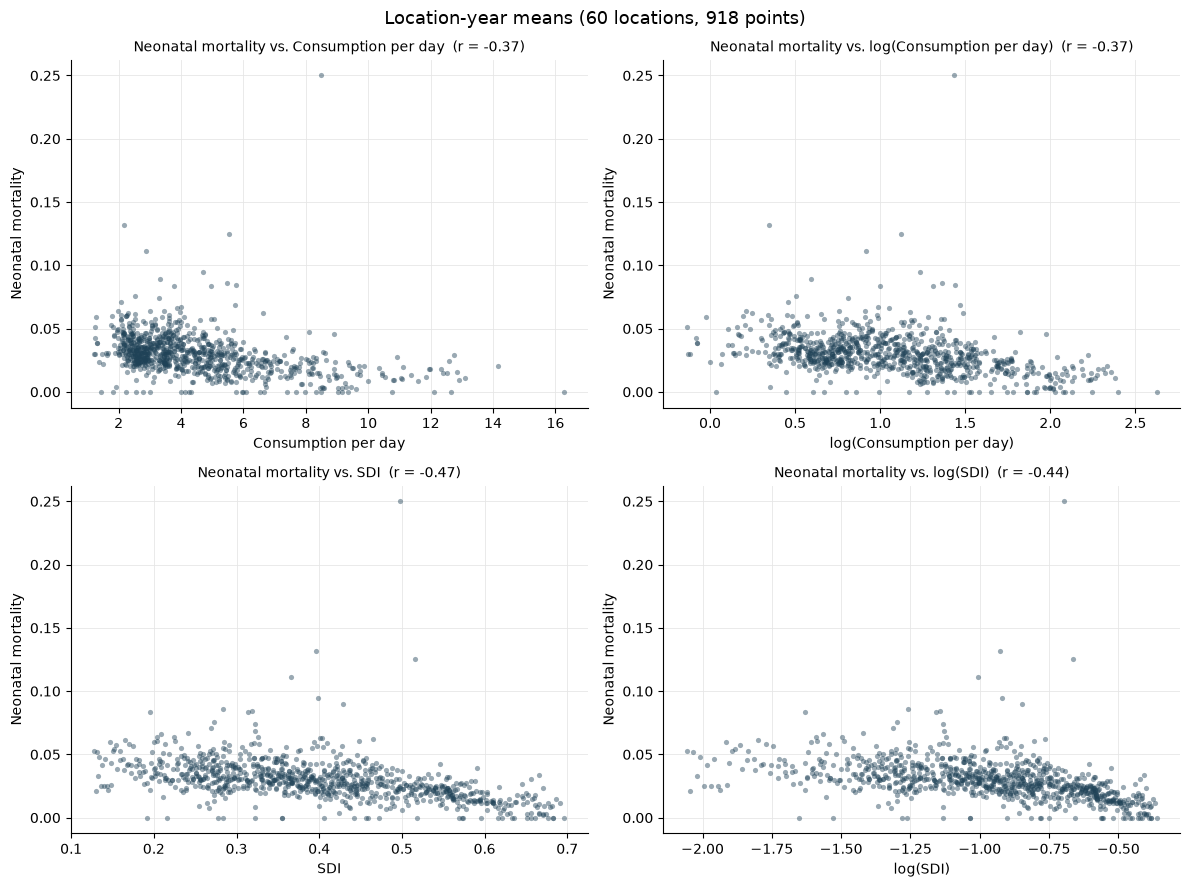

In [6]:
# Location-year means and mortality scatters ###################################
# Average the outcome and each covariate by location_name / birth_year, then
# scatter neonatal mortality against consumption_pd, log_consumption_pd, sdi and
# log_sdi. log_sdi is created here; log_consumption_pd already exists in the data.
MIN_OBS = 0  # set >0 (e.g. 25) to drop sparse location-years

df_raw["log_sdi"] = np.log(df_raw["sdi"])

AGG_VARS = [
    "neonatal_mortality",
    "consumption_pd",
    "log_consumption_pd",
    "sdi",
    "log_sdi",
]

df_agg = (
    df_raw.groupby(["location_name", "birth_year"])
    .agg(**{v: (v, "mean") for v in AGG_VARS}, n_births=("neonatal_mortality", "size"))
    .reset_index()
    .query("n_births >= @MIN_OBS")
)

scatter_specs = [
    ("consumption_pd", "Consumption per day"),
    ("log_consumption_pd", "log(Consumption per day)"),
    ("sdi", "SDI"),
    ("log_sdi", "log(SDI)"),
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
for ax, (x_col, x_label) in zip(axes.ravel(), scatter_specs):
    ax.scatter(
        df_agg[x_col],
        df_agg["neonatal_mortality"],
        s=14,
        alpha=0.45,
        color="#1f4257",
        linewidths=0,
    )
    r = df_agg[[x_col, "neonatal_mortality"]].corr().iloc[0, 1]
    ax.set_title(f"Neonatal mortality vs. {x_label}  (r = {r:.2f})", fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Neonatal mortality")
    ax.grid(True, color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.suptitle(
    f"Location-year means ({df_agg['location_name'].nunique()} locations, "
    f"{len(df_agg)} points)",
    fontsize=13,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}mortality_vs_covariates_scatter.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

Make scatters for 3 SSA countries only

Make more explanatory version of spline plot on Consumption

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/covariates_mortality_3countries.pdf


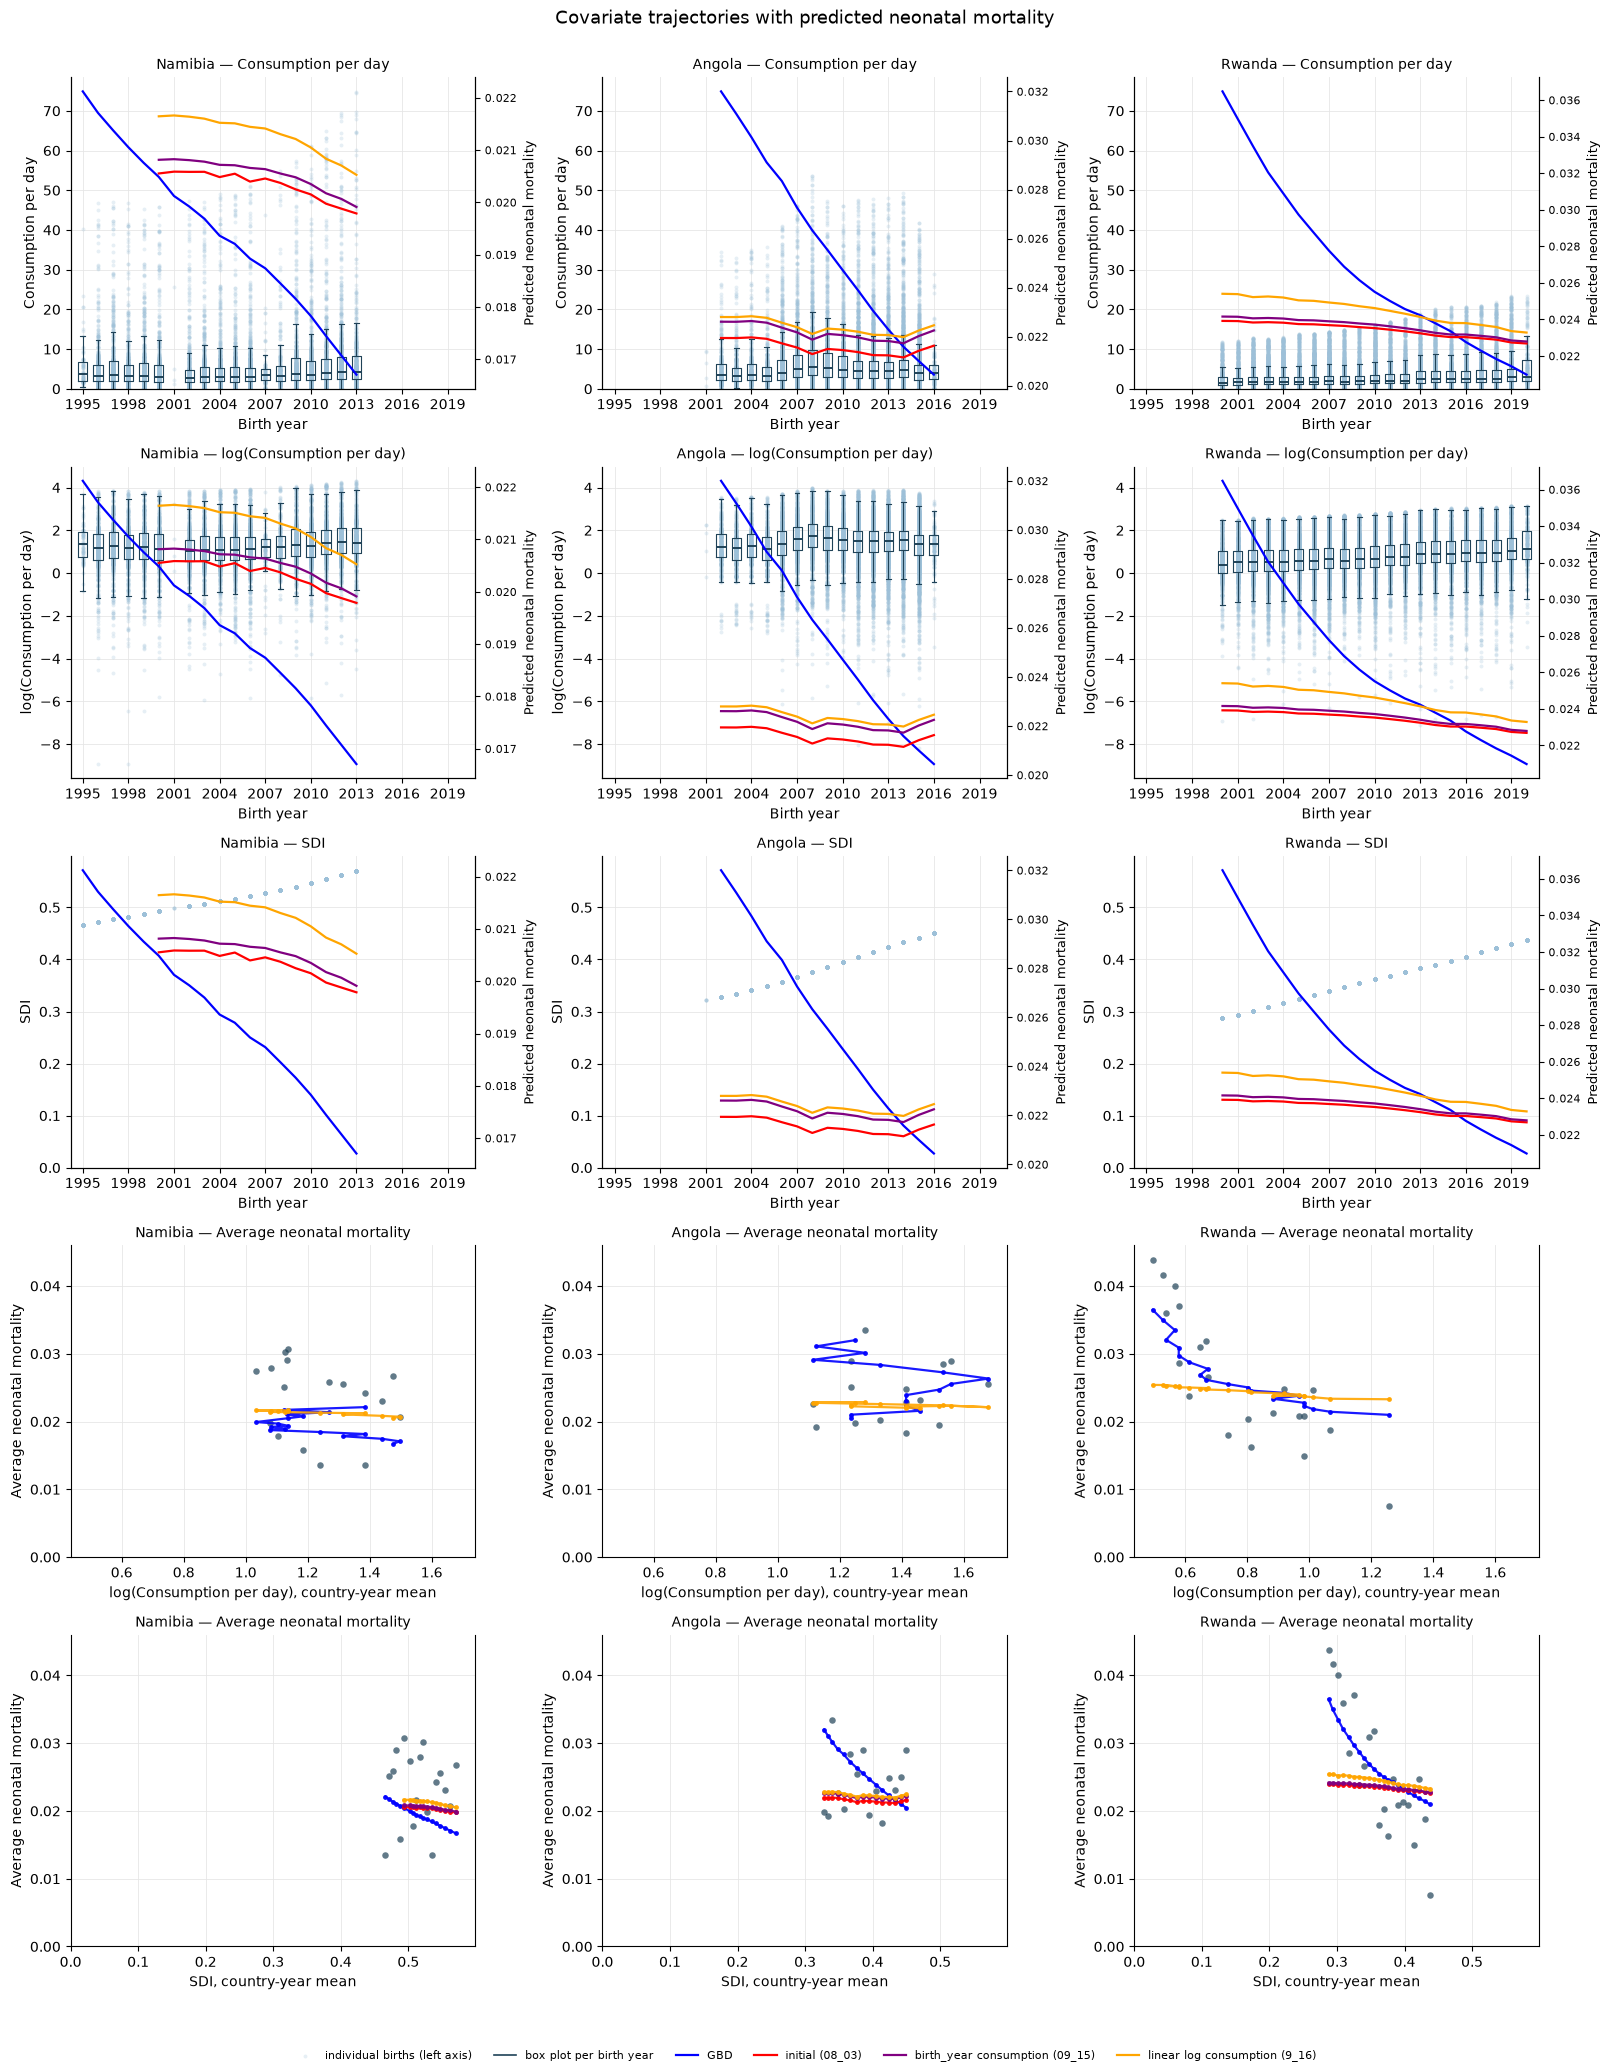

In [25]:
# Covariate trajectories with predicted mortality ##############################
# 3 rows x 3 columns, one column per country. Each row plots consumption_pd,
# log_consumption_pd or sdi against birth_year, with a box plot per birth year on
# the two consumption rows and a twin right axis carrying GBD and the two model
# runs (sex-averaged, clipped to the survey years). Axis limits are shared across
# the three countries and anchored at 0 where the variable is non-negative.
# A final row plots average neonatal mortality against mean log consumption per
# country-year, so it is drawn from country-year means rather than individual
# births and has no boxes, no time axis and no prediction overlay.
# ROW_VARS carries an x column per row; rows whose y column is in AGG_ROWS are
# plotted from df_cy (country-year means) instead of df_raw.
PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD"),
    "prevalence_initial": ("red", "initial (08_03)"),
    "prevalence_birth_year_consumption": ("purple", "birth_year consumption (09_15)"),
    "prevalence_linear_log_consumption": ("orange", "linear log consumption (9_16)"),
}
countries = ["Namibia", "Angola", "Rwanda"]
# (x column, y column, x label, y label)
ROW_VARS = [
    ("birth_year", "consumption_pd", "Birth year", "Consumption per day"),
    ("birth_year", "log_consumption_pd", "Birth year", "log(Consumption per day)"),
    ("birth_year", "sdi", "Birth year", "SDI"),
    (
        "log_consumption_pd",
        "neonatal_mortality",
        "log(Consumption per day), country-year mean",
        "Average neonatal mortality",
    ),
    (
        "sdi",
        "neonatal_mortality",
        "SDI, country-year mean",
        "Average neonatal mortality",
    ),
]
AGG_ROWS = {"neonatal_mortality"}  # rows drawn from country-year means
# Series overlaid on each AGG_ROWS row, keyed by that row's x column; the
# birth_year rows always show all of PRED_COLS.
AGG_PRED_COLS = {
    "log_consumption_pd": ["prevalence_gbd", "prevalence_linear_log_consumption"],
    "sdi": list(PRED_COLS),
}
BOX_ROWS = {"consumption_pd", "log_consumption_pd"}  # rows that also get box plots
ZERO_ANCHOR_ROWS = {
    "consumption_pd",
    "sdi",
    "neonatal_mortality",
}  # log_consumption_pd goes negative
MIN_OBS = 25  # birth-years with fewer births than this get no box
YMAX_QUANTILE = 1.0  # shared left-axis extent; lower it (e.g. 0.99) to tighten
POINT_COLOR = "#9dc0d8"
BOX_COLOR = "#1f4257"


def get_mean_draw(data):
    draw_cols = [c for c in data.columns if c.startswith("draw_")]
    out = data[[c for c in data.columns if "draw_" not in c]].copy()
    out["prevalence"] = data[draw_cols].mean(axis=1)
    return out


# Predictions ##################################################################
key = ["location_id", "year_id", "sex_id"]
gbd = (
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .rename(columns={"gbd_mean_prevalence": "prevalence_gbd"})
)
init = get_mean_draw(pd.read_parquet(INFERENCE_FILE_08_03).reset_index()).rename(
    columns={"prevalence": "prevalence_initial"}
)
lin = get_mean_draw(pd.read_parquet(INFERENCE_FILE_09_14).reset_index()).rename(
    columns={"prevalence": "prevalence_birth_year_consumption"}
)
loglin = get_mean_draw(pd.read_parquet(INFERENCE_FILE_09_16).reset_index()).rename(
    columns={"prevalence": "prevalence_linear_log_consumption"}
)

pred = (
    gbd[key + ["prevalence_gbd"]]
    .merge(init[key + ["prevalence_initial"]], on=key, how="left")
    .merge(lin[key + ["prevalence_birth_year_consumption"]], on=key, how="left")
    .merge(loglin[key + ["prevalence_linear_log_consumption"]], on=key, how="left")
    .merge(locs[["location_id", "location_name"]], on="location_id", how="left")
)
pred = (
    pred[pred["location_name"].isin(countries)]
    .groupby(["location_name", "year_id"], as_index=False)[list(PRED_COLS)]
    .mean()
)

# Country-year means, used by the AGG_ROWS rows ################################
selected = df_raw[df_raw["location_name"].isin(countries)]
df_cy = (
    selected.groupby(["location_name", "birth_year"], as_index=False)
    .agg(
        neonatal_mortality=("neonatal_mortality", "mean"),
        consumption_pd=("consumption_pd", "mean"),
        log_consumption_pd=("log_consumption_pd", "mean"),
        sdi=("sdi", "mean"),
        n_births=("neonatal_mortality", "size"),
    )
    .query("n_births >= @MIN_OBS")
)

# Predictions placed on a covariate x axis, for the AGG_ROWS rows ##############
pred_cy = pred.merge(
    df_cy.rename(columns={"birth_year": "year_id"}).drop(
        columns=["neonatal_mortality", "n_births"]
    ),
    on=["location_name", "year_id"],
    how="inner",
)

# Shared year limits for every birth_year row ##################################
year_counts = selected.groupby(["location_name", "birth_year"]).size()
kept = year_counts[year_counts >= MIN_OBS].index.get_level_values("birth_year")
year_lim = (kept.min() - 0.8, kept.max() + 0.8)


# Axis limits, shared across the three countries ###############################
def _limits(series, anchor_zero):
    hi = float(series.quantile(YMAX_QUANTILE))
    lo = 0.0 if anchor_zero else float(series.quantile(1 - YMAX_QUANTILE))
    pad = 0.05 * (hi - lo)
    return (lo if anchor_zero else lo - pad, hi + pad)


row_lims = []
for x_col, y_col, _, _ in ROW_VARS:
    source = df_cy if y_col in AGG_ROWS else selected
    y_values = source[y_col]
    if y_col in AGG_ROWS:
        # the prediction lines live on this same axis, so include their range
        y_values = pd.concat([y_values, pred_cy[AGG_PRED_COLS[x_col]].stack()])
    ylim = _limits(y_values, y_col in ZERO_ANCHOR_ROWS)
    xlim = (
        None
        if x_col == "birth_year"
        else _limits(source[x_col], x_col in ZERO_ANCHOR_ROWS)
    )
    row_lims.append((xlim, ylim))

# Plot #########################################################################
fig, axes = plt.subplots(
    nrows=len(ROW_VARS),
    ncols=len(countries),
    figsize=(5.4 * len(countries), 4.2 * len(ROW_VARS)),
)
axes = np.atleast_2d(axes)
handles, labels = [], []

for row, (x_col, y_col, x_label, y_label) in enumerate(ROW_VARS):
    for col, country in enumerate(countries):
        ax = axes[row, col]
        aggregated = y_col in AGG_ROWS
        source = df_cy if aggregated else df_raw
        sub = source[source["location_name"] == country]
        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=22 if aggregated else 8,
            alpha=0.7 if aggregated else 0.25,
            color=BOX_COLOR if aggregated else POINT_COLOR,
            linewidths=0,
            zorder=1,
            label="individual births (left axis)",
        )

        counts = sub.groupby("birth_year").size()
        kept_years = counts[counts >= MIN_OBS].index

        if x_col == "birth_year" and y_col in BOX_ROWS and len(kept_years):
            positions = list(kept_years)
            distributions = [
                sub.loc[sub["birth_year"] == yr, y_col].dropna().to_numpy()
                for yr in positions
            ]
            ax.boxplot(
                distributions,
                positions=positions,
                widths=0.6,
                manage_ticks=False,
                showfliers=False,
                zorder=2,
                boxprops={"color": BOX_COLOR, "linewidth": 0.8},
                whiskerprops={"color": BOX_COLOR, "linewidth": 0.8},
                capprops={"color": BOX_COLOR, "linewidth": 0.8},
                medianprops={"color": BOX_COLOR, "linewidth": 1.4},
            )

        if x_col == "birth_year":
            y0, y1 = kept_years.min(), kept_years.max()
            p = pred[
                (pred["location_name"] == country) & pred["year_id"].between(y0, y1)
            ].sort_values("year_id")

            ax2 = ax.twinx()
            for pred_col, (color, label) in PRED_COLS.items():
                ax2.plot(
                    p["year_id"],
                    p[pred_col],
                    color=color,
                    lw=1.6,
                    zorder=3,
                    label=label,
                )
            ax2.set_ylabel("Predicted neonatal mortality", fontsize=9)
            ax2.tick_params(labelsize=8)
            ax2.spines["top"].set_visible(False)
            ax.set_xlim(*year_lim)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            if not handles:
                h1, l1 = ax.get_legend_handles_labels()
                h2, l2 = ax2.get_legend_handles_labels()
                handles, labels = h1 + h2, l1 + l2
                if BOX_ROWS:
                    handles.insert(1, plt.Line2D([], [], color=BOX_COLOR, lw=1.2))
                    labels.insert(1, "box plot per birth year")
        else:
            ax.set_xlim(*row_lims[row][0])
            # y is already mortality here, so the predictions share the left axis
            pm = pred_cy[pred_cy["location_name"] == country].sort_values("year_id")
            for pred_col in AGG_PRED_COLS[x_col]:
                color, label = PRED_COLS[pred_col]
                ax.plot(
                    pm[x_col],
                    pm[pred_col],
                    color=color,
                    lw=1.6,
                    marker="o",
                    ms=2.5,
                    alpha=0.9,
                    zorder=3,
                    label=label,
                )

        ax.set_ylim(*row_lims[row][1])
        ax.set_title(f"{country} — {y_label}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, color="0.9", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)

fig.legend(
    handles, labels, loc="lower center", ncol=len(labels), fontsize=8, frameon=False
)
fig.suptitle(
    "Covariate trajectories with predicted neonatal mortality",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0.03, 1, 0.98))

plot_path = f"{PLOT_OUTPUT}covariates_mortality_3countries.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

In [ ]:
# Parametric (non-spline) coefficients for a completed run #####################
# base_model_coefs.parquet holds only the parametric terms; spline terms live in
# the separate *_spline_effects.parquet files and the country random intercept
# lives in base_model_ranef.parquet. The model version is read from the results
# spec rather than assumed, since results and model versions usually differ.
MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)


def print_model_coefficients(inference_file, label=""):
    results_dir = Path(inference_file).parent
    model_version = yaml.safe_load((results_dir / "results_spec.yaml").read_text())[
        "version"
    ]["model"]
    model_dir = MODEL_ROOT / model_version
    spec = yaml.safe_load((model_dir / "specification.yaml").read_text())
    coefs = pd.read_parquet(model_dir / "base_model_coefs.parquet")
    ranef = pd.read_parquet(model_dir / "base_model_ranef.parquet")

    spline_terms = [p["name"] for p in spec["predictors"] if p.get("spline")]
    print(f"{label or results_dir.name}  ->  model {model_version}")
    print(f"  predictors    : {[p['name'] for p in spec['predictors']]}")
    print(f"  spline terms  : {spline_terms or 'none'}  (not in the table below)")
    print(f"  random effect : {len(ranef)} {ranef.index.name} offsets")
    print(coefs.to_string())
    print()
    return coefs

In [ ]:
print_model_coefficients(INFERENCE_FILE_09_16, "linear log consumption (9_16)")

linear log consumption (9_16)  ->  model 2026_09_16.02
  predictors    : ['intercept', 'sex_id', 'birth_year', 'consumption_pd']
  spline terms  : none  (not in the table below)
  random effect : 60 ihme_loc_id offsets
                 Estimate  std_error  statistic        p_value
term                                                          
(Intercept)     34.690024   1.550822  22.368798  7.924268e-111
C(sex_id)2      -0.262168   0.009053 -28.959009  2.161289e-184
birth_year      -0.018961   0.000772 -24.558602  3.500320e-133
consumption_pd  -0.126393   0.005570 -22.691124  5.481930e-114



,Estimate,std_error,statistic,p_value
term,,,,
(Intercept),34.690024,1.550822,22.368798,7.924268e-111
C(sex_id)2,-0.262168,0.009053,-28.959009,2.161289e-184
birth_year,-0.018961,0.000772,-24.558602,3.500320e-133
consumption_pd,-0.126393,0.005570,-22.691124,5.481930e-114


In [ ]:
print_model_coefficients(INFERENCE_FILE_09_14, "consumption merged on birth_year")

consumption merged on birth_year  ->  model 2026_09_14.02
  predictors    : ['intercept', 'sex_id', 'birth_year', 'consumption_pd']
  spline terms  : ['consumption_pd']  (not in the table below)
  random effect : 60 ihme_loc_id offsets
              Estimate  std_error  statistic        p_value
term                                                       
(Intercept)  33.156943   1.558413  21.276097  1.890408e-100
C(sex_id)2   -0.262638   0.009054 -29.007687  5.263294e-185
birth_year   -0.018271   0.000775 -23.580155  6.160273e-123



,Estimate,std_error,statistic,p_value
term,,,,
(Intercept),33.156943,1.558413,21.276097,1.890408e-100
C(sex_id)2,-0.262638,0.009054,-29.007687,5.263294e-185
birth_year,-0.018271,0.000775,-23.580155,6.160273e-123


Make updates of spline plots, based off /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/models/2026_09_14.02/spline_effect_consumption_pd.png

2026_09_14.02: z0 = -3.7513 at birth_year=2020, reference sex, average country (ranef mean 0.000000)
  mortality at partial effect 0 = 2.295%
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_with_mortality.pdf


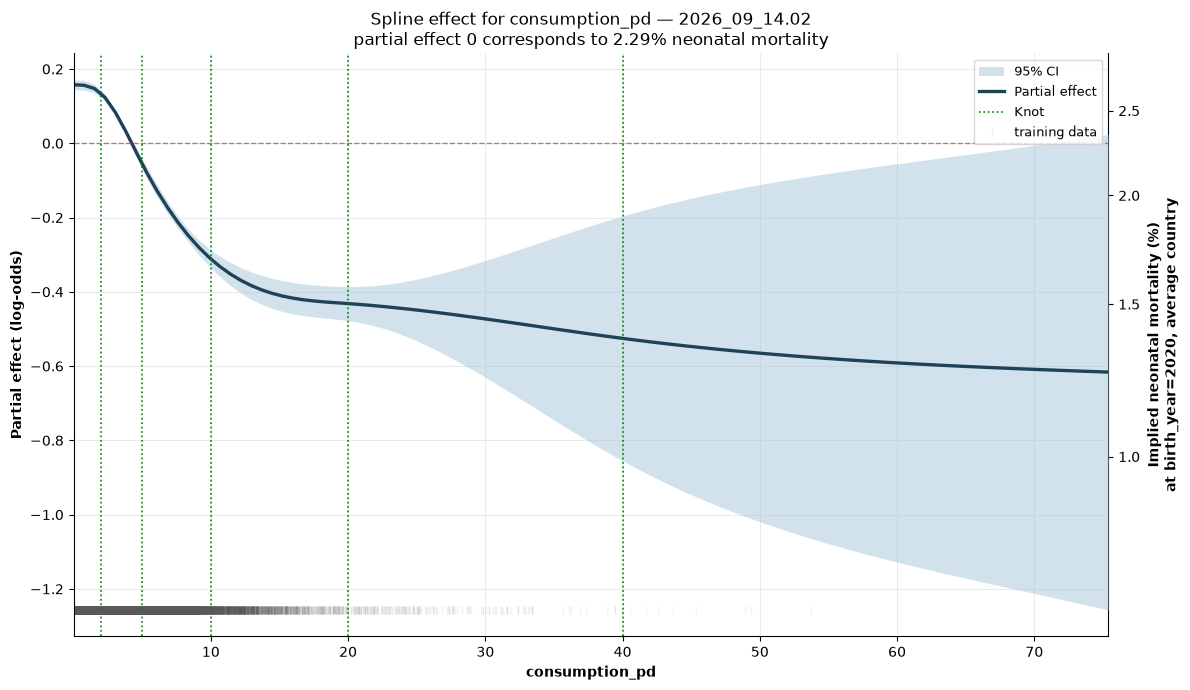

 consumption_pd  partial_effect  implied_nmr_pct  pct_change_vs_$1
            0.5           0.157            2.674             0.321
            1.0           0.153            2.665             0.000
            2.0           0.132            2.611            -2.025
            5.0          -0.055            2.174           -18.437
           10.0          -0.311            1.691           -36.541
           20.0          -0.432            1.502           -43.629
           40.0          -0.525            1.370           -48.600
           75.0          -0.616            1.253           -52.983


In [27]:
# Spline effect with the implied neonatal mortality on a second axis ###########
# Redraws models/<version>/spline_effect_<predictor>.png with a right-hand axis
# giving the neonatal mortality each log-odds value implies.
#
# The partial effect is an offset on the logit scale, so turning it into a
# mortality percentage needs a reference point for everything else in the model.
# We use the model's own linear predictor with the spline contribution set aside:
#   z0 = intercept + birth_year_coef * BASELINE_BIRTH_YEAR
# at the reference sex and an average country (the random intercepts are
# mean-zero, checked below). Implied mortality is then expit(z0 + effect), an
# exact monotone transform of the left axis, so the two axes stay in register.

MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
SPLINE_MODEL_VERSION = "2026_09_14.02"
SPLINE_PREDICTOR = "consumption_pd"
BASELINE_BIRTH_YEAR = 2020
RUG_SAMPLE = 20000

model_dir = MODEL_ROOT / SPLINE_MODEL_VERSION
spline = pd.read_parquet(model_dir / f"spline_effect_{SPLINE_PREDICTOR}.parquet")
coefs = pd.read_parquet(model_dir / "base_model_coefs.parquet")["Estimate"]
ranef = pd.read_parquet(model_dir / "base_model_ranef.parquet")
spec = yaml.safe_load((model_dir / "specification.yaml").read_text())
knots = [
    k
    for p in spec["predictors"]
    if p["name"] == SPLINE_PREDICTOR and p.get("spline")
    for k in p["spline"]["knots"]
]

z0 = float(coefs["(Intercept)"] + coefs["birth_year"] * BASELINE_BIRTH_YEAR)
baseline_nmr = 1 / (1 + np.exp(-z0))
print(
    f"{SPLINE_MODEL_VERSION}: z0 = {z0:.4f} at birth_year={BASELINE_BIRTH_YEAR}, "
    f"reference sex, average country (ranef mean {ranef.iloc[:, 0].mean():.6f})"
)
print(f"  mortality at partial effect 0 = {100 * baseline_nmr:.3f}%")


def logodds_to_pct(logodds):
    return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))


def pct_to_logodds(pct):
    p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p)) - z0


lo = spline["effect"] - 1.96 * spline["se"]
hi = spline["effect"] + 1.96 * spline["se"]

fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(
    spline["value"], lo, hi, color="#9dc0d8", alpha=0.45, linewidth=0, label="95% CI"
)
ax.plot(
    spline["value"], spline["effect"], color="#1f4257", lw=2.4, label="Partial effect"
)
ax.axhline(0, color="#d1495b", lw=1, ls="--", alpha=0.8)
for i, knot in enumerate(knots):
    ax.axvline(knot, color="green", ls=":", lw=1.2, label="Knot" if i == 0 else None)

rug = df_raw.loc[df_raw[SPLINE_PREDICTOR].notna(), SPLINE_PREDICTOR]
rug = rug.sample(min(RUG_SAMPLE, len(rug)), random_state=0)
ax.plot(
    rug,
    np.full(len(rug), lo.min()),
    "|",
    color="0.35",
    ms=6,
    alpha=0.08,
    label="training data",
)

ax.set_xlim(spline["value"].min(), spline["value"].max())
ax.set_xlabel(SPLINE_PREDICTOR, fontweight="bold")
ax.set_ylabel("Partial effect (log-odds)", fontweight="bold")
ax.grid(True, color="0.9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

pct_axis = ax.secondary_yaxis("right", functions=(logodds_to_pct, pct_to_logodds))
pct_axis.set_ylabel(
    f"Implied neonatal mortality (%)\n"
    f"at birth_year={BASELINE_BIRTH_YEAR}, average country",
    fontweight="bold",
)

ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"Spline effect for {SPLINE_PREDICTOR} — {SPLINE_MODEL_VERSION}\n"
    f"partial effect 0 corresponds to {100 * baseline_nmr:.2f}% neonatal mortality",
    fontsize=12,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}spline_effect_{SPLINE_PREDICTOR}_with_mortality.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Reference table over the fitted range
table = pd.DataFrame({"consumption_pd": [0.5, 1, 2, 5, 10, 20, 40, 75]})
table["partial_effect"] = np.interp(
    table["consumption_pd"], spline["value"], spline["effect"]
)
table["implied_nmr_pct"] = logodds_to_pct(table["partial_effect"])
table["pct_change_vs_$1"] = 100 * (
    table["implied_nmr_pct"]
    / logodds_to_pct(np.interp(1, spline["value"], spline["effect"]))
    - 1
)
print(table.round(3).to_string(index=False))

note: Namibia inference grid starts 2000, so its first endpoint is 2000 rather than 1995
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_by_country_four_views.pdf


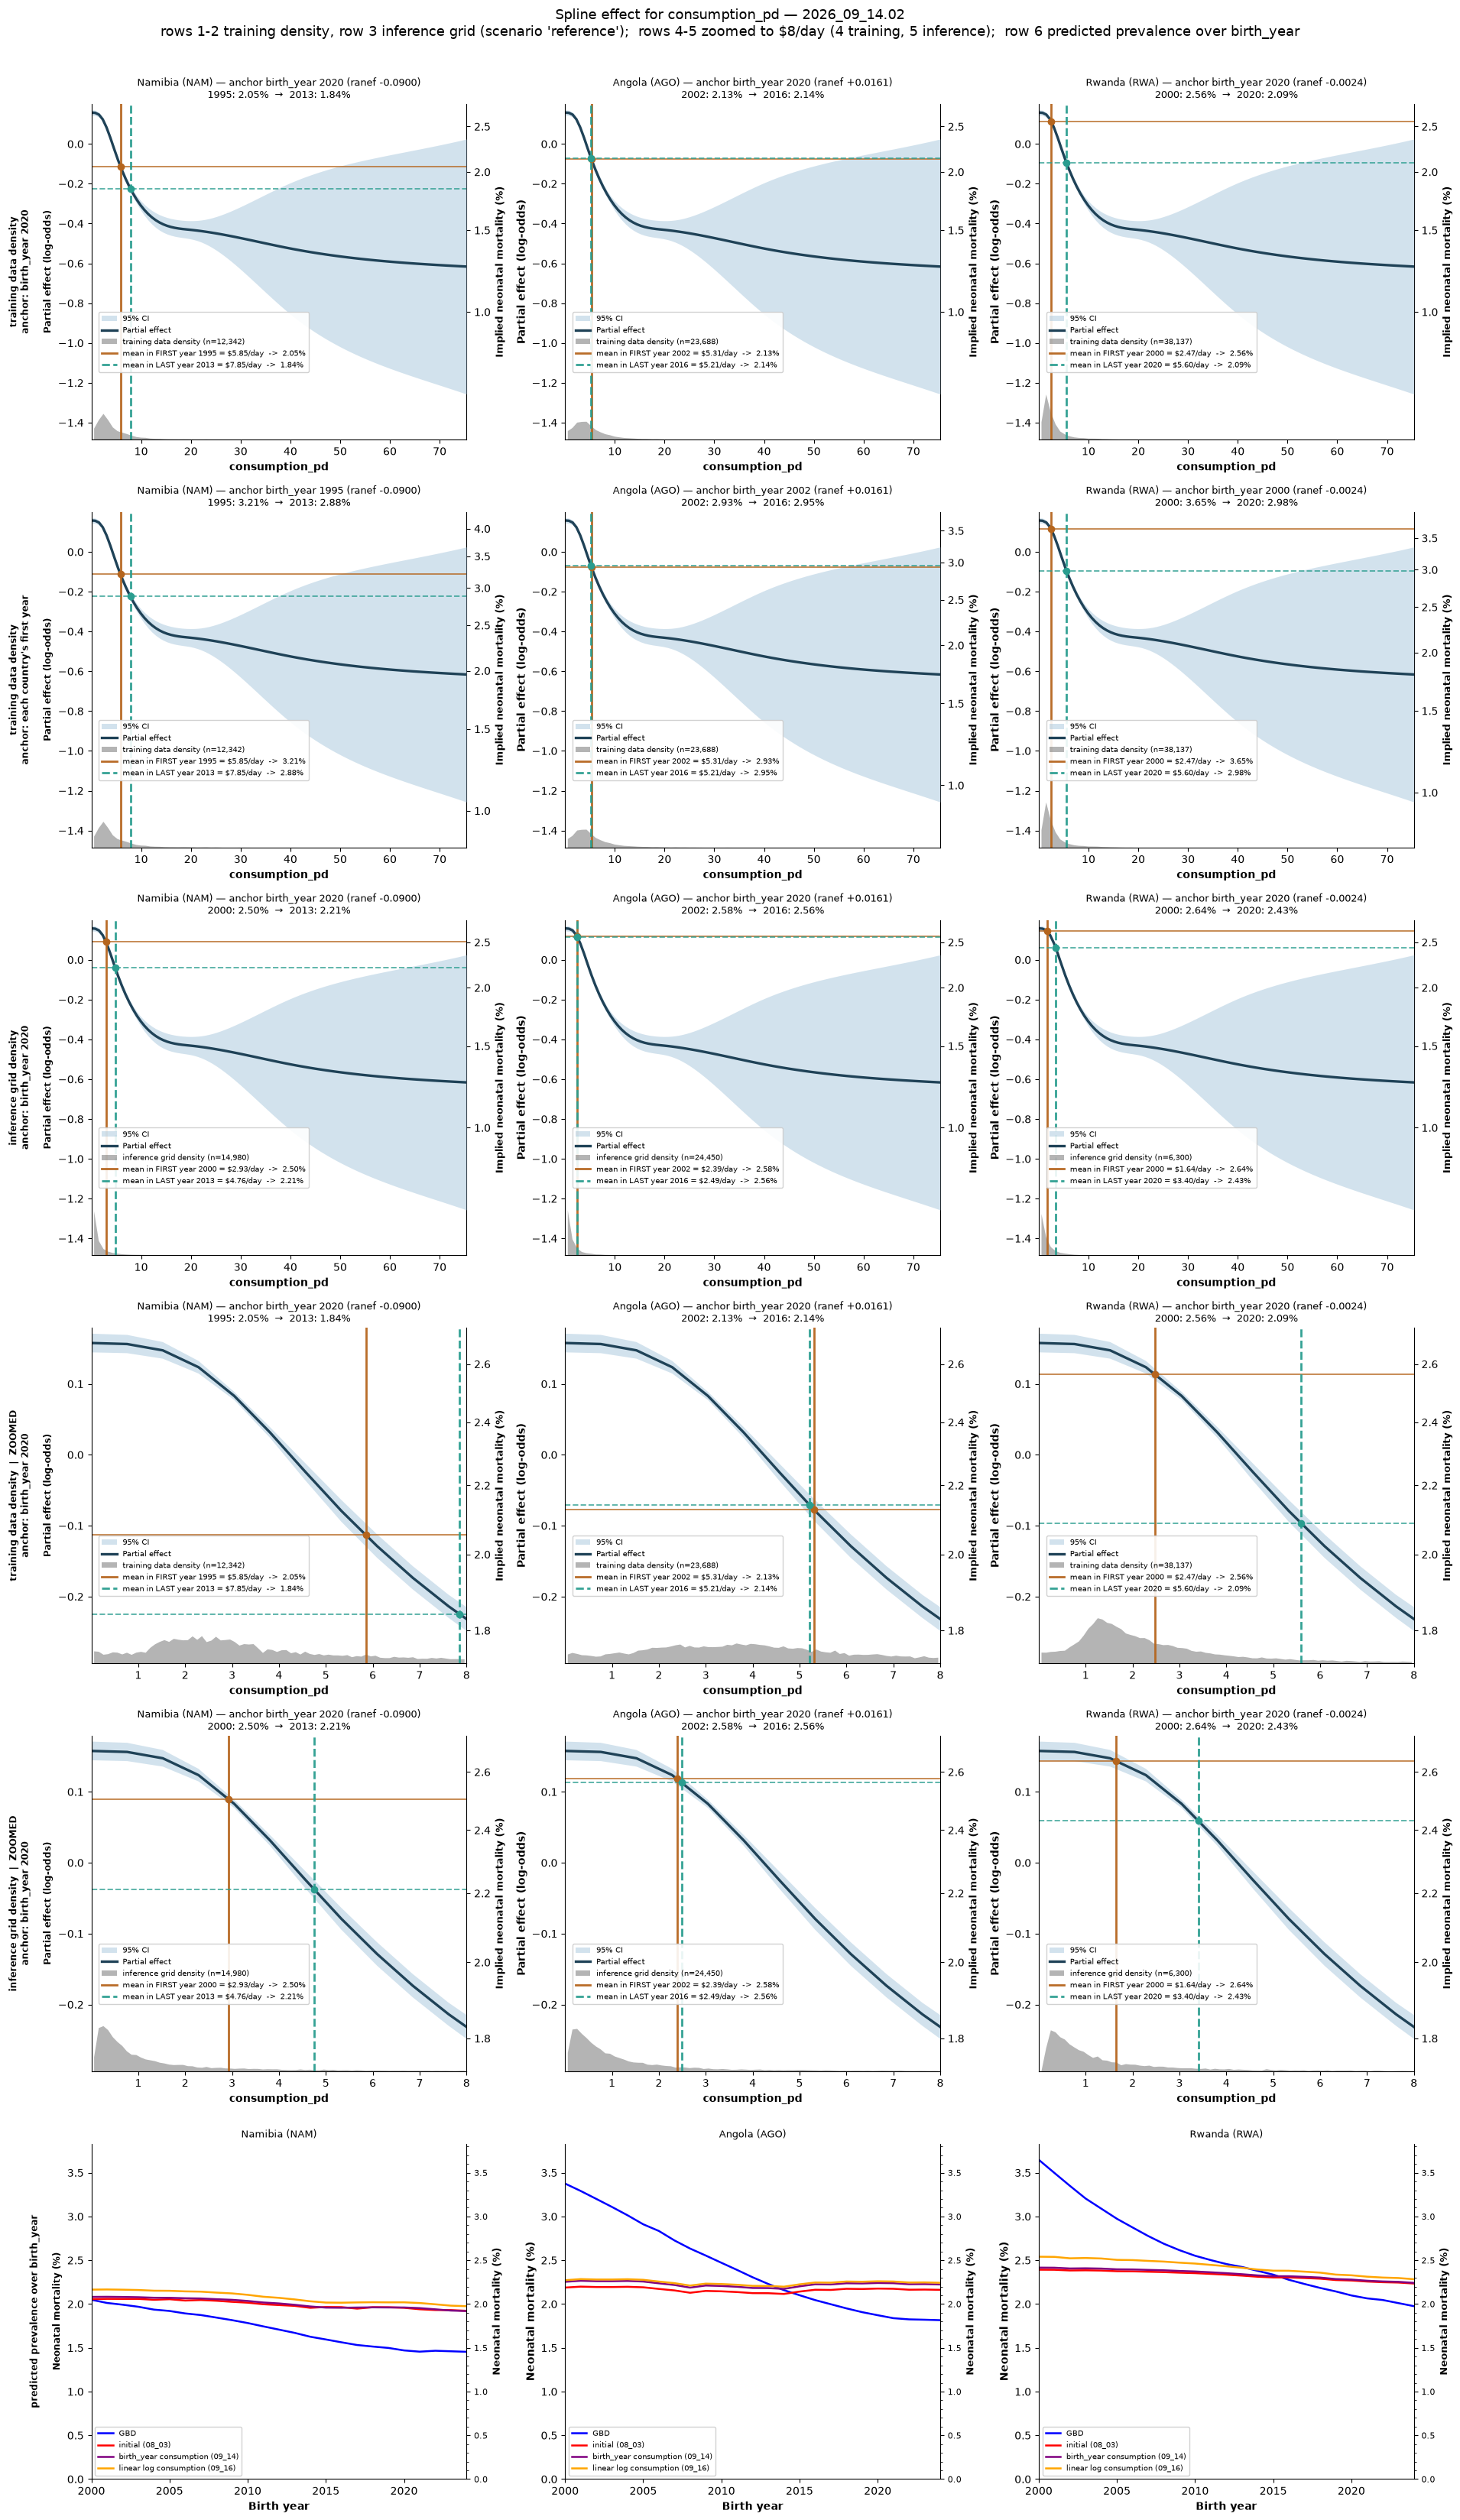

   source country  first_year  first_mean  last_year  last_mean  nmr_first_pct  nmr_last_pct  pct_change
 training Namibia        1995       5.851       2013      7.849          2.054         1.842     -10.359
 training  Angola        2002       5.307       2016      5.214          2.127         2.141       0.654
 training  Rwanda        2000       2.474       2020      5.597          2.563         2.088     -18.545
inference Namibia        2000       2.932       2013      4.758          2.503         2.211     -11.683
inference  Angola        2002       2.386       2016      2.487          2.575         2.562      -0.521
inference  Rwanda        2000       1.641       2020      3.403          2.640         2.431      -7.924


In [5]:
# Spline effect per country, four views ########################################
# The fitted curve is a global fixed effect, so it is identical in every panel.
# What varies by row is set in ROW_SPECS:
#   * anchor - the reference birth year for the right-hand mortality axis,
#         z0 = intercept + birth_year_coef * anchor_year + ranef[country]
#     "common" uses SPLINE_COMMON_YEAR for every country, "first" uses each
#     country's own first year of data, which shows how much of the mortality
#     level the birth_year term alone is carrying.
#   * zoom - restrict x to ZOOM_XMAX so the intersections are legible where the
#     data actually sits, instead of spanning the whole fitted range.
#   * source - which distribution the density band and the mean lines come from:
#     "training" is individual births in the training data, "inference" is the
#     admin2 x income-decile grid the model is applied to at inference.
# Two vertical lines mark the mean consumption in that country's first and last
# year of data, each paired with a horizontal line at the partial effect the
# curve takes there and a dot on the intersection.
from pathlib import Path

import yaml
from matplotlib.ticker import AutoMinorLocator

SPLINE_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
SPLINE_MODEL = "2026_09_14.02"
SPLINE_VAR = "consumption_pd"
SPLINE_COMMON_YEAR = 2020
SPLINE_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
SPLINE_MIN_OBS = 25  # a year needs this many births to count as first/last
SPLINE_SCENARIO = "reference"  # income scenario in the inference grid
ZOOM_XMAX = 8.0
# The right-hand axis is z0 = intercept + birth_year_coef * anchor_year, plus the
# country random intercept only if INCLUDE_RANEF. Leaving it out makes z0 - and
# so the mortality axis - identical across the three columns wherever the anchor
# year is shared, at the cost of reading "average country" rather than that
# country. The offsets are small (|ranef| <= 0.09) and still shown in the title.
INCLUDE_RANEF = False
DENSITY_BINS = 80
DENSITY_FRAC = 0.16  # share of the panel height given to the density band

FIRST_COLOR, LAST_COLOR = "#b5651d", "#2a9d8f"
ROW_SPECS = [
    ("common", False, "training"),
    ("first", False, "training"),
    ("common", False, "inference"),
    ("common", True, "training"),
    ("common", True, "inference"),
    ("common", False, "timeseries"),
]
SOURCE_LABEL = {
    "training": "training data",
    "inference": "inference grid",
    "timeseries": "predicted prevalence over birth_year",
}
# Series for the timeseries row, sex-averaged. Note the 09_14 label: cell 8 calls
# this one "(09_15)", but INFERENCE_FILE_09_14 is what it reads.
TS_SERIES = {
    "prevalence_gbd": (GBD_FILE, "blue", "GBD"),
    "prevalence_initial": (INFERENCE_FILE_08_03, "red", "initial (08_03)"),
    "prevalence_birth_year_consumption": (
        INFERENCE_FILE_09_14,
        "purple",
        "birth_year consumption (09_14)",
    ),
    "prevalence_linear_log_consumption": (
        INFERENCE_FILE_09_16,
        "orange",
        "linear log consumption (09_16)",
    ),
}

_dir = SPLINE_MODEL_ROOT / SPLINE_MODEL
_spline = pd.read_parquet(_dir / f"spline_effect_{SPLINE_VAR}.parquet")
_coefs = pd.read_parquet(_dir / "base_model_coefs.parquet")["Estimate"]
_ranef = pd.read_parquet(_dir / "base_model_ranef.parquet")
_spec = yaml.safe_load((_dir / "specification.yaml").read_text())
_iso = locs.set_index("location_name")["ihme_loc_id"]


def _effect_at(value):
    return float(np.interp(value, _spline["value"], _spline["effect"]))


# Training data: first/last year with enough births, and the mean in each #######
_by_year = (
    df_raw[df_raw["location_name"].isin(SPLINE_COUNTRIES)]
    .groupby(["location_name", "birth_year"])
    .agg(n=(SPLINE_VAR, "size"), mean=(SPLINE_VAR, "mean"))
    .query("n >= @SPLINE_MIN_OBS")
)
_years = {}
for country in SPLINE_COUNTRIES:
    yrs = _by_year.loc[country].index
    _years[country] = (int(yrs.min()), int(yrs.max()))

# Inference grid: the same covariate the model is applied to ###################
_grid = pd.read_parquet(
    _dir / f"base_model_{SPLINE_VAR}_spline_effects.parquet",
    columns=[
        "year_id",
        "national_ihme_loc_id",
        "population_percentile",
        "scenario",
        "value",
    ],
    filters=[
        ("scenario", "==", SPLINE_SCENARIO),
        ("national_ihme_loc_id", "in", [_iso.loc[c] for c in SPLINE_COUNTRIES]),
    ],
)
_grid = _grid[_grid["population_percentile"] > 0]
_grid_min_year = int(_grid["year_id"].min())

# Per-country distributions and endpoint means, for each source ################
_dists, _endpoints = {}, {}
for country in SPLINE_COUNTRIES:
    iso = _iso.loc[country]
    first, last = _years[country]

    train = df_raw.loc[df_raw["location_name"] == country, SPLINE_VAR].dropna()
    _dists[("training", country)] = train
    _endpoints[("training", country)] = {
        "first_year": first,
        "last_year": last,
        "first_mean": float(_by_year.loc[(country, first), "mean"]),
        "last_mean": float(_by_year.loc[(country, last), "mean"]),
    }

    g = _grid[_grid["national_ihme_loc_id"] == iso]
    # the grid starts later than some surveys, so clamp the early endpoint
    g_first, g_last = max(first, _grid_min_year), last
    _dists[("inference", country)] = g.loc[
        g["year_id"].between(g_first, g_last), "value"
    ]
    _endpoints[("inference", country)] = {
        "first_year": g_first,
        "last_year": g_last,
        "first_mean": float(g.loc[g["year_id"] == g_first, "value"].mean()),
        "last_mean": float(g.loc[g["year_id"] == g_last, "value"].mean()),
    }
    if g_first != first:
        print(
            f"note: {country} inference grid starts {_grid_min_year}, "
            f"so its first endpoint is {g_first} rather than {first}"
        )


# Predicted prevalence by country and year, sex-averaged, for the last row #####
def _mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


_ts = None
for col, (path, _colour, _label) in TS_SERIES.items():
    frame = pd.read_parquet(path).reset_index()
    if col != "prevalence_gbd":
        frame = _mean_draw(frame)
        frame = frame.rename(columns={"prevalence": col})
    else:
        frame = frame.rename(columns={"gbd_mean_prevalence": col})
    frame = frame[["location_id", "year_id", "sex_id", col]]
    _ts = (
        frame
        if _ts is None
        else _ts.merge(frame, on=["location_id", "year_id", "sex_id"], how="inner")
    )
_ts = (
    _ts.merge(locs[["location_id", "location_name"]], on="location_id", how="left")
    .query("location_name in @SPLINE_COUNTRIES")
    .groupby(["location_name", "year_id"], as_index=False)[list(TS_SERIES)]
    .mean()
)
_ts_xlim = (_ts["year_id"].min(), _ts["year_id"].max())
_ts_ylim = (
    0.0,
    100 * _ts[list(TS_SERIES)].to_numpy().max() * 1.05,
)

# Density bands, normalised within each (source, zoom) so rows stay comparable #
_edges = {
    False: np.linspace(
        _spline["value"].min(), _spline["value"].max(), DENSITY_BINS + 1
    ),
    True: np.linspace(_spline["value"].min(), ZOOM_XMAX, DENSITY_BINS + 1),
}
_bands, _band_max = {}, {}
for source in ("training", "inference"):
    for zoom in (False, True):
        for country in SPLINE_COUNTRIES:
            _bands[(source, zoom, country)] = np.histogram(
                _dists[(source, country)], bins=_edges[zoom], density=True
            )[0]
        _band_max[(source, zoom)] = max(
            _bands[(source, zoom, c)].max() for c in SPLINE_COUNTRIES
        )

# Panel limits, per zoom setting ###############################################
_lo_all = _spline["effect"] - 1.96 * _spline["se"]
_hi_all = _spline["effect"] + 1.96 * _spline["se"]
_limits = {}
for zoom in (False, True):
    keep = _spline["value"] <= (ZOOM_XMAX if zoom else _spline["value"].max())
    lo, hi = _lo_all[keep].min(), _hi_all[keep].max()
    span = hi - lo
    _limits[zoom] = (lo - DENSITY_FRAC * span, hi + 0.02 * span, span)

fig, axes = plt.subplots(
    nrows=len(ROW_SPECS),
    ncols=len(SPLINE_COUNTRIES),
    figsize=(6.4 * len(SPLINE_COUNTRIES), 5.6 * len(ROW_SPECS)),
)
axes = np.atleast_2d(axes)

for row, (anchor_kind, zoom, source) in enumerate(ROW_SPECS):
    y_bottom, y_top, span = _limits[zoom]
    x_max = ZOOM_XMAX if zoom else _spline["value"].max()
    centres = 0.5 * (_edges[zoom][:-1] + _edges[zoom][1:])

    if source == "timeseries":
        for col, country in enumerate(SPLINE_COUNTRIES):
            ax = axes[row, col]
            sub = _ts[_ts["location_name"] == country].sort_values("year_id")
            for ts_col, (_path, colour, label) in TS_SERIES.items():
                ax.plot(
                    sub["year_id"], 100 * sub[ts_col], color=colour, lw=1.8, label=label
                )
            ax.set_xlim(*_ts_xlim)
            ax.set_ylim(*_ts_ylim)
            ax.set_xlabel("Birth year", fontweight="bold")
            ax.set_ylabel(
                (
                    "predicted prevalence over birth_year\n\n" "Neonatal mortality (%)"
                    if col == 0
                    else "Neonatal mortality (%)"
                ),
                fontweight="bold",
                fontsize=8.5 if col == 0 else 10,
            )
            ax.set_axisbelow(True)
            for side in ("top", "right"):
                ax.spines[side].set_visible(False)

            # Mirror the scale on the right so the terminal values of the flat
            # lines can be read off next to where they actually end, and add
            # minor ticks because the series finish within ~0.1pp of each other.
            mirror = ax.secondary_yaxis("right", functions=(lambda v: v, lambda v: v))
            mirror.set_ylabel("Neonatal mortality (%)", fontweight="bold", fontsize=9)
            mirror.yaxis.set_minor_locator(AutoMinorLocator(5))
            mirror.tick_params(which="both", labelsize=8)

            ax.set_title(f"{country} ({_iso.loc[country]})", fontsize=9.5)
            ax.legend(loc="lower left", fontsize=7, framealpha=0.9)
        continue

    for col, country in enumerate(SPLINE_COUNTRIES):
        ax = axes[row, col]
        iso = _iso.loc[country]
        ends = _endpoints[(source, country)]
        anchor_year = (
            SPLINE_COMMON_YEAR if anchor_kind == "common" else _years[country][0]
        )
        z0 = float(
            _coefs["(Intercept)"]
            + _coefs["birth_year"] * anchor_year
            + (_ranef.loc[iso, "offset"] if INCLUDE_RANEF else 0.0)
        )

        def to_pct(logodds, z0=z0):
            return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))

        def to_logodds(pct, z0=z0):
            p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
            return np.log(p / (1 - p)) - z0

        ax.fill_between(
            _spline["value"],
            _lo_all,
            _hi_all,
            color="#9dc0d8",
            alpha=0.45,
            linewidth=0,
            label="95% CI",
        )
        ax.plot(
            _spline["value"],
            _spline["effect"],
            color="#1f4257",
            lw=2.4,
            label="Partial effect",
        )
        band = (
            _bands[(source, zoom, country)]
            / _band_max[(source, zoom)]
            * DENSITY_FRAC
            * span
        )
        ax.fill_between(
            centres,
            y_bottom,
            y_bottom + band,
            color="0.35",
            alpha=0.45,
            linewidth=0,
            label=(
                f"{SOURCE_LABEL[source]} density "
                f"(n={len(_dists[(source, country)]):,})"
            ),
        )

        for stem, mean_key, year_key, colour, style in (
            ("FIRST", "first_mean", "first_year", FIRST_COLOR, "-"),
            ("LAST", "last_mean", "last_year", LAST_COLOR, "--"),
        ):
            mean = ends[mean_key]
            effect = _effect_at(mean)
            ax.axvline(
                mean,
                color=colour,
                lw=2.0,
                ls=style,
                alpha=0.95,
                label=(
                    f"mean in {stem} year {ends[year_key]} = "
                    f"${mean:.2f}/day  ->  {to_pct(effect):.2f}%"
                ),
            )
            ax.axhline(effect, color=colour, lw=1.4, ls=style, alpha=0.75)
            ax.plot([mean], [effect], "o", color=colour, ms=6, zorder=5)

        ax.set_xlim(_spline["value"].min(), x_max)
        ax.set_ylim(y_bottom, y_top)
        ax.set_xlabel(SPLINE_VAR, fontweight="bold")
        row_label = (
            f"{SOURCE_LABEL[source]} density"
            + ("  |  ZOOMED" if zoom else "")
            + "\nanchor: "
            + (
                f"birth_year {SPLINE_COMMON_YEAR}"
                if anchor_kind == "common"
                else "each country's first year"
            )
        )
        ax.set_ylabel(
            (
                f"{row_label}\n\nPartial effect (log-odds)"
                if col == 0
                else "Partial effect (log-odds)"
            ),
            fontweight="bold",
            fontsize=8.5 if col == 0 else 10,
        )
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        pct_axis = ax.secondary_yaxis("right", functions=(to_pct, to_logodds))
        pct_axis.set_ylabel(
            "Implied neonatal mortality (%)", fontweight="bold", fontsize=9
        )

        ax.set_title(
            f"{country} ({iso}) — anchor birth_year {anchor_year}"
            f" (ranef {_ranef.loc[iso, 'offset']:+.4f})\n"
            f"{ends['first_year']}: {to_pct(_effect_at(ends['first_mean'])):.2f}%"
            f"  →  {ends['last_year']}: "
            f"{to_pct(_effect_at(ends['last_mean'])):.2f}%",
            fontsize=9.5,
        )
        ax.legend(
            loc="lower left",
            bbox_to_anchor=(0.01, DENSITY_FRAC + 0.03),
            fontsize=7,
            framealpha=0.9,
        )

fig.suptitle(
    f"Spline effect for {SPLINE_VAR} — {SPLINE_MODEL}\n"
    f"rows 1-2 training density, row 3 inference grid (scenario "
    f"'{SPLINE_SCENARIO}');  rows 4-5 zoomed to ${ZOOM_XMAX:.0f}/day "
    f"(4 training, 5 inference);  row 6 predicted prevalence over birth_year",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.975))

plot_path = f"{PLOT_OUTPUT}spline_effect_{SPLINE_VAR}_by_country_four_views.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Endpoint means and the mortality they imply, by source #######################
rows = []
for source in ("training", "inference"):
    for country in SPLINE_COUNTRIES:
        iso = _iso.loc[country]
        ends = _endpoints[(source, country)]
        z0 = float(
            _coefs["(Intercept)"]
            + _coefs["birth_year"] * SPLINE_COMMON_YEAR
            + (_ranef.loc[iso, "offset"] if INCLUDE_RANEF else 0.0)
        )
        pct = lambda e, z0=z0: 100 / (1 + np.exp(-(z0 + e)))
        first_pct = pct(_effect_at(ends["first_mean"]))
        last_pct = pct(_effect_at(ends["last_mean"]))
        rows.append(
            {
                "source": source,
                "country": country,
                "first_year": ends["first_year"],
                "first_mean": ends["first_mean"],
                "last_year": ends["last_year"],
                "last_mean": ends["last_mean"],
                "nmr_first_pct": first_pct,
                "nmr_last_pct": last_pct,
                "pct_change": 100 * (last_pct / first_pct - 1),
            }
        )
print(pd.DataFrame(rows).round(3).to_string(index=False))

Presentation cut: Rwanda only, rows 1, 4, 5 and 6

Rwanda (RWA), rows [1, 4, 5, 6] of 6: 1=training data; 4=training data zoomed; 5=inference grid zoomed; 6=predicted prevalence over birth_year
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_rwanda_presentation.pdf


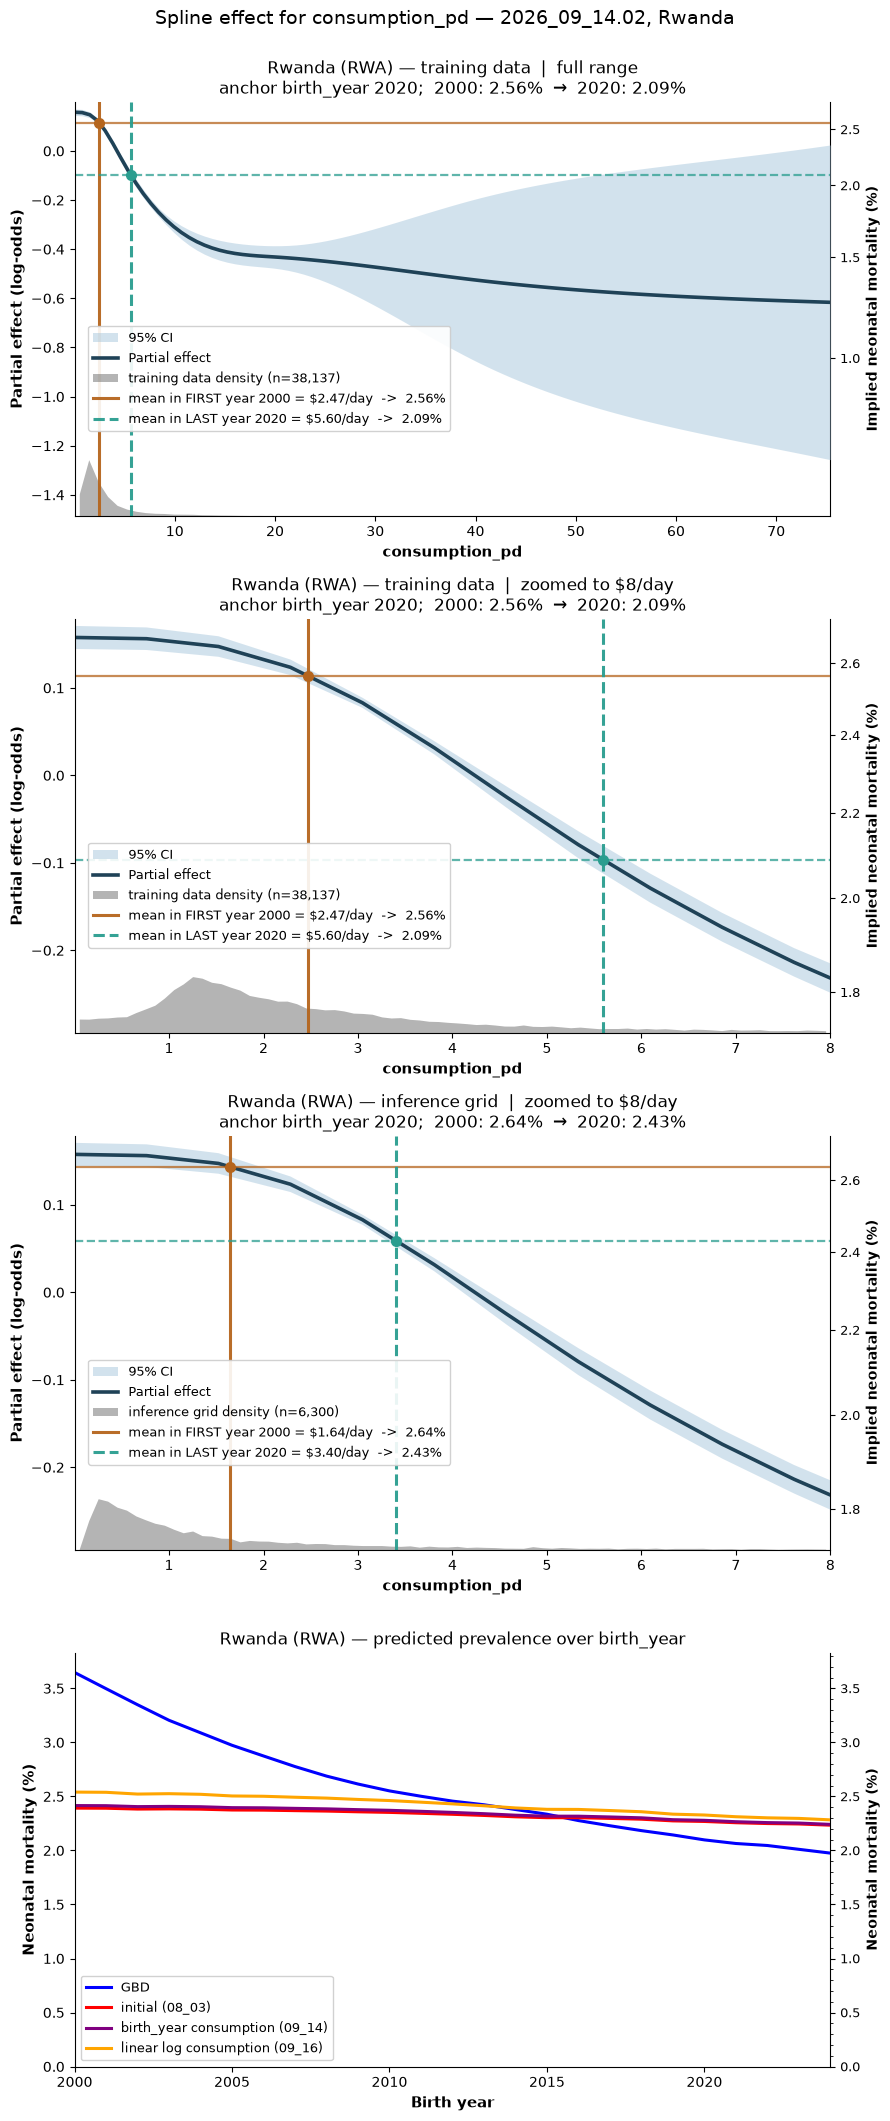

In [6]:
# Presentation cut of the spline figure: Rwanda only, four of the six rows ####
# Same panels as the cell above, subset for slides:
#   row 1 -> full x range, training density
#   row 4 -> zoomed to ZOOM_XMAX, training density
#   row 5 -> zoomed to ZOOM_XMAX, inference grid density
#   row 6 -> predicted prevalence over birth_year
#
# Nothing is recomputed. The spline, the densities, the endpoint means and the
# prevalence series are all read from the objects the previous cell built, so
# these panels are exactly its Rwanda column - including the density
# normalisation, which stays scaled against all three countries so the bands
# are the same height they are there.
PRES_COUNTRY = "Rwanda"
PRES_ROWS = [1, 4, 5, 6]  # 1-indexed into ROW_SPECS above
PRES_TITLE_SIZE = 12
PRES_LABEL_SIZE = 11
PRES_TICK_SIZE = 10

_pres_specs = [(r, ROW_SPECS[r - 1]) for r in PRES_ROWS]
_pres_iso = _iso.loc[PRES_COUNTRY]
print(
    f"{PRES_COUNTRY} ({_pres_iso}), rows {PRES_ROWS} of "
    f"{len(ROW_SPECS)}: "
    + "; ".join(
        f"{r}={SOURCE_LABEL[s[2]]}{' zoomed' if s[1] else ''}" for r, s in _pres_specs
    )
)

fig, axes = plt.subplots(
    nrows=len(_pres_specs), ncols=1, figsize=(9.0, 5.4 * len(_pres_specs))
)
axes = np.atleast_1d(axes)

for ax, (row_no, (anchor_kind, zoom, source)) in zip(axes, _pres_specs):
    ax.tick_params(labelsize=PRES_TICK_SIZE)

    if source == "timeseries":
        sub = _ts[_ts["location_name"] == PRES_COUNTRY].sort_values("year_id")
        for ts_col, (_path, colour, label) in TS_SERIES.items():
            ax.plot(
                sub["year_id"], 100 * sub[ts_col], color=colour, lw=2.2, label=label
            )
        ax.set_xlim(*_ts_xlim)
        ax.set_ylim(*_ts_ylim)
        ax.set_xlabel("Birth year", fontweight="bold", fontsize=PRES_LABEL_SIZE)
        ax.set_ylabel(
            "Neonatal mortality (%)", fontweight="bold", fontsize=PRES_LABEL_SIZE
        )
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        mirror = ax.secondary_yaxis("right", functions=(lambda v: v, lambda v: v))
        mirror.set_ylabel(
            "Neonatal mortality (%)", fontweight="bold", fontsize=PRES_LABEL_SIZE - 1
        )
        mirror.yaxis.set_minor_locator(AutoMinorLocator(5))
        mirror.tick_params(which="both", labelsize=PRES_TICK_SIZE - 1)
        ax.set_title(
            f"{PRES_COUNTRY} ({_pres_iso}) — predicted prevalence over birth_year",
            fontsize=PRES_TITLE_SIZE,
        )
        ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
        continue

    y_bottom, y_top, span = _limits[zoom]
    x_max = ZOOM_XMAX if zoom else _spline["value"].max()
    centres = 0.5 * (_edges[zoom][:-1] + _edges[zoom][1:])
    ends = _endpoints[(source, PRES_COUNTRY)]
    anchor_year = (
        SPLINE_COMMON_YEAR if anchor_kind == "common" else _years[PRES_COUNTRY][0]
    )
    z0 = float(
        _coefs["(Intercept)"]
        + _coefs["birth_year"] * anchor_year
        + (_ranef.loc[_pres_iso, "offset"] if INCLUDE_RANEF else 0.0)
    )

    def to_pct(logodds, z0=z0):
        return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))

    def to_logodds(pct, z0=z0):
        p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
        return np.log(p / (1 - p)) - z0

    ax.fill_between(
        _spline["value"],
        _lo_all,
        _hi_all,
        color="#9dc0d8",
        alpha=0.45,
        linewidth=0,
        label="95% CI",
    )
    ax.plot(
        _spline["value"],
        _spline["effect"],
        color="#1f4257",
        lw=2.6,
        label="Partial effect",
    )
    band = (
        _bands[(source, zoom, PRES_COUNTRY)]
        / _band_max[(source, zoom)]
        * DENSITY_FRAC
        * span
    )
    ax.fill_between(
        centres,
        y_bottom,
        y_bottom + band,
        color="0.35",
        alpha=0.45,
        linewidth=0,
        label=(
            f"{SOURCE_LABEL[source]} density "
            f"(n={len(_dists[(source, PRES_COUNTRY)]):,})"
        ),
    )

    for stem, mean_key, year_key, colour, style in (
        ("FIRST", "first_mean", "first_year", FIRST_COLOR, "-"),
        ("LAST", "last_mean", "last_year", LAST_COLOR, "--"),
    ):
        mean = ends[mean_key]
        effect = _effect_at(mean)
        ax.axvline(
            mean,
            color=colour,
            lw=2.2,
            ls=style,
            alpha=0.95,
            label=(
                f"mean in {stem} year {ends[year_key]} = "
                f"${mean:.2f}/day  ->  {to_pct(effect):.2f}%"
            ),
        )
        ax.axhline(effect, color=colour, lw=1.6, ls=style, alpha=0.75)
        ax.plot([mean], [effect], "o", color=colour, ms=7, zorder=5)

    ax.set_xlim(_spline["value"].min(), x_max)
    ax.set_ylim(y_bottom, y_top)
    ax.set_xlabel(SPLINE_VAR, fontweight="bold", fontsize=PRES_LABEL_SIZE)
    ax.set_ylabel(
        "Partial effect (log-odds)", fontweight="bold", fontsize=PRES_LABEL_SIZE
    )
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    pct_axis = ax.secondary_yaxis("right", functions=(to_pct, to_logodds))
    pct_axis.set_ylabel(
        "Implied neonatal mortality (%)",
        fontweight="bold",
        fontsize=PRES_LABEL_SIZE - 1,
    )
    pct_axis.tick_params(labelsize=PRES_TICK_SIZE - 1)

    ax.set_title(
        f"{PRES_COUNTRY} ({_pres_iso}) — {SOURCE_LABEL[source]}"
        + ("  |  zoomed to $%.0f/day" % ZOOM_XMAX if zoom else "  |  full range")
        + f"\nanchor birth_year {anchor_year};  "
        f"{ends['first_year']}: {to_pct(_effect_at(ends['first_mean'])):.2f}%"
        f"  →  {ends['last_year']}: {to_pct(_effect_at(ends['last_mean'])):.2f}%",
        fontsize=PRES_TITLE_SIZE,
    )
    ax.legend(
        loc="lower left",
        bbox_to_anchor=(0.01, DENSITY_FRAC + 0.03),
        fontsize=9,
        framealpha=0.9,
    )

fig.suptitle(
    f"Spline effect for {SPLINE_VAR} — {SPLINE_MODEL}, {PRES_COUNTRY}",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.98))

plot_path = (
    f"{PLOT_OUTPUT}spline_effect_{SPLINE_VAR}_{PRES_COUNTRY.lower()}_presentation.pdf"
)
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

Linear log(consumption_pd) term from 2026_09_16.02, against country-year partial residuals for all countries

2026_09_16.02: beta(log consumption_pd) = -0.126393  -> -8.39% per doubling of consumption
  884 country-years across 60 countries (11 dropped with zero deaths)
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/linear_log_consumption_partial_effect.pdf


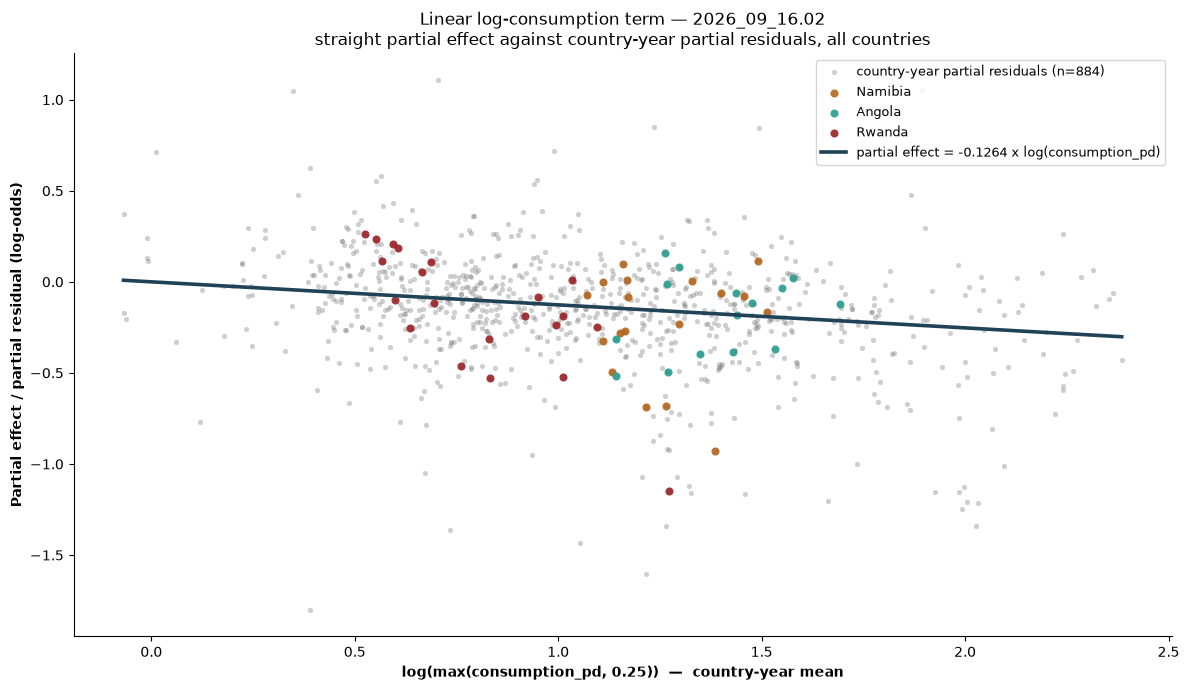

fitted model slope   -0.1264
OLS through points   -0.1831 (intercept +0.0395)
residual sd          0.3135


In [ ]:
# Linear log-consumption term: partial effect line over country-year data ######
# Model LINEAR_MODEL fits a single linear coefficient on the log-transformed
# consumption covariate (transform strategy "log", which floors the value at
# LOG_FLOOR before taking the log). Its partial effect is therefore a straight
# line through the origin,
#     partial effect = beta * log(max(consumption_pd, LOG_FLOOR))
#
# The background points are PARTIAL RESIDUALS, so they sit on the same log-odds
# scale as that line. For each country and birth year:
#     resid = logit(observed neonatal mortality)
#             - intercept
#             - beta_birth_year * birth_year
#             - ranef[country]
#             - mean sex contribution in that cell
# i.e. the observed outcome with every fitted term except consumption removed.
# Country-years with no deaths have an undefined logit and are dropped.
from pathlib import Path

import yaml

LINEAR_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
LINEAR_MODEL = "2026_09_16.02"
LINEAR_VAR = "consumption_pd"
LOG_FLOOR = 0.25  # LogScaler floor in rra_climate_health.transforms.scaling
LINEAR_MIN_OBS = 25  # births needed for a country-year to be plotted
HIGHLIGHT_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
HIGHLIGHT_COLORS = ["#b5651d", "#2a9d8f", "#9b2226"]

_ldir = LINEAR_MODEL_ROOT / LINEAR_MODEL
_lcoefs = pd.read_parquet(_ldir / "base_model_coefs.parquet")["Estimate"]
_lranef = pd.read_parquet(_ldir / "base_model_ranef.parquet")["offset"]
_lspec = yaml.safe_load((_ldir / "specification.yaml").read_text())
_strategy = [
    p["transform"]["strategy"] for p in _lspec["predictors"] if p["name"] == LINEAR_VAR
][0]
if _strategy != "log":
    raise ValueError(f"{LINEAR_MODEL} uses transform strategy '{_strategy}', not 'log'")

beta_cons = float(_lcoefs[LINEAR_VAR])
beta_year = float(_lcoefs["birth_year"])
beta_sex2 = float(_lcoefs["C(sex_id)2"])
intercept = float(_lcoefs["(Intercept)"])
print(
    f"{LINEAR_MODEL}: beta(log {LINEAR_VAR}) = {beta_cons:.6f}"
    f"  -> {100 * (np.exp(beta_cons * np.log(2)) - 1):.2f}% per doubling of consumption"
)

# Country-year cells ###########################################################
_cells = df_raw.assign(
    _x=np.log(np.maximum(df_raw[LINEAR_VAR], LOG_FLOOR)),
    _sex2=(df_raw["sex_id"].astype(int) == 2).astype(float),
)
_cells = (
    _cells.groupby(["ihme_loc_id", "location_name", "birth_year"], as_index=False)
    .agg(
        x=("_x", "mean"),
        nmr=("neonatal_mortality", "mean"),
        deaths=("neonatal_mortality", "sum"),
        frac_female=("_sex2", "mean"),
        n=("neonatal_mortality", "size"),
    )
    .query("n >= @LINEAR_MIN_OBS")
)
_dropped = int((_cells["deaths"] == 0).sum())
_cells = _cells[_cells["deaths"] > 0].copy()
_cells["resid"] = (
    np.log(_cells["nmr"] / (1 - _cells["nmr"]))
    - intercept
    - beta_year * _cells["birth_year"]
    - _cells["ihme_loc_id"].map(_lranef).astype(float)
    - beta_sex2 * _cells["frac_female"]
)
print(
    f"  {len(_cells):,} country-years across {_cells['ihme_loc_id'].nunique()} "
    f"countries ({_dropped} dropped with zero deaths)"
)

# Plot #########################################################################
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    _cells["x"],
    _cells["resid"],
    s=14,
    alpha=0.35,
    color="0.45",
    linewidths=0,
    zorder=1,
    label=f"country-year partial residuals (n={len(_cells):,})",
)
for country, colour in zip(HIGHLIGHT_COUNTRIES, HIGHLIGHT_COLORS):
    sub = _cells[_cells["location_name"] == country]
    ax.scatter(
        sub["x"],
        sub["resid"],
        s=34,
        alpha=0.9,
        color=colour,
        linewidths=0,
        zorder=3,
        label=country,
    )

x_line = np.linspace(_cells["x"].min(), _cells["x"].max(), 200)
ax.plot(
    x_line,
    beta_cons * x_line,
    color="#1f4257",
    lw=2.6,
    zorder=4,
    label=f"partial effect = {beta_cons:.4f} x log({LINEAR_VAR})",
)

ax.set_xlabel(
    f"log(max({LINEAR_VAR}, {LOG_FLOOR}))  —  country-year mean", fontweight="bold"
)
ax.set_ylabel("Partial effect / partial residual (log-odds)", fontweight="bold")
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"Linear log-consumption term — {LINEAR_MODEL}\n"
    f"straight partial effect against country-year partial residuals, all countries",
    fontsize=12,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}linear_log_consumption_partial_effect.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# How the fitted slope compares with the spread of the residuals ###############
_fit = np.polyfit(_cells["x"], _cells["resid"], 1)
print(
    f"fitted model slope   {beta_cons:+.4f}\n"
    f"OLS through points   {_fit[0]:+.4f} (intercept {_fit[1]:+.4f})\n"
    f"residual sd          {_cells['resid'].std():.4f}"
)

Compare the spline on consumption_pd (2026_09_14.02) with the linear term behind INFERENCE_FILE_09_17

spline model 2026_09_14.02: effect at x=6.36e-05 is +0.1577
linear model 2026_09_16.04 (results 2026_09_17.01): beta = -0.041182 per $1/day
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_vs_linear_consumption_pd.pdf


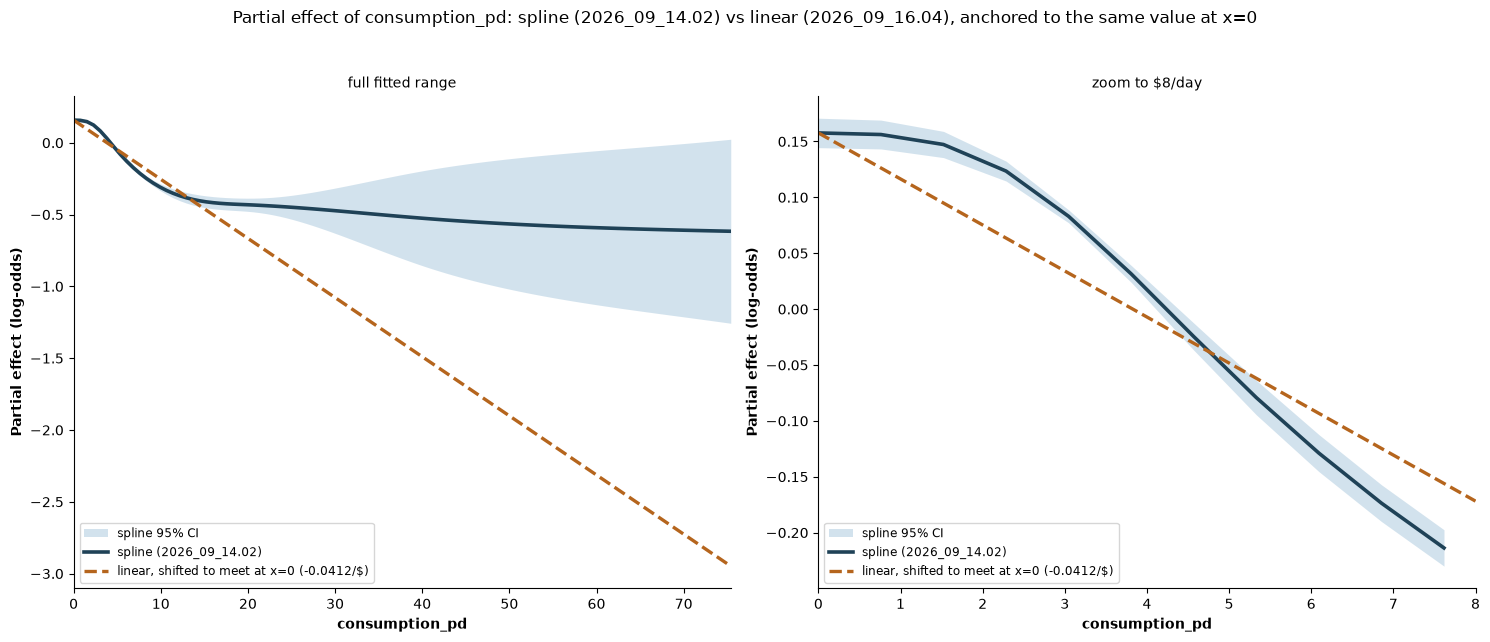

 consumption_pd  spline  linear_shifted  difference
            0.5  0.1567          0.1371     -0.0196
            1.0  0.1534          0.1165     -0.0369
            2.0  0.1324          0.0753     -0.0571
            3.0  0.0855          0.0341     -0.0514
            5.0 -0.0554         -0.0483      0.0072
            8.0 -0.2317         -0.1718      0.0599
           10.0 -0.3113         -0.2542      0.0571
           20.0 -0.4317         -0.6660     -0.2343
           40.0 -0.5253         -1.4896     -0.9643
           75.0 -0.6156         -2.9310     -2.3154

local spline slope (log-odds per $1/day) vs the constant linear slope -0.0412:
  at $  1.0/day  spline -0.0210   ratio  0.51x
  at $  2.0/day  spline -0.0314   ratio  0.76x
  at $  5.0/day  spline -0.0583   ratio  1.42x
  at $ 10.0/day  spline -0.0381   ratio  0.93x
  at $ 20.0/day  spline -0.0120   ratio  0.29x


In [4]:
# Spline vs linear term on consumption_pd ######################################
# Overlays the fitted spline from CMP_SPLINE_MODEL with the single linear
# coefficient from the model behind INFERENCE_FILE_09_17. Both are partial
# effects on the log-odds scale, but a linear term is only identified up to an
# intercept that the model absorbs, so the line is shifted to meet the spline at
# x = 0:
#     line(x) = spline_effect(x_min) + beta * x
# That makes the two directly comparable as slopes, which is the point here.
# The model version behind the results file is read from its results spec rather
# than assumed, since results and model versions differ.

CMP_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
CMP_SPLINE_MODEL = "2026_09_14.02"  # spline on consumption_pd
CMP_LINEAR_RESULTS = INFERENCE_FILE_09_17  # linear on consumption_pd
CMP_VAR = "consumption_pd"
CMP_ZOOM_XMAX = 8.0

# Spline ######################################################################
_cs = pd.read_parquet(
    CMP_MODEL_ROOT / CMP_SPLINE_MODEL / f"spline_effect_{CMP_VAR}.parquet"
)
_cs_lo = _cs["effect"] - 1.96 * _cs["se"]
_cs_hi = _cs["effect"] + 1.96 * _cs["se"]
anchor = float(_cs["effect"].iloc[0])  # spline value at the low end of x

# Linear term #################################################################
_lin_results = Path(CMP_LINEAR_RESULTS).parent
_lin_version = yaml.safe_load((_lin_results / "results_spec.yaml").read_text())[
    "version"
]["model"]
_lin_dir = CMP_MODEL_ROOT / _lin_version
_lin_spec = yaml.safe_load((_lin_dir / "specification.yaml").read_text())
_lin_pred = [p for p in _lin_spec["predictors"] if p["name"] == CMP_VAR][0]
if _lin_pred["spline"] is not None or _lin_pred["transform"]["strategy"] != "identity":
    raise ValueError(
        f"{_lin_version} is not a linear identity term on {CMP_VAR}: "
        f"spline={_lin_pred['spline']}, "
        f"strategy={_lin_pred['transform']['strategy']}"
    )
beta_lin = float(
    pd.read_parquet(_lin_dir / "base_model_coefs.parquet")["Estimate"][CMP_VAR]
)

print(
    f"spline model {CMP_SPLINE_MODEL}: effect at x={_cs['value'].iloc[0]:.4g} is {anchor:+.4f}"
)
print(
    f"linear model {_lin_version} (results {_lin_results.name}): beta = {beta_lin:+.6f} per $1/day"
)

# Plot ########################################################################
fig, axes = plt.subplots(ncols=2, figsize=(15, 6.5))

for ax, x_max, tag in (
    (axes[0], float(_cs["value"].max()), "full fitted range"),
    (axes[1], CMP_ZOOM_XMAX, f"zoom to ${CMP_ZOOM_XMAX:.0f}/day"),
):
    keep = _cs["value"] <= x_max
    ax.fill_between(
        _cs.loc[keep, "value"],
        _cs_lo[keep],
        _cs_hi[keep],
        color="#9dc0d8",
        alpha=0.45,
        linewidth=0,
        label="spline 95% CI",
    )
    ax.plot(
        _cs.loc[keep, "value"],
        _cs.loc[keep, "effect"],
        color="#1f4257",
        lw=2.6,
        label=f"spline ({CMP_SPLINE_MODEL})",
    )
    x_line = np.linspace(0, x_max, 200)
    ax.plot(
        x_line,
        anchor + beta_lin * x_line,
        color="#b5651d",
        lw=2.4,
        ls="--",
        label=f"linear, shifted to meet at x=0 ({beta_lin:+.4f}/$)",
    )
    ax.set_xlim(0, x_max)
    if tag.startswith("zoom"):
        ax.set_ylim(
            min(_cs_lo[keep].min(), anchor + beta_lin * x_max) - 0.02,
            max(_cs_hi[keep].max(), anchor) + 0.02,
        )
    ax.set_xlabel(CMP_VAR, fontweight="bold")
    ax.set_ylabel("Partial effect (log-odds)", fontweight="bold")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(tag, fontsize=10)
    ax.legend(loc="lower left", fontsize=8.5)

fig.suptitle(
    f"Partial effect of {CMP_VAR}: spline ({CMP_SPLINE_MODEL}) vs linear "
    f"({_lin_version}), anchored to the same value at x=0",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))

plot_path = f"{PLOT_OUTPUT}spline_vs_linear_{CMP_VAR}.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Where the two agree and where they part ways #################################
_cmp = pd.DataFrame({CMP_VAR: [0.5, 1, 2, 3, 5, 8, 10, 20, 40, 75]})
_cmp["spline"] = np.interp(_cmp[CMP_VAR], _cs["value"], _cs["effect"])
_cmp["linear_shifted"] = anchor + beta_lin * _cmp[CMP_VAR]
_cmp["difference"] = _cmp["linear_shifted"] - _cmp["spline"]
print(_cmp.round(4).to_string(index=False))

_slope_grid = np.array([1.0, 2.0, 5.0, 10.0, 20.0])
_local = np.gradient(np.interp(_slope_grid, _cs["value"], _cs["effect"]), _slope_grid)
print(
    "\nlocal spline slope (log-odds per $1/day) vs the constant linear slope "
    f"{beta_lin:+.4f}:"
)
for x, sl in zip(_slope_grid, _local):
    print(f"  at ${x:>5.1f}/day  spline {sl:+.4f}   ratio {sl / beta_lin:5.2f}x")

In [12]:
# Country-year aggregate of the training data ##################################
# One row per country and birth year. The two log columns are the log OF the
# aggregate (log of the mean, log of the median), not the mean of the logged
# values - those differ, and the model's log transform uses the latter.
# consumption_pd is strictly positive in this dataset (min 6.36e-05), so no
# floor is needed before taking logs.
df_agg_cy = df_raw.groupby(
    ["ihme_loc_id", "location_name", "birth_year"], as_index=False
).agg(
    neonatal_mortality=("neonatal_mortality", "mean"),
    consumption_pd_mean=("consumption_pd", "mean"),
    consumption_pd_median=("consumption_pd", "median"),
    n_births=("neonatal_mortality", "size"),
)
df_agg_cy["log_consumption_pd_mean"] = np.log(df_agg_cy["consumption_pd_mean"])
df_agg_cy["log_consumption_pd_median"] = np.log(df_agg_cy["consumption_pd_median"])

print(
    f"{len(df_agg_cy):,} country-years across "
    f"{df_agg_cy['ihme_loc_id'].nunique()} countries, "
    f"birth_year {df_agg_cy['birth_year'].min()}-{df_agg_cy['birth_year'].max()}"
)
df_agg_cy.head()

918 country-years across 60 countries, birth_year 1985-2023


,ihme_loc_id,location_name,birth_year,neonatal_mortality,consumption_pd_mean,consumption_pd_median,n_births,log_consumption_pd_mean,log_consumption_pd_median
0,AGO,Angola,2001,0.000000,5.753322,6.467961,5,1.749777,1.866861
1,AGO,Angola,2002,0.019802,5.306616,3.421320,404,1.668954,1.230026
2,AGO,Angola,2003,0.019194,4.641974,3.231227,521,1.535140,1.172862
3,AGO,Angola,2004,0.033482,5.639099,3.534721,448,1.729724,1.262634
4,AGO,Angola,2005,0.022599,4.799794,3.139259,531,1.568573,1.143987


In [13]:
# Binomial GLMM: mortality ~ log median consumption, weighted by births #######
# A binomial GLM with a logit link, so the outcome stays a proportion and the
# link does the transforming - no logit of the observed rate, which means the
# country-years with no deaths are kept rather than dropped. Each cell is
# weighted by n_births, so a country-year built on 4,000 births counts for as
# much more than one built on 40 as its precision deserves.
#
# statsmodels has no binomial mixed model (its MixedLM is Gaussian only), so
# lme4::glmer is driven directly through rpy2.
#
# ---------------------------------------------------------------------------
# WHY THE CACHE
# rpy2 here is compiled against gbd_env but dlopens the R inside the cgf env,
# over a force-loaded foreign libstdc++. That mix segfaults the kernel at
# random - measured at roughly a coin flip per run, landing on whatever R call
# happens to be executing. A segfault takes the whole kernel with it.
#
# So the fit is written to MM_CACHE on success and reloaded from there
# afterwards. Once one run gets through, this cell never touches R again and
# the rest of the notebook runs on any kernel. Set MM_REFIT = True to force it
# back through R (e.g. after changing the data or the formula).
# ---------------------------------------------------------------------------
import json
import os

MM_X = "log_consumption_pd_median"
MM_WEIGHT = "n_births"
MM_CACHE = Path("mm_glmm_fit.json")  # beside this notebook
MM_REFIT = False

mm_df = df_agg_cy.dropna(subset=["neonatal_mortality", MM_X, MM_WEIGHT]).copy()
print(
    f"{len(mm_df):,} country-years, {mm_df['ihme_loc_id'].nunique()} countries, "
    f"{int(mm_df[MM_WEIGHT].sum()):,} births; "
    f"{int((mm_df['neonatal_mortality'] == 0).sum())} cells with zero deaths are "
    f"kept (the binomial likelihood handles them)"
)

# What the cache has to match for it to still describe this data
mm_signature = {
    "x": MM_X,
    "weight": MM_WEIGHT,
    "n_rows": int(len(mm_df)),
    "n_groups": int(mm_df["ihme_loc_id"].nunique()),
    "outcome_sum": round(
        float((mm_df["neonatal_mortality"] * mm_df[MM_WEIGHT]).sum()), 6
    ),
    "x_sum": round(float(mm_df[MM_X].sum()), 6),
}

_cached = None
if MM_CACHE.exists() and not MM_REFIT:
    _c = json.loads(MM_CACHE.read_text())
    if _c.get("signature") == mm_signature:
        _cached = _c
    else:
        print(f"cache at {MM_CACHE} was fitted on different data - refitting in R")

if _cached is not None:
    mm_fixef = _cached["fixef"]
    mm_ranef = _cached["ranef"]
    mm_ranef_sd = _cached["ranef_sd"]
    mm_se = _cached["se"]
    print(f"loaded the fit from {MM_CACHE} (fitted {_cached['fitted_at']}); R not used")
else:
    # Run this on the "gbd_env (with R)" kernel. gbd_env ships no R of its own,
    # and R 4.4.3 needs a newer libstdc++ than the system one that pandas and
    # numpy load first - so that kernelspec sets both R_HOME and LD_PRELOAD in
    # its env block (~/.local/share/jupyter/kernels/gbd_env_r/kernel.json).
    #
    # LD_PRELOAD has to be set before the process starts, so a plain gbd_env
    # kernel cannot be rescued from inside the notebook: importing rpy2 there
    # fails outright. The check below turns that into a readable error.
    #
    # R_HOME is read once, when rpy2.rinterface_lib.openrlib is first imported,
    # and cached on that module. If rpy2 was ever imported in this kernel
    # without it set, the cached value stays None and you get "Unable to
    # determine R_HOME" whatever this cell does - restart the kernel then.
    os.environ.setdefault("R_HOME", "/ihme/homes/elyeb/miniconda3/envs/cgf/lib/R")
    if "libstdc++" not in os.environ.get("LD_PRELOAD", ""):
        raise RuntimeError(
            'No cached fit, so this needs the "gbd_env (with R)" kernel. Select '
            "it, restart the kernel and run the notebook from the top."
        )

    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter

    ro.r("suppressMessages(library(lme4))")
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv["mm_r_df"] = ro.conversion.py2rpy(
            mm_df[["ihme_loc_id", "neonatal_mortality", MM_X, MM_WEIGHT]]
        )
    ro.globalenv["mm_fit_r"] = ro.r(
        f"glmer(neonatal_mortality ~ {MM_X} + (1 | ihme_loc_id), data = mm_r_df, "
        f'family = binomial(link = "logit"), weights = {MM_WEIGHT})'
    )
    print(ro.r("paste(capture.output(summary(mm_fit_r)), collapse = '\\n')")[0])

    # Pull the fit into python so the plotting cells never touch R
    _fx = ro.r("fixef(mm_fit_r)")
    mm_fixef = dict(zip(list(_fx.names), [float(v) for v in _fx]))
    _se = ro.r("sqrt(diag(as.matrix(vcov(mm_fit_r))))")
    mm_se = dict(zip(list(_se.names), [float(v) for v in _se]))
    mm_ranef_sd = float(ro.r('attr(VarCorr(mm_fit_r)$ihme_loc_id, "stddev")')[0])
    with localconverter(ro.default_converter + pandas2ri.converter):
        _rf = ro.conversion.rpy2py(ro.r("as.data.frame(ranef(mm_fit_r))"))
    mm_ranef = dict(zip(_rf["grp"].astype(str), _rf["condval"].astype(float)))

    MM_CACHE.write_text(
        json.dumps(
            {
                "signature": mm_signature,
                "fitted_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
                "formula": f"neonatal_mortality ~ {MM_X} + (1 | ihme_loc_id)",
                "fixef": mm_fixef,
                "se": mm_se,
                "ranef_sd": mm_ranef_sd,
                "ranef": mm_ranef,
            },
            indent=1,
        )
    )
    print(f"\nfit cached to {MM_CACHE.resolve()} - later runs skip R entirely")


def mm_predict(frame, use_ranef=True):
    """Fitted mortality on the probability scale (inverse logit link)."""
    z = mm_fixef["(Intercept)"] + mm_fixef[MM_X] * frame[MM_X]
    if use_ranef:
        z = z + frame["ihme_loc_id"].map(mm_ranef).fillna(0.0)
    return 1 / (1 + np.exp(-z))


print(
    f"\nslope on {MM_X}: {mm_fixef[MM_X]:+.6f} log-odds per log unit "
    f"(se {mm_se[MM_X]:.6f})"
    f"\n  -> {100 * (np.exp(mm_fixef[MM_X] * np.log(2)) - 1):+.2f}% change in the "
    f"odds of neonatal death per doubling of median consumption"
)
print(
    f"random intercept sd: {mm_ranef_sd:.4f} over {len(mm_ranef)} countries; "
    f"intercept {mm_fixef['(Intercept)']:+.4f}"
)

918 country-years, 60 countries, 1,711,538 births; 28 cells with zero deaths are kept (the binomial likelihood handles them)
loaded the fit from mm_glmm_fit.json (fitted 2026-09-17 15:43); R not used

slope on log_consumption_pd_median: -0.645337 log-odds per log unit (se 0.028640)
  -> -36.07% change in the odds of neonatal death per doubling of median consumption
random intercept sd: 0.3286 over 60 countries; intercept -2.9052


Row-1 covariate trajectories with the country-year mixed model overlaid in black

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/row1_with_mixed_model.pdf


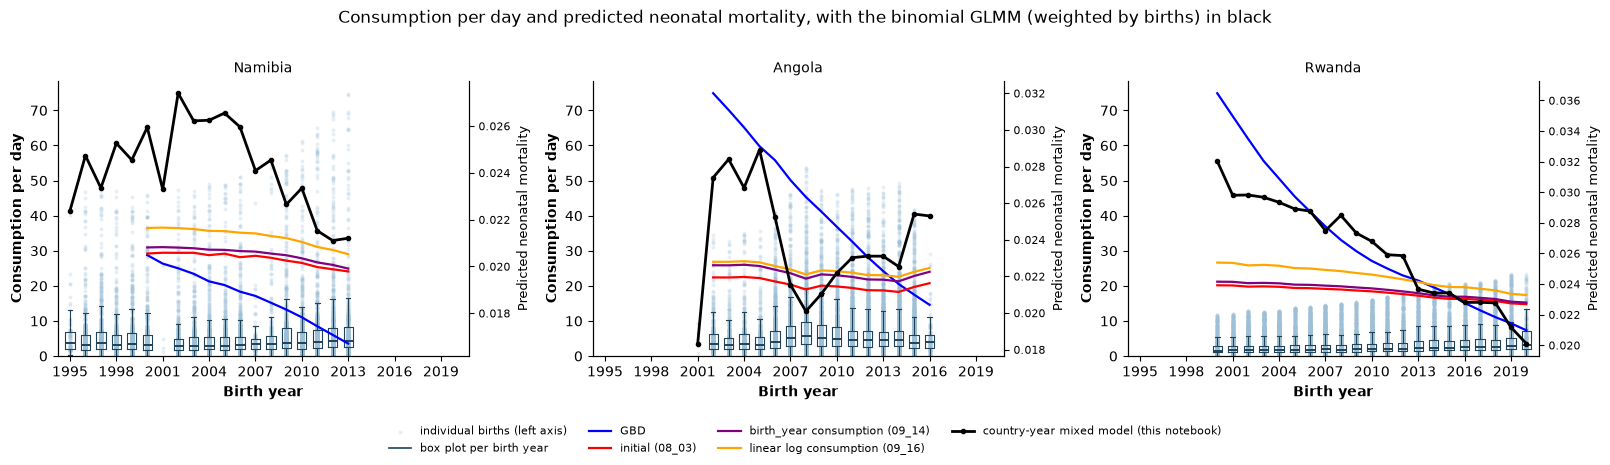

                   min      max
location_name                  
Angola         0.01833  0.02891
Namibia        0.02111  0.02740
Rwanda         0.02011  0.03204


In [25]:
# Row-1 trajectories, with the country-year mixed model overlaid ##############
# Same content as the first row of the covariate-trajectory figure: one column
# per country, consumption_pd against birth_year on the left axis (individual
# births plus a box plot per year), and predicted neonatal mortality on a twin
# right axis. Adds the binomial GLMM fitted in this notebook as a BLACK line.
#
# That model is fitted on country-year aggregates, so its prediction for a cell
# is  expit(intercept + slope * log median consumption + random intercept).
# The other series come from raster inference and are sex-averaged.
MM_COLOR = "black"
MM_LABEL = "country-year mixed model (this notebook)"
R1_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
R1_MIN_OBS = 25
R1_POINT_COLOR = "#9dc0d8"
R1_BOX_COLOR = "#1f4257"
R1_PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD"),
    "prevalence_initial": ("red", "initial (08_03)"),
    "prevalence_birth_year_consumption": ("purple", "birth_year consumption (09_14)"),
    "prevalence_linear_log_consumption": ("orange", "linear log consumption (09_16)"),
}


def _r1_mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


# Inference / GBD series, rebuilt here so the cell stands on its own ###########
_r1_key = ["location_id", "year_id", "sex_id"]
_r1_sources = {
    "prevalence_gbd": (GBD_FILE, False),
    "prevalence_initial": (INFERENCE_FILE_08_03, True),
    "prevalence_birth_year_consumption": (INFERENCE_FILE_09_14, True),
    "prevalence_linear_log_consumption": (INFERENCE_FILE_09_16, True),
}
r1_pred = None
for _col, (_path, _is_draws) in _r1_sources.items():
    _f = pd.read_parquet(_path).reset_index()
    _f = (
        _r1_mean_draw(_f).rename(columns={"prevalence": _col})
        if _is_draws
        else _f.rename(columns={"gbd_mean_prevalence": _col})
    )
    _f = _f[_r1_key + [_col]]
    r1_pred = _f if r1_pred is None else r1_pred.merge(_f, on=_r1_key, how="inner")
r1_pred = (
    r1_pred.merge(locs[["location_id", "location_name"]], on="location_id", how="left")
    .query("location_name in @R1_COUNTRIES")
    .groupby(["location_name", "year_id"], as_index=False)[list(R1_PRED_COLS)]
    .mean()
)

# Mixed-model fitted values, including the country random intercept ############
# mm_predict inverts the logit link, so the line stays in the same mortality
# units as the inference series on the right axis.
mm_pred = mm_df[["ihme_loc_id", "location_name", "birth_year"]].copy()
mm_pred["mm_fitted"] = mm_predict(mm_df)
mm_pred = mm_pred.query("location_name in @R1_COUNTRIES")

# Shared limits ################################################################
_r1_sel = df_raw[df_raw["location_name"].isin(R1_COUNTRIES)]
_r1_counts = _r1_sel.groupby(["location_name", "birth_year"]).size()
_r1_years = _r1_counts[_r1_counts >= R1_MIN_OBS].index.get_level_values("birth_year")
r1_year_lim = (_r1_years.min() - 0.8, _r1_years.max() + 0.8)
r1_ylim = (0.0, float(_r1_sel["consumption_pd"].max()) * 1.05)

# Plot #########################################################################
fig, axes = plt.subplots(
    ncols=len(R1_COUNTRIES), figsize=(5.4 * len(R1_COUNTRIES), 4.6)
)
axes = np.atleast_1d(axes)
handles, labels = [], []

for ax, country in zip(axes, R1_COUNTRIES):
    sub = df_raw[df_raw["location_name"] == country]
    ax.scatter(
        sub["birth_year"],
        sub["consumption_pd"],
        s=8,
        alpha=0.25,
        color=R1_POINT_COLOR,
        linewidths=0,
        zorder=1,
        label="individual births (left axis)",
    )

    counts = sub.groupby("birth_year").size()
    kept_years = counts[counts >= R1_MIN_OBS].index
    if len(kept_years):
        ax.boxplot(
            [
                sub.loc[sub["birth_year"] == yr, "consumption_pd"].dropna().to_numpy()
                for yr in kept_years
            ],
            positions=list(kept_years),
            widths=0.6,
            manage_ticks=False,
            showfliers=False,
            zorder=2,
            boxprops={"color": R1_BOX_COLOR, "linewidth": 0.8},
            whiskerprops={"color": R1_BOX_COLOR, "linewidth": 0.8},
            capprops={"color": R1_BOX_COLOR, "linewidth": 0.8},
            medianprops={"color": R1_BOX_COLOR, "linewidth": 1.4},
        )

    y0, y1 = kept_years.min(), kept_years.max()
    p = r1_pred[
        (r1_pred["location_name"] == country) & r1_pred["year_id"].between(y0, y1)
    ].sort_values("year_id")
    m = mm_pred[mm_pred["location_name"] == country].sort_values("birth_year")

    ax2 = ax.twinx()
    for pred_col, (colour, label) in R1_PRED_COLS.items():
        ax2.plot(p["year_id"], p[pred_col], color=colour, lw=1.6, zorder=3, label=label)
    ax2.plot(
        m["birth_year"],
        m["mm_fitted"],
        color=MM_COLOR,
        lw=2.0,
        marker="o",
        ms=3,
        zorder=4,
        label=MM_LABEL,
    )
    ax2.set_ylabel("Predicted neonatal mortality", fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(*r1_year_lim)
    ax.set_ylim(*r1_ylim)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Birth year", fontweight="bold")
    ax.set_ylabel("Consumption per day", fontweight="bold")
    ax.set_title(country, fontsize=10)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    if not handles:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles, labels = h1 + h2, l1 + l2
        handles.insert(1, plt.Line2D([], [], color=R1_BOX_COLOR, lw=1.2))
        labels.insert(1, "box plot per birth year")

fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False)
fig.suptitle(
    "Consumption per day and predicted neonatal mortality, with the "
    "binomial GLMM (weighted by births) in black",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0.10, 1, 0.97))

plot_path = f"{PLOT_OUTPUT}row1_with_mixed_model.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print(
    mm_pred.groupby("location_name")["mm_fitted"]
    .agg(["min", "max"])
    .round(5)
    .to_string()
)

In [ ]:
# Median consumption vs predictions: mixed model, then GBD #####################
# Two rows, one panel each, over every country-year the GLMM was fitted
# on (all countries, not just the three focus ones).
#   row 1: the mixed model's fitted value, intercept + slope * median + ranef
#   row 2: GBD prevalence for the same country-year, averaged over sex
# GBD is indexed by year_id, so it is joined to birth_year.
SC_POINT_COLOR = "#1f4257"

# Mixed-model fitted values, including the country random intercept
# The model uses a logit link, so mm_predict inverts it back to mortality; the
# x axis stays the raw median so it is comparable with GBD below.
sc = mm_df[
    ["ihme_loc_id", "location_name", "birth_year", "consumption_pd_median"]
].copy()
sc["mm_pred"] = mm_predict(mm_df)

# GBD for the same country-years, averaged over sex
_sc_gbd = (
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .groupby(["location_id", "year_id"], as_index=False)["gbd_mean_prevalence"]
    .mean()
    .merge(locs[["location_id", "ihme_loc_id"]], on="location_id", how="left")
    .rename(columns={"year_id": "birth_year", "gbd_mean_prevalence": "gbd_pred"})
)
sc = sc.merge(
    _sc_gbd[["ihme_loc_id", "birth_year", "gbd_pred"]],
    on=["ihme_loc_id", "birth_year"],
    how="left",
)

sc_specs = [
    ("mm_pred", "Mixed-model predicted mortality"),
    ("gbd_pred", "GBD predicted mortality"),
]

fig, axes = plt.subplots(nrows=len(sc_specs), ncols=1, figsize=(9, 9))
axes = np.atleast_1d(axes)

for ax, (y_col, y_label) in zip(axes, sc_specs):
    d = sc.dropna(subset=["consumption_pd_median", y_col])
    ax.scatter(
        d["consumption_pd_median"],
        d[y_col],
        s=16,
        alpha=0.4,
        color=SC_POINT_COLOR,
        linewidths=0,
    )
    r = d[["consumption_pd_median", y_col]].corr().iloc[0, 1]
    ax.set_title(
        f"{y_label} vs median consumption_pd  " f"(r = {r:.2f}, n = {len(d):,})",
        fontsize=11,
    )
    # anchored at zero; note the mixed model can predict below 0, see the print
    ax.set_ylim(bottom=0.0)
    ax.set_xlabel("Median consumption per day (country-year)", fontweight="bold")
    ax.set_ylabel(y_label, fontweight="bold")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}median_consumption_vs_predictions.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print(
    sc[["consumption_pd_median", "mm_pred", "gbd_pred"]]
    .describe()
    .loc[["count", "mean", "min", "max"]]
    .round(4)
    .to_string()
)
for _c in ("mm_pred", "gbd_pred"):
    _n = int((sc[_c] < 0).sum())
    if _n:
        print(
            f"note: {_n} {_c} value(s) below 0 are outside the anchored y range "
            f"(min {sc[_c].min():.4f})"
        )

print("\ncorrelation with median consumption_pd:")
print(
    sc[["consumption_pd_median", "mm_pred", "gbd_pred"]]
    .corr()["consumption_pd_median"]
    .round(3)
    .to_string()
)

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/observed_vs_gbd_country_year.pdf


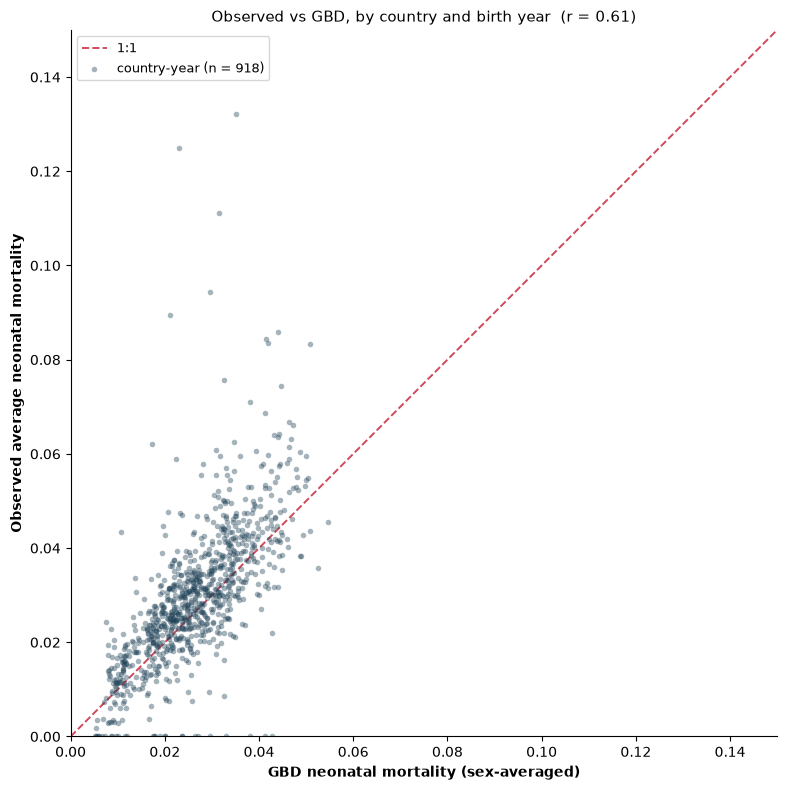

note: 1 country-year(s) fall outside the 0.15 axes:
location_name  birth_year  neonatal_mortality    gbd  n_births
      Namibia        2001                0.25 0.0201         4
       neonatal_mortality       gbd  difference
count            918.0000  918.0000    918.0000
mean               0.0300    0.0263      0.0037
std                0.0168    0.0100      0.0133
min                0.0000    0.0052     -0.0427
max                0.2500    0.0547      0.2299

observed above GBD in 66.2% of country-years;  mean difference +0.0037


In [16]:
# Observed country-year mortality vs GBD ######################################
# y: the average neonatal mortality actually seen in the training data for that
#    country and birth year (df_agg_cy, so all 918 cells - no logit is taken
#    here, which means the zero-death cells that the models drop are kept).
# x: GBD prevalence for the same country-year, averaged over sex. GBD is indexed
#    by year_id, so it is joined to birth_year.
# Axes share one range anchored at 0 and a 1:1 line is drawn, so distance from
# the diagonal reads directly as disagreement.
OBS_POINT_COLOR = "#1f4257"

obs_gbd = df_agg_cy[
    ["ihme_loc_id", "location_name", "birth_year", "neonatal_mortality", "n_births"]
].merge(
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .groupby(["location_id", "year_id"], as_index=False)["gbd_mean_prevalence"]
    .mean()
    .merge(locs[["location_id", "ihme_loc_id"]], on="location_id", how="left")
    .rename(columns={"year_id": "birth_year", "gbd_mean_prevalence": "gbd"})[
        ["ihme_loc_id", "birth_year", "gbd"]
    ],
    on=["ihme_loc_id", "birth_year"],
    how="inner",
)

# Zoomed to the bulk of the data; a handful of tiny-n cells sit above this and
# are reported below rather than silently dropped.
AXIS_MAX = 0.15
lim = (0.0, AXIS_MAX)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lim, lim, color="#d1495b", lw=1.4, ls="--", zorder=1, label="1:1")
ax.scatter(
    obs_gbd["gbd"],
    obs_gbd["neonatal_mortality"],
    s=16,
    alpha=0.4,
    color=OBS_POINT_COLOR,
    linewidths=0,
    zorder=2,
    label=f"country-year (n = {len(obs_gbd):,})",
)
r = obs_gbd[["gbd", "neonatal_mortality"]].corr().iloc[0, 1]
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_aspect("equal")
ax.set_xlabel("GBD neonatal mortality (sex-averaged)", fontweight="bold")
ax.set_ylabel("Observed average neonatal mortality", fontweight="bold")
ax.set_title(f"Observed vs GBD, by country and birth year  (r = {r:.2f})", fontsize=11)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}observed_vs_gbd_country_year.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

_clipped = obs_gbd[
    (obs_gbd["neonatal_mortality"] > AXIS_MAX) | (obs_gbd["gbd"] > AXIS_MAX)
]
if len(_clipped):
    print(f"note: {len(_clipped)} country-year(s) fall outside the {AXIS_MAX} axes:")
    print(
        _clipped[
            ["location_name", "birth_year", "neonatal_mortality", "gbd", "n_births"]
        ]
        .sort_values("neonatal_mortality", ascending=False)
        .round(4)
        .to_string(index=False)
    )

obs_gbd["difference"] = obs_gbd["neonatal_mortality"] - obs_gbd["gbd"]
print(
    obs_gbd[["neonatal_mortality", "gbd", "difference"]]
    .describe()
    .loc[["count", "mean", "std", "min", "max"]]
    .round(4)
    .to_string()
)
print(
    f"\nobserved above GBD in {100 * (obs_gbd['difference'] > 0).mean():.1f}% of "
    f"country-years;  mean difference {obs_gbd['difference'].mean():+.4f}"
)

Fit on median values per country from Resource Tracking data

In [8]:
consumption_rt_df = pd.read_parquet(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/input/ldi/v8/national_estimates.parquet"
)
consumption_rt_df = consumption_rt_df[consumption_rt_df["scenario"] == "reference"]
consumption_rt_df = consumption_rt_df[consumption_rt_df["population_percentile"] == 0.5]
consumption_rt_df.rename(columns={"year_id": "birth_year"}, inplace=True)
consumption_rt_df["consumption_pd"] = consumption_rt_df["ldipc"] / 365
consumption_rt_df.head()

,ihme_loc_id,birth_year,location_id,scenario,population_percentile,ldipc,consumption_pd
16,AFG,1980,160,reference,0.5,711.867240,1.950321
49,AFG,1981,160,reference,0.5,769.950990,2.109455
82,AFG,1982,160,reference,0.5,823.634452,2.256533
115,AFG,1983,160,reference,0.5,859.868645,2.355805
148,AFG,1984,160,reference,0.5,871.257651,2.387007


GLMM predictions on `consumption_rt_df`, three focus countries

144 location(s) have no fitted random intercept and get the population-average prediction: AFG, AND, ARE, ARG, ASM, ATG, AUS, AUT ...
dropping 19584 row(s) outside birth_year 1995-2019; the model is only predicted over the same window as the earlier plots
predicted 5,100 rows across 204 locations, birth_year 1995-2019
left axis capped at $20.5/day (p97.5 of plotted births); 1,670 of 73,903 birth points above it are not drawn (2.3%)
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/consumption_rt_predictions.pdf


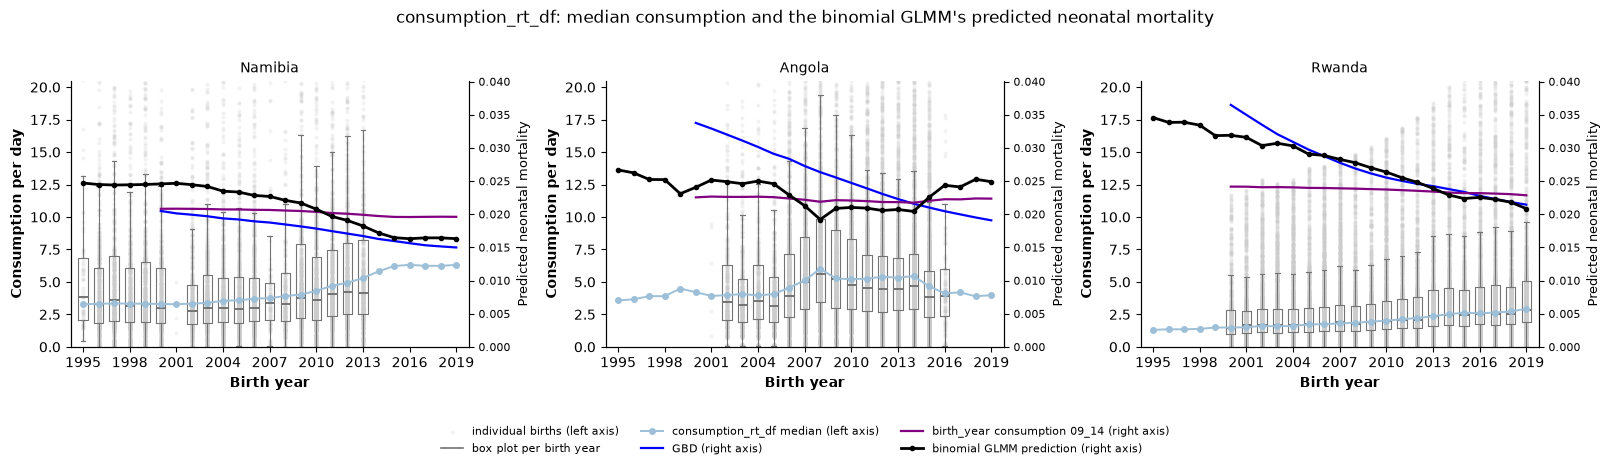

               years  first_year  last_year  cons_min  cons_max  pred_min  pred_max
location_name                                                                      
Angola            25        1995       2019    3.5698    6.0155    0.0192    0.0267
Namibia           25        1995       2019    3.2744    6.3159    0.0163    0.0247
Rwanda            25        1995       2019    1.3079    2.9286    0.0208    0.0346


In [16]:
# GLMM predictions on consumption_rt_df, three focus countries ################
# consumption_rt_df carries one consumption_pd per ihme_loc_id and birth_year,
# already a median, so it lines up with what the model was fitted on. The model
# covariate is the LOG of that median, so the log is taken here rather than
# assumed to be present.
#
# Left axis, in grey, the survey data behind the fit: the individual births from
# df_raw plus a box plot per birth year, exactly as in the first row of the
# covariate-trajectory figure. The light blue line is the consumption_rt_df
# median on top of it, so the two consumption sources sit on one axis.
#
# Right axis, predicted neonatal mortality: GBD and the 09_14 inference run in
# the same solid colours they carry elsewhere in this notebook, plus the
# binomial GLMM fitted here in black.
#
# Individual births reach ~$75/day while the medians sit near $2-6, so the left
# axis is capped at the RT_CONS_PCT-th percentile of the plotted births and the
# number of points above the cap is reported. The box plots hide fliers anyway,
# so the cap only clips the scatter.
RT_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
RT_YEARS = (1995, 2019)  # same window the earlier trajectory plots cover
RT_MIN_OBS = 25  # births needed for a year to get a box plot
RT_CONS_PCT = 97.5  # left-axis cap, percentile of the plotted births
RT_POINT_COLOR = "#9dc0d8"  # light blue, as in the row-1 trajectory plots
RT_RAW_COLOR = "0.80"  # light grey individual births
RT_BOX_COLOR = "0.45"  # slightly darker grey, so the boxes read over the points
RT_MM_COLOR = "black"

# Right-axis series drawn from file, in this notebook's usual colours
RT_PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD (right axis)"),
    "prevalence_birth_year_consumption": (
        "purple",
        "birth_year consumption 09_14 (right axis)",
    ),
}
_RT_SOURCES = {
    "prevalence_gbd": (GBD_FILE, False),
    "prevalence_birth_year_consumption": (INFERENCE_FILE_09_14, True),
}

rt = consumption_rt_df.copy()
rt["ihme_loc_id"] = rt["ihme_loc_id"].astype(str)

# Guard the log: a non-positive median has no log and would poison the fit
_rt_bad = int((rt["consumption_pd"] <= 0).sum()) + int(
    rt["consumption_pd"].isna().sum()
)
if _rt_bad:
    print(f"dropping {_rt_bad} row(s) with consumption_pd <= 0 or missing")
    rt = rt[rt["consumption_pd"] > 0]
rt[MM_X] = np.log(rt["consumption_pd"])

# Countries the model never saw get the fixed effect only (ranef 0), which is a
# different quantity - say so rather than letting it pass silently.
_rt_unseen = sorted(set(rt["ihme_loc_id"]) - set(mm_ranef))
if _rt_unseen:
    print(
        f"{len(_rt_unseen)} location(s) have no fitted random intercept and get "
        f"the population-average prediction: {', '.join(_rt_unseen[:8])}"
        + (" ..." if len(_rt_unseen) > 8 else "")
    )

_rt_outside = int((~rt["birth_year"].between(*RT_YEARS)).sum())
if _rt_outside:
    print(
        f"dropping {_rt_outside} row(s) outside birth_year "
        f"{RT_YEARS[0]}-{RT_YEARS[1]}; the model is only predicted over the same "
        f"window as the earlier plots"
    )
rt = rt[rt["birth_year"].between(*RT_YEARS)]

rt["mm_fitted"] = mm_predict(rt)
rt = rt.merge(
    locs[["ihme_loc_id", "location_name"]].drop_duplicates("ihme_loc_id"),
    on="ihme_loc_id",
    how="left",
)
print(
    f"predicted {len(rt):,} rows across {rt['ihme_loc_id'].nunique()} locations, "
    f"birth_year {int(rt['birth_year'].min())}-{int(rt['birth_year'].max())}"
)

# One value per country-year for the lines, in case a location-year repeats
rt_cy = (
    rt.groupby(["location_name", "birth_year"], as_index=False)
    .agg(consumption_pd=("consumption_pd", "median"), mm_fitted=("mm_fitted", "median"))
    .sort_values("birth_year")
)


def _rt_mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


# GBD and inference series for the same country-years, averaged over sex #######
_rt_key = ["location_id", "year_id", "sex_id"]
rt_pred = None
for _col, (_path, _is_draws) in _RT_SOURCES.items():
    _f = pd.read_parquet(_path).reset_index()
    _f = (
        _rt_mean_draw(_f).rename(columns={"prevalence": _col})
        if _is_draws
        else _f.rename(columns={"gbd_mean_prevalence": _col})
    )
    _f = _f[_rt_key + [_col]]
    rt_pred = _f if rt_pred is None else rt_pred.merge(_f, on=_rt_key, how="inner")
rt_pred = (
    rt_pred.merge(
        locs[["location_id", "location_name"]].drop_duplicates("location_id"),
        on="location_id",
        how="left",
    )
    .query("location_name in @RT_COUNTRIES")
    .groupby(["location_name", "year_id"], as_index=False)[list(RT_PRED_COLS)]
    .mean()
    .sort_values("year_id")
)

_rt_missing = [c for c in RT_COUNTRIES if c not in set(rt["location_name"])]
if _rt_missing:
    print(f"not present in consumption_rt_df, panel will be empty: {_rt_missing}")

# Shared limits so the three panels are directly comparable ####################
rt_xlim = (RT_YEARS[0] - 0.8, RT_YEARS[1] + 0.8)
_rt_raw = df_raw[
    df_raw["location_name"].isin(RT_COUNTRIES) & df_raw["birth_year"].between(*RT_YEARS)
]
_rt_cy_sel = rt_cy[rt_cy["location_name"].isin(RT_COUNTRIES)]
rt_cons_max = (
    max(
        float(np.nanpercentile(_rt_raw["consumption_pd"], RT_CONS_PCT)),
        float(_rt_cy_sel["consumption_pd"].max()),
    )
    * 1.05
)
_rt_clipped = int((_rt_raw["consumption_pd"] > rt_cons_max).sum())
print(
    f"left axis capped at ${rt_cons_max:.1f}/day (p{RT_CONS_PCT} of plotted "
    f"births); {_rt_clipped:,} of {len(_rt_raw):,} birth points above it are not "
    f"drawn ({100 * _rt_clipped / len(_rt_raw):.1f}%)"
)

_rt_mort = pd.concat(
    [rt.loc[rt["location_name"].isin(RT_COUNTRIES), "mm_fitted"]]
    + [rt_pred[c] for c in RT_PRED_COLS]
)
rt_ylim2 = (0.0, float(_rt_mort.max()) * 1.10)

fig, axes = plt.subplots(
    ncols=len(RT_COUNTRIES), figsize=(5.4 * len(RT_COUNTRIES), 4.6)
)
axes = np.atleast_1d(axes)
handles, labels = [], []

for ax, country in zip(axes, RT_COUNTRIES):
    line = rt_cy[rt_cy["location_name"] == country]
    raw = _rt_raw[_rt_raw["location_name"] == country]

    # Survey births behind everything, in grey
    ax.scatter(
        raw["birth_year"],
        raw["consumption_pd"],
        s=8,
        alpha=0.25,
        color=RT_RAW_COLOR,
        linewidths=0,
        zorder=1,
        label="individual births (left axis)",
    )
    counts = raw.groupby("birth_year").size()
    kept_years = counts[counts >= RT_MIN_OBS].index
    if len(kept_years):
        ax.boxplot(
            [
                raw.loc[raw["birth_year"] == yr, "consumption_pd"].dropna().to_numpy()
                for yr in kept_years
            ],
            positions=list(kept_years),
            widths=0.6,
            manage_ticks=False,
            showfliers=False,
            zorder=2,
            boxprops={"color": RT_BOX_COLOR, "linewidth": 0.8},
            whiskerprops={"color": RT_BOX_COLOR, "linewidth": 0.8},
            capprops={"color": RT_BOX_COLOR, "linewidth": 0.8},
            medianprops={"color": RT_BOX_COLOR, "linewidth": 1.4},
        )

    ax.plot(
        line["birth_year"],
        line["consumption_pd"],
        color=RT_POINT_COLOR,
        lw=1.4,
        marker="o",
        ms=4,
        zorder=3,
        label="consumption_rt_df median (left axis)",
    )

    ax2 = ax.twinx()
    p = rt_pred[
        (rt_pred["location_name"] == country) & rt_pred["year_id"].between(*RT_YEARS)
    ]
    for pred_col, (colour, label) in RT_PRED_COLS.items():
        ax2.plot(p["year_id"], p[pred_col], color=colour, lw=1.6, zorder=4, label=label)
    ax2.plot(
        line["birth_year"],
        line["mm_fitted"],
        color=RT_MM_COLOR,
        lw=2.0,
        marker="o",
        ms=3,
        zorder=5,
        label="binomial GLMM prediction (right axis)",
    )
    ax2.set_ylim(*rt_ylim2)
    ax2.set_ylabel("Predicted neonatal mortality", fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(*rt_xlim)
    ax.set_ylim(0, rt_cons_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Birth year", fontweight="bold")
    ax.set_ylabel("Consumption per day", fontweight="bold")
    ax.set_title(country, fontsize=10)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    if not handles:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles, labels = h1 + h2, l1 + l2
        handles.insert(1, plt.Line2D([], [], color=RT_BOX_COLOR, lw=1.2))
        labels.insert(1, "box plot per birth year")

fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8, frameon=False)
fig.suptitle(
    "consumption_rt_df: median consumption and the binomial GLMM's predicted "
    "neonatal mortality",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0.12, 1, 0.97))

plot_path = f"{PLOT_OUTPUT}consumption_rt_predictions.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# What the predictions actually span in each panel #############################
print(
    rt_cy[rt_cy["location_name"].isin(RT_COUNTRIES)]
    .groupby("location_name")
    .agg(
        years=("birth_year", "size"),
        first_year=("birth_year", "min"),
        last_year=("birth_year", "max"),
        cons_min=("consumption_pd", "min"),
        cons_max=("consumption_pd", "max"),
        pred_min=("mm_fitted", "min"),
        pred_max=("mm_fitted", "max"),
    )
    .round(4)
    .to_string()
)

Same panels for every available country, grouped by `super_region_name`, 9 per page → PDF

In [20]:
# The same panels for every available country, as a multi-page PDF ############
# Same content as the three-country figure: grey survey births and a box plot
# per birth year on the left axis with the consumption_rt_df median over them,
# and GBD, the 09_14 inference run and the binomial GLMM on the right axis.
#
# Countries are grouped by super_region_name, a new page per super region, nine
# panels to a page. Nothing is drawn inline - the whole thing goes to one PDF.
#
# Axis limits are PER PANEL here, not shared as they are in the three-country
# figure. Consumption spans ~$1/day to over $100/day across this set, so one
# shared scale would flatten most panels to a flat line near zero. That means
# panels are individually readable but not directly comparable by eye.
#
# Two things vary by country and are flagged in each panel's title:
#   "no survey" - the country is absent from df_raw, so there is no grey layer
#   "pop-avg"   - the GLMM never fitted a random intercept for it, so its
#                 prediction is the population average rather than country
#                 specific
ALL_YEARS = RT_YEARS
ALL_MIN_OBS = RT_MIN_OBS
ALL_CONS_PCT = RT_CONS_PCT
ALL_NCOLS, ALL_NROWS = 3, 3
ALL_PDF = f"{PLOT_OUTPUT}consumption_rt_predictions_all_countries.pdf"

# Location metadata: countries only, with their super region ###################
_all_locs = (
    locs.loc[
        locs["level"] == 3,
        ["ihme_loc_id", "location_id", "location_name", "super_region_name"],
    ]
    .drop_duplicates("ihme_loc_id")
    .dropna(subset=["super_region_name"])
)

# Consumption series and GLMM predictions for every country ####################
_all_rt = consumption_rt_df.copy()
_all_rt["ihme_loc_id"] = _all_rt["ihme_loc_id"].astype(str)
_all_rt = _all_rt[
    (_all_rt["consumption_pd"] > 0) & _all_rt["birth_year"].between(*ALL_YEARS)
]
_all_rt[MM_X] = np.log(_all_rt["consumption_pd"])
_all_rt["mm_fitted"] = mm_predict(_all_rt)
_all_rt = _all_rt.merge(_all_locs, on="ihme_loc_id", how="inner")

all_cy = (
    _all_rt.groupby(
        ["super_region_name", "location_name", "ihme_loc_id", "birth_year"],
        as_index=False,
    )
    .agg(consumption_pd=("consumption_pd", "median"), mm_fitted=("mm_fitted", "median"))
    .sort_values("birth_year")
)

# GBD and 09_14 for every country, averaged over sex ###########################
_all_pred = None
for _col, (_path, _is_draws) in _RT_SOURCES.items():
    _f = pd.read_parquet(_path).reset_index()
    _f = (
        _rt_mean_draw(_f).rename(columns={"prevalence": _col})
        if _is_draws
        else _f.rename(columns={"gbd_mean_prevalence": _col})
    )
    _f = _f[_rt_key + [_col]]
    _all_pred = (
        _f if _all_pred is None else _all_pred.merge(_f, on=_rt_key, how="inner")
    )
_all_pred = (
    _all_pred.merge(
        _all_locs[["location_id", "location_name"]], on="location_id", how="inner"
    )
    .query("year_id >= @ALL_YEARS[0] and year_id <= @ALL_YEARS[1]")
    .groupby(["location_name", "year_id"], as_index=False)[list(RT_PRED_COLS)]
    .mean()
    .sort_values("year_id")
)

_all_raw = df_raw[df_raw["birth_year"].between(*ALL_YEARS)]
_have_pred = set(_all_pred["location_name"].dropna())
_have_survey = set(_all_raw["location_name"].dropna())
_have_ranef = set(mm_ranef)

_pages = 0
with PdfPages(ALL_PDF) as pdf:
    for super_region, sr_block in all_cy.groupby("super_region_name", sort=True):
        countries = sorted(sr_block["location_name"].unique())
        for start in range(0, len(countries), ALL_NROWS * ALL_NCOLS):
            chunk = countries[start : start + ALL_NROWS * ALL_NCOLS]
            used_rows = -(-len(chunk) // ALL_NCOLS)  # keep short pages compact
            fig, axes = plt.subplots(
                nrows=used_rows, ncols=ALL_NCOLS, figsize=(16.5, 4.2 * used_rows)
            )
            axes = np.atleast_2d(axes).ravel()

            for ax, country in zip(axes, chunk):
                line = sr_block[sr_block["location_name"] == country]
                raw = _all_raw[_all_raw["location_name"] == country]
                iso = line["ihme_loc_id"].iloc[0]

                if len(raw):
                    ax.scatter(
                        raw["birth_year"],
                        raw["consumption_pd"],
                        s=6,
                        alpha=0.25,
                        color=RT_RAW_COLOR,
                        linewidths=0,
                        zorder=1,
                    )
                    counts = raw.groupby("birth_year").size()
                    kept = counts[counts >= ALL_MIN_OBS].index
                    if len(kept):
                        ax.boxplot(
                            [
                                raw.loc[raw["birth_year"] == yr, "consumption_pd"]
                                .dropna()
                                .to_numpy()
                                for yr in kept
                            ],
                            positions=list(kept),
                            widths=0.6,
                            manage_ticks=False,
                            showfliers=False,
                            zorder=2,
                            boxprops={"color": RT_BOX_COLOR, "linewidth": 0.7},
                            whiskerprops={"color": RT_BOX_COLOR, "linewidth": 0.7},
                            capprops={"color": RT_BOX_COLOR, "linewidth": 0.7},
                            medianprops={"color": RT_BOX_COLOR, "linewidth": 1.2},
                        )

                ax.plot(
                    line["birth_year"],
                    line["consumption_pd"],
                    color=RT_POINT_COLOR,
                    lw=1.3,
                    marker="o",
                    ms=3,
                    zorder=3,
                )

                ax2 = ax.twinx()
                p = _all_pred[_all_pred["location_name"] == country]
                mort = [line["mm_fitted"]]
                for pred_col, (colour, _) in RT_PRED_COLS.items():
                    ax2.plot(p["year_id"], p[pred_col], color=colour, lw=1.4, zorder=4)
                    mort.append(p[pred_col])
                ax2.plot(
                    line["birth_year"],
                    line["mm_fitted"],
                    color=RT_MM_COLOR,
                    lw=1.8,
                    zorder=5,
                )
                _mort_max = float(pd.concat(mort).max())
                ax2.set_ylim(0, _mort_max * 1.10 if _mort_max > 0 else 1)
                ax2.tick_params(labelsize=7)
                ax2.spines["top"].set_visible(False)

                # Per-panel left limit: the same percentile cap, this country only
                _cap = float(line["consumption_pd"].max())
                if len(raw):
                    _cap = max(
                        _cap,
                        float(np.nanpercentile(raw["consumption_pd"], ALL_CONS_PCT)),
                    )
                ax.set_ylim(0, _cap * 1.05)
                ax.set_xlim(ALL_YEARS[0] - 0.8, ALL_YEARS[1] + 0.8)
                ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
                ax.tick_params(labelsize=7)
                ax.set_axisbelow(True)
                ax.spines["top"].set_visible(False)

                _flags = []
                if country not in _have_survey:
                    _flags.append("no survey")
                if iso not in _have_ranef:
                    _flags.append("pop-avg")
                ax.set_title(
                    f"{country} ({iso})"
                    + (f"  [{', '.join(_flags)}]" if _flags else ""),
                    fontsize=8.5,
                )

            for ax in axes[len(chunk) :]:
                ax.set_visible(False)

            fig.supxlabel("Birth year", fontweight="bold", fontsize=10)
            fig.supylabel("Consumption per day", fontweight="bold", fontsize=10)
            fig.suptitle(
                f"{super_region} — consumption and predicted neonatal mortality "
                f"({start // (ALL_NROWS * ALL_NCOLS) + 1} of "
                f"{-(-len(countries) // (ALL_NROWS * ALL_NCOLS))})\n"
                "grey: survey births and box plots;  light blue: consumption_rt_df "
                "median (left axis).  "
                "blue: GBD;  purple: 09_14;  black: binomial GLMM (right axis)",
                fontsize=10,
            )
            fig.tight_layout(rect=(0.015, 0.02, 1, 0.94))
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
            _pages += 1

print(
    f"Saved {ALL_PDF}\n"
    f"  {all_cy['location_name'].nunique()} countries across "
    f"{all_cy['super_region_name'].nunique()} super regions, {_pages} pages\n"
    f"  {sum(c not in _have_survey for c in all_cy['location_name'].unique())} "
    f"without survey data in df_raw, "
    f"{sum(i not in _have_ranef for i in all_cy['ihme_loc_id'].unique())} "
    f"without a fitted random intercept\n"
    f"  {sum(c not in _have_pred for c in all_cy['location_name'].unique())} "
    f"with no GBD/09_14 rows, so those panels show only the GLMM line"
)
_no_pred = sorted(set(all_cy["location_name"].unique()) - _have_pred)
if _no_pred:
    print(
        f"  no prediction series for: {', '.join(_no_pred[:12])}"
        + (" ..." if len(_no_pred) > 12 else "")
    )

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/consumption_rt_predictions_all_countries.pdf
  204 countries across 7 super regions, 26 pages
  144 without survey data in df_raw, 144 without a fitted random intercept
  11 with no GBD/09_14 rows, so those panels show only the GLMM line
  no prediction series for: Brazil, China, Ethiopia, India, Indonesia, Mexico, Nigeria, Norway, Pakistan, United Kingdom, United States of America


GLMM and 09_14 predictions against GBD, every country-year where both are available

In [ ]:
# Two model runs against GBD, every country-year where both exist ############
# x is GBD prevalence for that country and year, averaged over sex, in both
# panels. What changes is y:
#
#   left  - the binomial GLMM fitted in this notebook,
#           expit(intercept + slope * log median consumption + country ranef)
#   right - the 09_14 inference run, the pipeline's own predictions
#
# Both panels use the same country-years and the same axes, so the clouds are
# directly comparable: the question is which run sits closer to the 1:1 line.
#
# Restricted to countries the GLMM fitted a random intercept for. The rest
# would fall back to its population average, a different quantity, so they are
# dropped and counted rather than plotted - and dropping them from the right
# panel too keeps the two on identical rows.
#
# This cell builds its own frames from consumption_rt_df and the results files.
# It used to reuse all_cy and _all_pred from the all-country PDF cell, which
# meant it only ran if that 75-second cell had completed first, and failed with
# an unhelpful AttributeError if it had not.
VG_COLORS = [
    "#1f4257",
    "#b5651d",
    "#2a9d8f",
    "#9b2226",
    "#5c4d7d",
    "#4d7ea8",
    "#7a7a52",
]
VG_YEARS = (1995, 2019)

# Country-year consumption and the GLMM's fitted mortality ####################
_vg_locs = (
    locs.loc[
        locs["level"] == 3,
        ["ihme_loc_id", "location_id", "location_name", "super_region_name"],
    ]
    .drop_duplicates("ihme_loc_id")
    .dropna(subset=["super_region_name"])
)
_vg_rt = consumption_rt_df.copy()
_vg_rt["ihme_loc_id"] = _vg_rt["ihme_loc_id"].astype(str)
_vg_rt = _vg_rt[
    (_vg_rt["consumption_pd"] > 0) & _vg_rt["birth_year"].between(*VG_YEARS)
]
_vg_rt[MM_X] = np.log(_vg_rt["consumption_pd"])
_vg_rt["mm_fitted"] = mm_predict(_vg_rt)
vg_cy = (
    _vg_rt.merge(_vg_locs, on="ihme_loc_id", how="inner")
    .groupby(
        ["super_region_name", "location_name", "ihme_loc_id", "birth_year"],
        as_index=False,
    )["mm_fitted"]
    .median()
)


def _vg_mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


# GBD and the 09_14 run for the same country-years, averaged over sex #########
_vg_key = ["location_id", "year_id", "sex_id"]
_vg_sources = {
    "prevalence_gbd": (GBD_FILE, False),
    "prevalence_0914": (INFERENCE_FILE_09_14, True),
}
vg_pred = None
for _col, (_path, _is_draws) in _vg_sources.items():
    _f = pd.read_parquet(_path).reset_index()
    _f = (
        _vg_mean_draw(_f).rename(columns={"prevalence": _col})
        if _is_draws
        else _f.rename(columns={"gbd_mean_prevalence": _col})
    )
    vg_pred = (
        _f[_vg_key + [_col]]
        if vg_pred is None
        else vg_pred.merge(_f[_vg_key + [_col]], on=_vg_key, how="inner")
    )
vg_pred = (
    vg_pred.merge(
        _vg_locs[["location_id", "location_name"]], on="location_id", how="inner"
    )
    .query("year_id >= @VG_YEARS[0] and year_id <= @VG_YEARS[1]")
    .groupby(["location_name", "year_id"], as_index=False)[list(_vg_sources)]
    .mean()
    .rename(columns={"year_id": "birth_year"})
)

vg = vg_cy.merge(vg_pred, on=["location_name", "birth_year"], how="inner").dropna(
    subset=["mm_fitted", "prevalence_gbd", "prevalence_0914"]
)
_vg_all = len(vg)
vg = vg[vg["ihme_loc_id"].isin(set(mm_ranef))].copy()
print(
    f"{len(vg):,} country-years across {vg['location_name'].nunique()} countries "
    f"with a fitted random intercept\n"
    f"  {_vg_all - len(vg):,} country-years dropped: no random intercept, so the "
    f"GLMM would only give the population average"
)

VG_PANELS = [
    ("mm_fitted", "GLMM: logit mortality on log median consumption"),
    ("prevalence_0914", "09_14 inference run"),
]
VG_MAX = (
    float(max(vg["prevalence_gbd"].max(), *(vg[c].max() for c, _ in VG_PANELS)))
    * 1.05
)
_regions = sorted(vg["super_region_name"].unique())

fig, axes = plt.subplots(ncols=len(VG_PANELS), figsize=(14.5, 7.4))
axes = np.atleast_1d(axes)

for ax, (y_col, panel_title) in zip(axes, VG_PANELS):
    ax.plot(
        [0, VG_MAX], [0, VG_MAX], color="#d1495b", lw=1.2, ls="--", zorder=3,
        label="1:1",
    )
    for region, colour in zip(_regions, VG_COLORS):
        sub = vg[vg["super_region_name"] == region]
        ax.scatter(
            sub["prevalence_gbd"], sub[y_col], s=12, alpha=0.5, color=colour,
            linewidths=0, zorder=2, label=region,
        )

    ax.set_xlim(0, VG_MAX)
    ax.set_ylim(0, VG_MAX)
    ax.set_aspect("equal")
    ax.set_xlabel("GBD predicted neonatal mortality", fontweight="bold")
    ax.set_ylabel("Predicted neonatal mortality", fontweight="bold")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    ax.set_title(panel_title, fontsize=11)

_vg_handles, _vg_labels = axes[0].get_legend_handles_labels()
fig.legend(
    _vg_handles, _vg_labels, loc="lower center", ncol=4, fontsize=8.5,
    frameon=False, markerscale=1.5,
)
fig.suptitle("Model predictions against GBD, by country-year", fontsize=13)
fig.tight_layout(rect=(0, 0.10, 1, 0.95))

plot_path = f"{PLOT_OUTPUT}glmm_vs_gbd_predictions.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# How far each run is from GBD, overall and by super region ###################
for y_col, panel_title in VG_PANELS:
    vg[f"diff_{y_col}"] = vg[y_col] - vg["prevalence_gbd"]
    print(f"\n{panel_title}:")
    print(
        vg.groupby("super_region_name")
        .agg(
            country_years=(f"diff_{y_col}", "size"),
            countries=("location_name", "nunique"),
            gbd_mean=("prevalence_gbd", "mean"),
            pred_mean=(y_col, "mean"),
            bias=(f"diff_{y_col}", "mean"),
            rmse=(f"diff_{y_col}", lambda d: float(np.sqrt((d**2).mean()))),
        )
        .round(4)
        .to_string()
    )
    print(
        f"  above GBD in {100 * (vg[f'diff_{y_col}'] > 0).mean():.0f}% of "
        f"country-years"
    )


Survey median `consumption_pd` (from `df_raw`) versus the Resource Tracking series, by country and birth year

918 country-years in both sources (60 countries, 1985-2023); 0 of 918 df_raw country-years had no match
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/survey_vs_rt_consumption.pdf


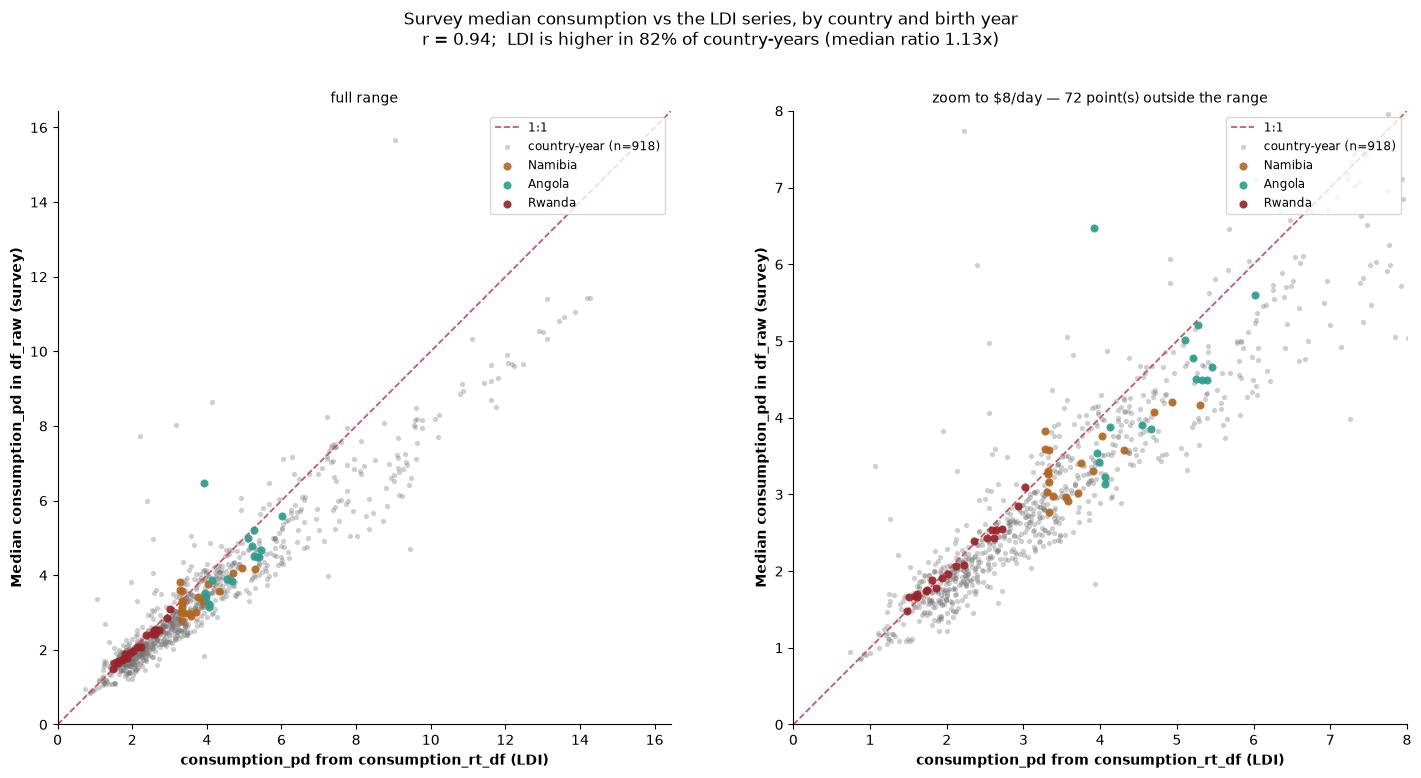

       survey_median  rt_consumption    ratio
count        918.000         918.000  918.000
mean           3.423           3.892    1.135
min            0.853           0.733    0.287
50%            2.845           3.238    1.131
max           15.662          14.281    2.154

LDI / survey ratio for the focus countries:
               years  survey_min  survey_max  rt_min  rt_max  ratio_median
location_name                                                             
Angola            16       3.139       6.468   3.921   6.016         1.164
Namibia           19       2.775       4.201   3.274   5.297         1.138
Rwanda            21       1.477       3.097   1.488   3.019         1.018


In [21]:
# Survey median consumption vs the Resource Tracking (LDI) series #############
# One point per country and birth year present in both sources:
#   y: the median consumption_pd of the individual births in df_raw, i.e. what
#      the model was actually fitted on
#   x: consumption_pd from consumption_rt_df for the same country-year
# The median is recomputed from df_raw here so the cell does not depend on
# df_agg_cy having been built first.
#
# Both axes share one range and a 1:1 line is drawn, so the vertical distance
# from that line is the disagreement between the two sources for that
# country-year. Points above the line mean the survey median is the higher of
# the two.
CMP_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
CMP_ZOOM_MAX = 8.0  # most country-years sit below this, so a zoom earns its place
CMP_COLORS = ["#b5651d", "#2a9d8f", "#9b2226"]
CMP_POINT_COLOR = "0.45"

_cmp_raw = df_raw.groupby(
    ["ihme_loc_id", "location_name", "birth_year"], as_index=False
).agg(
    survey_median=("consumption_pd", "median"),
    n_births=("consumption_pd", "size"),
)
_cmp_rt = consumption_rt_df[["ihme_loc_id", "birth_year", "consumption_pd"]].rename(
    columns={"consumption_pd": "rt_consumption"}
)
_cmp_rt["ihme_loc_id"] = _cmp_rt["ihme_loc_id"].astype(str)

cmp_df = _cmp_raw.merge(_cmp_rt, on=["ihme_loc_id", "birth_year"], how="inner").dropna(
    subset=["survey_median", "rt_consumption"]
)
print(
    f"{len(cmp_df):,} country-years in both sources "
    f"({cmp_df['ihme_loc_id'].nunique()} countries, "
    f"{int(cmp_df['birth_year'].min())}-{int(cmp_df['birth_year'].max())}); "
    f"{len(_cmp_raw) - len(cmp_df):,} of {len(_cmp_raw):,} df_raw country-years "
    f"had no match"
)

cmp_df["ratio"] = cmp_df["rt_consumption"] / cmp_df["survey_median"]

# Square axes on both panels, so the 1:1 line is the diagonal #################
CMP_MAX = (
    float(max(cmp_df["survey_median"].max(), cmp_df["rt_consumption"].max())) * 1.05
)
_r = cmp_df[["rt_consumption", "survey_median"]].corr().iloc[0, 1]

fig, axes = plt.subplots(ncols=2, figsize=(15, 7.6))

for ax, axis_max, tag in (
    (axes[0], CMP_MAX, "full range"),
    (axes[1], CMP_ZOOM_MAX, f"zoom to ${CMP_ZOOM_MAX:.0f}/day"),
):
    ax.plot(
        [0, axis_max],
        [0, axis_max],
        color="#d1495b",
        lw=1.2,
        ls="--",
        zorder=2,
        label="1:1",
    )
    ax.scatter(
        cmp_df["rt_consumption"],
        cmp_df["survey_median"],
        s=14,
        alpha=0.35,
        color=CMP_POINT_COLOR,
        linewidths=0,
        zorder=1,
        label=f"country-year (n={len(cmp_df):,})",
    )
    for country, colour in zip(CMP_COUNTRIES, CMP_COLORS):
        _sub = cmp_df[cmp_df["location_name"] == country]
        ax.scatter(
            _sub["rt_consumption"],
            _sub["survey_median"],
            s=34,
            alpha=0.9,
            color=colour,
            linewidths=0,
            zorder=3,
            label=country,
        )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_aspect("equal")
    ax.set_xlabel("consumption_pd from consumption_rt_df (LDI)", fontweight="bold")
    ax.set_ylabel("Median consumption_pd in df_raw (survey)", fontweight="bold")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    _hidden = int(
        (
            (cmp_df["rt_consumption"] > axis_max) | (cmp_df["survey_median"] > axis_max)
        ).sum()
    )
    ax.set_title(
        tag + (f" — {_hidden} point(s) outside the range" if _hidden else ""),
        fontsize=10,
    )
    ax.legend(loc="upper right", fontsize=8.5)

fig.suptitle(
    f"Survey median consumption vs the LDI series, by country and birth year\n"
    f"r = {_r:.2f};  LDI is higher in "
    f"{100 * (cmp_df['ratio'] > 1).mean():.0f}% of country-years "
    f"(median ratio {cmp_df['ratio'].median():.2f}x)",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))

plot_path = f"{PLOT_OUTPUT}survey_vs_rt_consumption.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# How far apart the two sources are ###########################################
print(
    cmp_df[["survey_median", "rt_consumption", "ratio"]]
    .describe()
    .loc[["count", "mean", "min", "50%", "max"]]
    .round(3)
    .to_string()
)
print("\nLDI / survey ratio for the focus countries:")
print(
    cmp_df[cmp_df["location_name"].isin(CMP_COUNTRIES)]
    .groupby("location_name")
    .agg(
        years=("birth_year", "size"),
        survey_min=("survey_median", "min"),
        survey_max=("survey_median", "max"),
        rt_min=("rt_consumption", "min"),
        rt_max=("rt_consumption", "max"),
        ratio_median=("ratio", "median"),
    )
    .round(3)
    .to_string()
)

Wealth-percentile distributions, overall and split by neonatal death

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/wealth_percentile_histograms.pdf


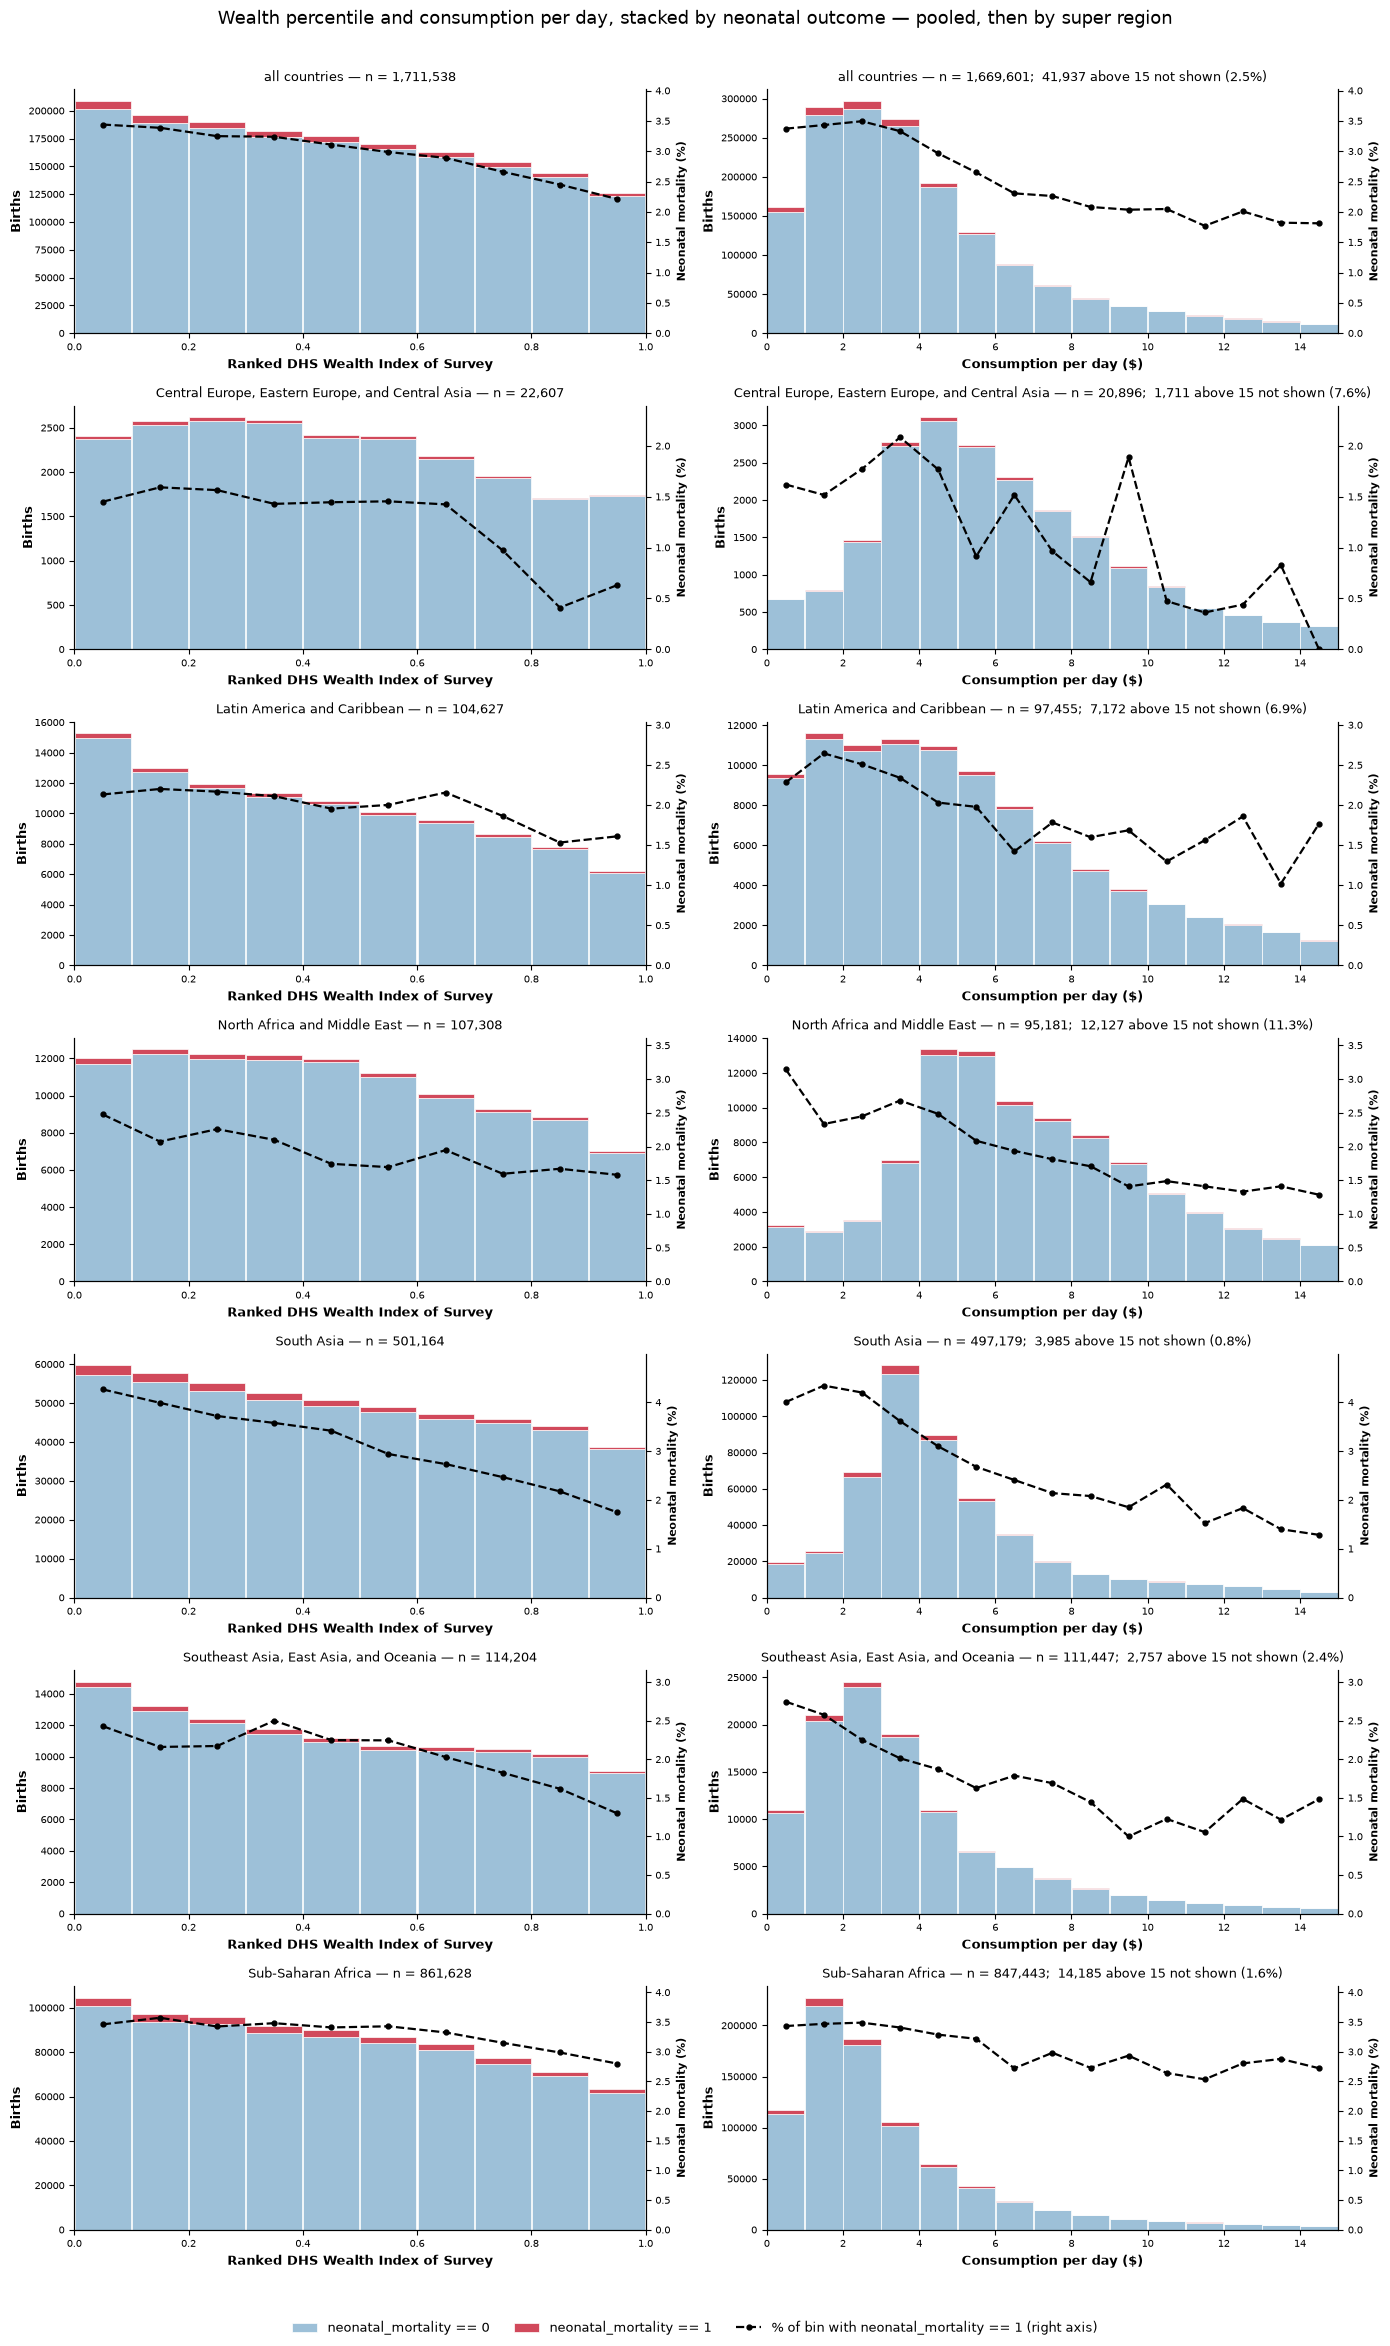


Ranked DHS Wealth Index of Survey: death rate (%) per bin
                                  pooled  Central Europe, Eastern Europe, and Central Asia  Latin America and Caribbean  North Africa and Middle East  South Asia  Southeast Asia, East Asia, and Oceania  Sub-Saharan Africa
unweighted_population_percentile                                                                                                                                                                                             
(-0.001, 0.1]                       3.44                                              1.45                         2.13                          2.48        4.26                                    2.43                3.46
(0.1, 0.2]                          3.39                                              1.59                         2.20                          2.07        3.99                                    2.16                3.57
(0.2, 0.3]                          3.25             

In [ ]:
# Wealth and consumption distributions, stacked by neonatal outcome ###########
# One row per group - every country pooled first, then each super region present
# in the survey data. Across each row:
#   left  : the ranked DHS wealth index of the survey (the unweighted
#           population percentile), in bins 0.1 wide
#   right : consumption_pd in $1/day bins
#
# Both panels stack survivors and deaths as counts, and both carry a dashed
# black line on a right axis: the percentage of that bin's births with
# neonatal_mortality == 1. The right axis is shared between the two panels of a
# row, so a group's wealth gradient and its consumption gradient can be read
# against each other; it is NOT shared down the column, since regional rates
# differ enough that one scale would flatten the low ones.
#
# consumption_pd is long tailed, so its bins stop at the CONS_PCT-th percentile
# of the POOLED births and every row in the right column uses that same set -
# one shared x axis, so the consumption distributions are comparable between
# regions. The tail is not the same size everywhere, so the share of births
# past the last bin varies by region and each panel title reports its own.
# Left count axes stay per panel, since Sub-Saharan Africa has forty times the
# births of Central Europe.
CONS_PCT = 97.5  # upper edge for the consumption bins, from the pooled births

HIST_XVARS = [
    ("unweighted_population_percentile", "Ranked DHS Wealth Index of Survey"),
    ("consumption_pd", "Consumption per day ($)"),
]
HIST_SURV_COLOR = "#9dc0d8"
HIST_DIED_COLOR = "#d1495b"
HIST_RATE_COLOR = "black"
HIST_SURV_LABEL = "neonatal_mortality == 0"
HIST_DIED_LABEL = "neonatal_mortality == 1"
HIST_RATE_LABEL = "% of bin with neonatal_mortality == 1 (right axis)"

HIST_SUPER_REGIONS = sorted(df_raw["super_region_name"].dropna().unique())
HIST_GROUPS = [("all countries", None)] + [(sr, sr) for sr in HIST_SUPER_REGIONS]


# Both bin sets are global: deciles for the percentile, $1 bins to the pooled
# CONS_PCT-th percentile for consumption. Every row shares them.
_CONS_CAP = max(
    np.ceil(float(np.nanpercentile(df_raw["consumption_pd"].dropna(), CONS_PCT))), 5.0
)
HIST_BIN_SETS = {
    "unweighted_population_percentile": np.linspace(0, 1, 11),
    "consumption_pd": np.arange(0, _CONS_CAP + 1, 1.0),
}


def _hist_bins(var, values=None):
    return HIST_BIN_SETS[var]


fig, axes = plt.subplots(
    nrows=len(HIST_GROUPS),
    ncols=len(HIST_XVARS),
    figsize=(7.0 * len(HIST_XVARS), 3.4 * len(HIST_GROUPS)),
)
axes = np.atleast_2d(axes)
handles, labels = [], []

for row, (group_title, region) in enumerate(HIST_GROUPS):
    frame = df_raw if region is None else df_raw[df_raw["super_region_name"] == region]

    # First pass, so the right axis can be shared across the row
    panel_data = []
    for var, var_label in HIST_XVARS:
        bins = _hist_bins(var, frame[var])
        surv, _ = np.histogram(
            frame.loc[frame["neonatal_mortality"] == 0, var].dropna(), bins=bins
        )
        died, _ = np.histogram(
            frame.loc[frame["neonatal_mortality"] == 1, var].dropna(), bins=bins
        )
        total = surv + died
        with np.errstate(invalid="ignore", divide="ignore"):
            rate_pct = np.where(total > 0, 100 * died / total, np.nan)
        panel_data.append((var, var_label, bins, surv, died, total, rate_pct))

    _row_rate_max = max(
        (np.nanmax(d[6]) for d in panel_data if np.isfinite(d[6]).any()), default=1.0
    )

    for col, (var, var_label, bins, surv, died, total, rate_pct) in enumerate(
        panel_data
    ):
        ax = axes[row, col]
        centres = 0.5 * (bins[:-1] + bins[1:])
        width = np.diff(bins) * 0.98

        ax.bar(
            centres,
            surv,
            width=width,
            color=HIST_SURV_COLOR,
            edgecolor="white",
            linewidth=0.5,
            zorder=1,
            label=HIST_SURV_LABEL,
        )
        ax.bar(
            centres,
            died,
            width=width,
            bottom=surv,
            color=HIST_DIED_COLOR,
            edgecolor="white",
            linewidth=0.5,
            zorder=1,
            label=HIST_DIED_LABEL,
        )

        ax2 = ax.twinx()
        ax2.plot(
            centres,
            rate_pct,
            color=HIST_RATE_COLOR,
            lw=1.6,
            ls="--",
            marker="o",
            ms=3.5,
            zorder=4,
            label=HIST_RATE_LABEL,
        )
        ax2.set_ylim(0, _row_rate_max * 1.15)
        ax2.set_ylabel("Neonatal mortality (%)", fontweight="bold", fontsize=8)
        ax2.tick_params(labelsize=7)
        ax2.spines["top"].set_visible(False)

        _outside = int((frame[var].dropna() > bins[-1]).sum())
        _n_var = max(int(frame[var].notna().sum()), 1)
        _note = (
            f";  {_outside:,} above {bins[-1]:g} not shown "
            f"({100 * _outside / _n_var:.1f}%)"
            if _outside
            else ""
        )

        ax.set_xlim(bins[0], bins[-1])
        ax.set_xlabel(var_label, fontweight="bold", fontsize=9)
        ax.set_ylabel("Births", fontweight="bold", fontsize=9)
        ax.set_title(f"{group_title} — n = {total.sum():,}{_note}", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        if not handles:
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            handles, labels = h1 + h2, l1 + l2

fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9, frameon=False)
fig.suptitle(
    "Wealth percentile and consumption per day, stacked by neonatal outcome — "
    "pooled, then by super region",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0.025, 1, 0.975))

plot_path = f"{PLOT_OUTPUT}wealth_percentile_histograms.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Death rate per bin, pooled and per super region #############################
# The dashed lines share a scale only within a row, so the levels are easier to
# compare here. Both bin sets are common to every group.
for var, var_label in HIST_XVARS:
    bins = _hist_bins(var, df_raw[var])
    print(f"\n{'=' * 78}\n{var_label}: death rate (%) per bin\n{'=' * 78}")
    out = {}
    for name, frame in [("pooled", df_raw)] + [
        (sr, df_raw[df_raw["super_region_name"] == sr]) for sr in HIST_SUPER_REGIONS
    ]:
        grouped = frame.groupby(
            pd.cut(frame[var], bins=bins, include_lowest=True), observed=False
        )["neonatal_mortality"]
        out[name] = 100 * grouped.sum() / grouped.size()
    print(pd.DataFrame(out).round(2).to_string())

Same panels for every country with survey data, 9 rows per page → `wealth_percentile_histograms_all_countries.pdf`

In [ ]:
# The same two panels for every country with survey data, as a multi-page PDF #
# One row per country: ranked DHS wealth index on the left, consumption per day
# on the right, survivors and deaths stacked as counts, with the dashed black
# line on a right axis giving the percentage of that bin's births that died.
#
# Bins are the global ones from the previous cell (HIST_BIN_SETS), so every
# country sits on the same x axes and the panels are comparable down the page.
# The right axis is shared between a country's two panels but not between
# countries, and the left count axes are per panel - survey sizes run from
# about 1,500 births to 500,000, so nothing else would be legible.
#
# Nothing is drawn inline; it all goes to one PDF.
HA_NROWS = 9  # countries per page
HA_PDF = f"{PLOT_OUTPUT}wealth_percentile_histograms_all_countries.pdf"

_ha = df_raw.dropna(subset=["location_name", "neonatal_mortality"])
_ha_order = (
    _ha.groupby(["super_region_name", "location_name", "ihme_loc_id"], observed=True)
    .size()
    .reset_index(name="births")
    .sort_values(["super_region_name", "location_name"])
)

_ha_pages = 0
with PdfPages(HA_PDF) as pdf:
    for start in range(0, len(_ha_order), HA_NROWS):
        chunk = _ha_order.iloc[start : start + HA_NROWS]
        fig, axes = plt.subplots(
            nrows=len(chunk),
            ncols=len(HIST_XVARS),
            figsize=(7.0 * len(HIST_XVARS), 2.9 * len(chunk)),
        )
        axes = np.atleast_2d(axes)
        handles, labels = [], []

        for row, (_, meta) in enumerate(chunk.iterrows()):
            frame = _ha[_ha["location_name"] == meta["location_name"]]

            # First pass, so the right axis can be shared across the country
            panel_data = []
            for var, var_label in HIST_XVARS:
                bins = HIST_BIN_SETS[var]
                surv, _ = np.histogram(
                    frame.loc[frame["neonatal_mortality"] == 0, var].dropna(), bins=bins
                )
                died, _ = np.histogram(
                    frame.loc[frame["neonatal_mortality"] == 1, var].dropna(), bins=bins
                )
                total = surv + died
                with np.errstate(invalid="ignore", divide="ignore"):
                    rate_pct = np.where(total > 0, 100 * died / total, np.nan)
                panel_data.append((var, var_label, bins, surv, died, total, rate_pct))

            _row_rate_max = max(
                (np.nanmax(d[6]) for d in panel_data if np.isfinite(d[6]).any()),
                default=1.0,
            )
            if not np.isfinite(_row_rate_max) or _row_rate_max <= 0:
                _row_rate_max = 1.0

            for col, (var, var_label, bins, surv, died, total, rate_pct) in enumerate(
                panel_data
            ):
                ax = axes[row, col]
                centres = 0.5 * (bins[:-1] + bins[1:])
                width = np.diff(bins) * 0.98

                ax.bar(
                    centres,
                    surv,
                    width=width,
                    color=HIST_SURV_COLOR,
                    edgecolor="white",
                    linewidth=0.5,
                    zorder=1,
                    label=HIST_SURV_LABEL,
                )
                ax.bar(
                    centres,
                    died,
                    width=width,
                    bottom=surv,
                    color=HIST_DIED_COLOR,
                    edgecolor="white",
                    linewidth=0.5,
                    zorder=1,
                    label=HIST_DIED_LABEL,
                )

                ax2 = ax.twinx()
                ax2.plot(
                    centres,
                    rate_pct,
                    color=HIST_RATE_COLOR,
                    lw=1.5,
                    ls="--",
                    marker="o",
                    ms=3,
                    zorder=4,
                    label=HIST_RATE_LABEL,
                )
                ax2.set_ylim(0, _row_rate_max * 1.15)
                ax2.set_ylabel("Neonatal mortality (%)", fontweight="bold", fontsize=8)
                ax2.tick_params(labelsize=7)
                ax2.spines["top"].set_visible(False)

                _outside = int((frame[var].dropna() > bins[-1]).sum())
                _n_var = max(int(frame[var].notna().sum()), 1)
                _note = (
                    f";  {_outside:,} above {bins[-1]:g} not shown "
                    f"({100 * _outside / _n_var:.1f}%)"
                    if _outside
                    else ""
                )

                ax.set_xlim(bins[0], bins[-1])
                ax.set_xlabel(var_label, fontweight="bold", fontsize=8.5)
                ax.set_ylabel("Births", fontweight="bold", fontsize=8.5)
                ax.set_title(
                    f"{meta['location_name']} ({meta['ihme_loc_id']}) — "
                    f"n = {total.sum():,}{_note}\n{meta['super_region_name']}",
                    fontsize=8,
                )
                ax.tick_params(labelsize=7)
                ax.set_axisbelow(True)
                ax.spines["top"].set_visible(False)
                if not handles:
                    h1, l1 = ax.get_legend_handles_labels()
                    h2, l2 = ax2.get_legend_handles_labels()
                    handles, labels = h1 + h2, l1 + l2

        fig.legend(
            handles, labels, loc="lower center", ncol=3, fontsize=9, frameon=False
        )
        fig.suptitle(
            "Ranked DHS wealth index and consumption per day, stacked by neonatal "
            f"outcome — page {_ha_pages + 1} of "
            f"{-(-len(_ha_order) // HA_NROWS)}",
            fontsize=12,
        )
        fig.tight_layout(rect=(0, 0.02, 1, 0.98))
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
        _ha_pages += 1

# How much of each country's panel rests on enough deaths to mean anything ####
_ha_deaths = _ha.groupby(
    [
        "location_name",
        pd.cut(
            _ha["unweighted_population_percentile"],
            bins=HIST_BIN_SETS["unweighted_population_percentile"],
            include_lowest=True,
        ),
    ],
    observed=False,
)["neonatal_mortality"].sum()
print(
    f"Saved {HA_PDF}\n"
    f"  {len(_ha_order)} countries, {_ha_pages} pages, {len(_ha):,} births\n"
    f"  survey size per country: median {_ha_order['births'].median():,.0f}, "
    f"min {_ha_order['births'].min():,.0f} "
    f"({_ha_order.loc[_ha_order['births'].idxmin(), 'location_name']}), "
    f"max {_ha_order['births'].max():,.0f} "
    f"({_ha_order.loc[_ha_order['births'].idxmax(), 'location_name']})\n"
    f"  {int((_ha_deaths < 10).sum())} of {len(_ha_deaths)} country-wealth-bins "
    f"rest on fewer than 10 deaths, so those dashed lines are mostly noise"
)

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/wealth_percentile_histograms_all_countries.pdf
  60 countries, 7 pages, 1,711,538 births
  survey size per country: median 19,336, min 1,539 (Republic of Moldova), max 412,973 (India)
  90 of 600 country-wealth-bins rest on fewer than 10 deaths, so those dashed lines are mostly noise


Observed neonatal mortality by wealth percentile, one panel per country with survey data → PDF

In [28]:
# Observed neonatal mortality by wealth percentile, one panel per country #####
# The histogram cell pooled every country together; this splits it out. For
# each country with survey data in df_raw, the births are binned on
# unweighted_population_percentile and the panel shows the OBSERVED death rate
# in each bin - deaths / births, straight from the data, no model.
#
# Grey bars in the background, on the LEFT axis, are the number of births in
# each bin. The dark line on the RIGHT axis is the percentage of those births
# with neonatal_mortality == 1, and the dashed red line is the country's
# overall rate, so the line above it marks bands doing worse than the country
# as a whole.
#
# n on each bar repeats the birth count as a number. Read it knowing that
# births are not the binding constraint - deaths are. A bin can hold 4,000
# births and still rest on 8 deaths, and that rate moves by a third if two
# more children die. The summary underneath reports the deaths behind the
# bins for exactly this reason.
#
# Countries are ordered by super region then name, nine to a page.
OBS_BINS = np.linspace(0, 1, 11)  # 10 bins of 0.1
OBS_VAR = "unweighted_population_percentile"
OBS_NCOLS, OBS_NROWS = 3, 3
OBS_BAR_COLOR = "0.85"  # births, background, left axis
OBS_RATE_COLOR = "#1f4257"  # death rate, right axis
OBS_LINE_COLOR = "#d1495b"  # country overall rate
OBS_PDF = f"{PLOT_OUTPUT}observed_mortality_by_wealth_percentile.pdf"

_obs_centres = 0.5 * (OBS_BINS[:-1] + OBS_BINS[1:])
_obs_width = np.diff(OBS_BINS) * 0.9

_obs = df_raw.dropna(subset=[OBS_VAR, "neonatal_mortality", "location_name"])
_obs_order = (
    _obs.groupby(["super_region_name", "location_name", "ihme_loc_id"], observed=True)
    .size()
    .reset_index(name="births")
    .sort_values(["super_region_name", "location_name"])
)

_obs_pages = 0
with PdfPages(OBS_PDF) as pdf:
    for start in range(0, len(_obs_order), OBS_NROWS * OBS_NCOLS):
        chunk = _obs_order.iloc[start : start + OBS_NROWS * OBS_NCOLS]
        used_rows = -(-len(chunk) // OBS_NCOLS)
        fig, axes = plt.subplots(
            nrows=used_rows, ncols=OBS_NCOLS, figsize=(16.5, 4.4 * used_rows)
        )
        axes = np.atleast_2d(axes).ravel()

        for _panel, (ax, (_, row)) in enumerate(zip(axes, chunk.iterrows())):
            sub = _obs[_obs["location_name"] == row["location_name"]]
            grouped = sub.groupby(
                pd.cut(sub[OBS_VAR], bins=OBS_BINS, include_lowest=True),
                observed=False,
            )["neonatal_mortality"]
            births = grouped.size().to_numpy()
            deaths = grouped.sum().to_numpy()
            with np.errstate(invalid="ignore", divide="ignore"):
                rate = np.where(births > 0, 100 * deaths / births, np.nan)

            # Births as background bars on the left axis
            ax.bar(
                _obs_centres,
                births,
                width=_obs_width,
                color=OBS_BAR_COLOR,
                edgecolor="white",
                linewidth=0.5,
                zorder=1,
            )
            _bar_top = births.max() if births.max() > 0 else 1
            ax.set_ylim(0, _bar_top * 1.35)
            for x, n in zip(_obs_centres, births):
                if n == 0:
                    continue
                ax.text(
                    x,
                    0.02 * _bar_top,
                    f"n={n:,}",
                    ha="center",
                    va="bottom",
                    fontsize=5.5,
                    rotation=90,
                    color="0.40",
                    zorder=2,
                )

            # Death rate as a line on the right axis
            ax2 = ax.twinx()
            overall = 100 * sub["neonatal_mortality"].mean()
            ax2.plot(
                _obs_centres,
                rate,
                color=OBS_RATE_COLOR,
                lw=1.6,
                marker="o",
                ms=3.5,
                zorder=4,
                label="neonatal_mortality == 1 (%)",
            )
            ax2.axhline(
                overall,
                color=OBS_LINE_COLOR,
                lw=1.1,
                ls="--",
                zorder=3,
                label=f"country overall {overall:.2f}%",
            )
            _rate_top = np.nanmax(rate) if np.isfinite(rate).any() else 1.0
            ax2.set_ylim(0, max(_rate_top, overall) * 1.30)
            ax2.tick_params(labelsize=7)
            ax2.spines["top"].set_visible(False)
            # supylabel only labels the left side, so the right-hand column
            # carries the label for the rate axis
            if _panel % OBS_NCOLS == OBS_NCOLS - 1:
                ax2.set_ylabel("Neonatal mortality (%)", fontweight="bold", fontsize=8)
            ax2.legend(loc="upper left", fontsize=6, frameon=False)

            ax.set_xlim(0, 1)
            ax.set_xticks(OBS_BINS[::2])  # every other edge, or they collide
            ax.tick_params(labelsize=7)
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.set_title(
                f"{row['location_name']} ({row['ihme_loc_id']}) — "
                f"{row['births']:,} births\n{row['super_region_name']}",
                fontsize=8.5,
            )

        for ax in axes[len(chunk) :]:
            ax.set_visible(False)

        fig.supxlabel(
            "Unweighted population percentile", fontweight="bold", fontsize=10
        )
        fig.supylabel("Births in bin", fontweight="bold", fontsize=10)
        fig.suptitle(
            "Observed neonatal mortality by wealth percentile, "
            f"page {_obs_pages + 1} of "
            f"{-(-len(_obs_order) // (OBS_NROWS * OBS_NCOLS))}\n"
            "grey bars: births in that bin (left axis);  dark line: % of those "
            "births with neonatal_mortality == 1 (right axis);  dashed red: "
            "country overall rate",
            fontsize=10,
        )
        fig.tight_layout(rect=(0.015, 0.02, 1, 0.93))
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
        _obs_pages += 1

# How reliable these bin rates are. Births are not the binding constraint -
# deaths are. A bin with 4,000 births but 8 deaths still has a rate that moves
# by a third if two more children die, so the deaths count is what to judge by.
_bin_stats = _obs.groupby(
    ["location_name", pd.cut(_obs[OBS_VAR], bins=OBS_BINS, include_lowest=True)],
    observed=False,
)["neonatal_mortality"].agg(births="size", deaths="sum")
print(
    f"Saved {OBS_PDF}\n"
    f"  {len(_obs_order)} countries with survey data, {_obs_pages} pages, "
    f"{len(_obs):,} births\n"
    f"  births per country-bin: median {_bin_stats['births'].median():,.0f}, "
    f"min {_bin_stats['births'].min():,.0f}\n"
    f"  deaths per country-bin: median {_bin_stats['deaths'].median():,.0f}, "
    f"min {_bin_stats['deaths'].min():,.0f}; "
    f"{int((_bin_stats['deaths'] < 10).sum())} of {len(_bin_stats)} bins "
    f"({100 * (_bin_stats['deaths'] < 10).mean():.0f}%) rest on fewer than 10 "
    f"deaths, so their rates are mostly sampling noise"
)

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/observed_mortality_by_wealth_percentile.pdf
  60 countries with survey data, 7 pages, 1,711,538 births
  births per country-bin: median 1,864, min 127
  deaths per country-bin: median 50, min 0; 90 of 600 bins (15%) rest on fewer than 10 deaths, so their rates are mostly sampling noise


Country × wealth-percentile bin table, with observed mortality and its rank within each country

In [ ]:
# Country x wealth-percentile bin table, with a mortality rank ################
# One row per country and unweighted_population_percentile bin - the same bins
# the per-country PDF draws - carrying the observed rate and how that rate
# ranks against the country's other bins.
#
# rank_within_country is the rank of that bin's mortality among the SAME
# country's bins, rescaled so the country's lowest-mortality bin is 0.0 and its
# highest is 1.0. It is therefore a within-country statement: it says where in
# its own wealth distribution a country's worst mortality sits, and says
# nothing about whether that country is high or low mortality overall.
#
# rank_overall does the same across all country-bins at once, so it mixes the
# between-country differences back in. Ties take the average rank, and bins
# with no births get NaN rather than a rank.
BR_BINS = OBS_BINS  # the bins the per-country PDF uses
BR_VAR = OBS_VAR

_br = df_raw.dropna(subset=[BR_VAR, "neonatal_mortality", "location_name"])
_br_binned = pd.cut(_br[BR_VAR], bins=BR_BINS, include_lowest=True)

df_bin_rank = (
    _br.groupby(
        ["super_region_name", "location_name", "ihme_loc_id", _br_binned],
        observed=False,
    )["neonatal_mortality"]
    .agg(births="size", deaths="sum")
    .reset_index()
    .rename(columns={BR_VAR: "percentile_bin"})
)
df_bin_rank = df_bin_rank[df_bin_rank["births"] > 0].copy()

df_bin_rank["bin_left"] = (
    df_bin_rank["percentile_bin"].apply(lambda b: b.left).astype(float)
)
df_bin_rank["bin_right"] = (
    df_bin_rank["percentile_bin"].apply(lambda b: b.right).astype(float)
)
# include_lowest pushes the first interval's left edge below 0; report the
# nominal edge instead, since this is a table people will read
df_bin_rank["bin_left"] = df_bin_rank["bin_left"].clip(lower=float(BR_BINS[0]))
df_bin_rank["neonatal_mortality"] = df_bin_rank["deaths"] / df_bin_rank["births"]
df_bin_rank["mortality_pct"] = 100 * df_bin_rank["neonatal_mortality"]


def _scaled_rank(s):
    """0.0 on the lowest value, 1.0 on the highest; NaN if there is only one."""
    if len(s) < 2:
        return pd.Series(np.nan, index=s.index)
    return (s.rank(method="average") - 1) / (len(s) - 1)


df_bin_rank["rank_within_country"] = df_bin_rank.groupby("location_name")[
    "neonatal_mortality"
].transform(_scaled_rank)
df_bin_rank["rank_overall"] = _scaled_rank(df_bin_rank["neonatal_mortality"])

# The country's own overall rate, so each bin can be read against its country
df_bin_rank["country_mortality"] = df_bin_rank.groupby("location_name")[
    "deaths"
].transform("sum") / df_bin_rank.groupby("location_name")["births"].transform("sum")
df_bin_rank["ratio_to_country"] = (
    df_bin_rank["neonatal_mortality"] / df_bin_rank["country_mortality"]
)

df_bin_rank = (
    df_bin_rank[
        [
            "super_region_name",
            "location_name",
            "ihme_loc_id",
            "percentile_bin",
            "bin_left",
            "bin_right",
            "births",
            "deaths",
            "neonatal_mortality",
            "mortality_pct",
            "country_mortality",
            "ratio_to_country",
            "rank_within_country",
            "rank_overall",
        ]
    ]
    .sort_values(["super_region_name", "location_name", "bin_left"])
    .reset_index(drop=True)
)

print(
    f"{len(df_bin_rank):,} country-bins, "
    f"{df_bin_rank['location_name'].nunique()} countries, "
    f"{len(BR_BINS) - 1} bins of "
    f"{(BR_BINS[1] - BR_BINS[0]):.2f} on {BR_VAR}"
)
print(df_bin_rank.head(12).round(4).to_string(index=False))

# Where each country's worst and best bins sit in the wealth distribution #####
# If poverty drove mortality within a country, the 1.0 bins would cluster at
# the bottom of the percentile range and the 0.0 bins at the top.
_worst = df_bin_rank.loc[
    df_bin_rank.groupby("location_name")["rank_within_country"].idxmax()
]
_best = df_bin_rank.loc[
    df_bin_rank.groupby("location_name")["rank_within_country"].idxmin()
]
print(
    f"\nhighest-mortality bin sits in the bottom half of the percentile range "
    f"for {int((_worst['bin_left'] < 0.5).sum())} of {len(_worst)} countries; "
    f"lowest-mortality bin does for {int((_best['bin_left'] < 0.5).sum())} of "
    f"{len(_best)}"
)
print(
    "\nmean rank_within_country by bin (a downward trend would mean mortality "
    "falls with wealth inside countries):"
)
print(
    df_bin_rank.groupby(["bin_left", "bin_right"])
    .agg(
        countries=("location_name", "nunique"),
        mean_rank=("rank_within_country", "mean"),
        mean_ratio_to_country=("ratio_to_country", "mean"),
        births=("births", "sum"),
    )
    .round(3)
    .to_string()
)

600 country-bins, 60 countries, 10 bins of 0.10 on unweighted_population_percentile
                               super_region_name location_name ihme_loc_id percentile_bin  bin_left  bin_right  births  deaths  neonatal_mortality  mortality_pct  country_mortality  ratio_to_country  rank_within_country  rank_overall
Central Europe, Eastern Europe, and Central Asia       Albania         ALB  (-0.001, 0.1]       0.0        0.1     564       4              0.0071         0.7092             0.0049            1.4586               0.6667        0.0359
Central Europe, Eastern Europe, and Central Asia       Albania         ALB     (0.1, 0.2]       0.1        0.2     542       1              0.0018         0.1845             0.0049            0.3795               0.2222        0.0150
Central Europe, Eastern Europe, and Central Asia       Albania         ALB     (0.2, 0.3]       0.2        0.3     510       2              0.0039         0.3922             0.0049            0.8065               0

Mortality rank against wealth percentile, one point per country-bin

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/mortality_rank_vs_percentile.pdf


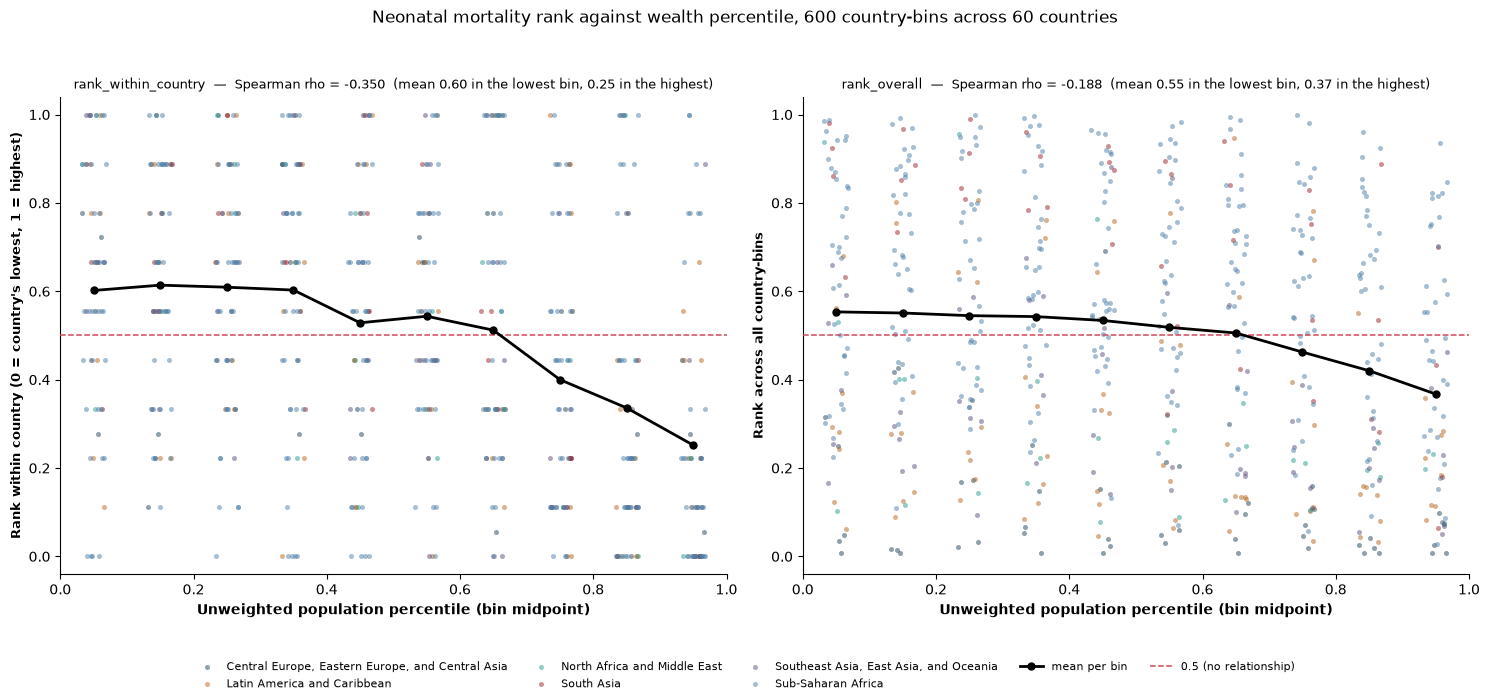

                    country_bins  mean_rank_within  mean_rank_overall  share_top_third  share_bottom_third
bin_left bin_right                                                                                        
0.0      0.1                  60             0.602              0.553            0.533               0.250
0.1      0.2                  60             0.614              0.551            0.500               0.250
0.2      0.3                  60             0.609              0.545            0.550               0.233
0.3      0.4                  60             0.603              0.543            0.567               0.267
0.4      0.5                  60             0.529              0.534            0.433               0.333
0.5      0.6                  60             0.544              0.518            0.417               0.283
0.6      0.7                  60             0.512              0.506            0.383               0.500
0.7      0.8                  60     

In [ ]:
# Mortality rank against wealth percentile, one point per country-bin #########
# x is the bin's midpoint on unweighted_population_percentile, y is the rank
# from df_bin_rank. Ten bins means ten x positions and 60 points stacked on
# each, so a small horizontal jitter is added to separate them - the jitter is
# cosmetic and never moves a point out of its own bin.
#
# Left panel is rank_within_country: each country's own bins ranked 0 to 1, so
# every country contributes exactly one 0.0 and one 1.0 and the between-country
# differences are divided out. Right panel is rank_overall, ranked across all
# 600 country-bins at once, which puts those differences back in.
#
# The black line is the mean rank per bin and the dashed line marks 0.5, the
# level a bin would average if wealth carried no information.
RS_JITTER = 0.018
# Same super-region palette used elsewhere, spelled out so this cell only
# needs df_bin_rank and not the inference cells that define VG_COLORS
RS_COLORS = [
    "#1f4257",
    "#b5651d",
    "#2a9d8f",
    "#9b2226",
    "#5c4d7d",
    "#4d7ea8",
    "#7a7a52",
]
RS_MEAN_COLOR = "black"
RS_REF_COLOR = "#d1495b"

rs = df_bin_rank.dropna(subset=["rank_within_country", "rank_overall"]).copy()
rs["bin_mid"] = 0.5 * (rs["bin_left"] + rs["bin_right"])
_rng = np.random.default_rng(0)
rs["x_jitter"] = rs["bin_mid"] + _rng.uniform(-RS_JITTER, RS_JITTER, len(rs))
_rs_regions = sorted(rs["super_region_name"].unique())

fig, axes = plt.subplots(ncols=2, figsize=(15, 7))
panels = [
    ("rank_within_country", "Rank within country (0 = country's lowest, 1 = highest)"),
    ("rank_overall", "Rank across all country-bins"),
]

for ax, (y_col, y_label) in zip(axes, panels):
    for region, colour in zip(_rs_regions, RS_COLORS):
        sub = rs[rs["super_region_name"] == region]
        ax.scatter(
            sub["x_jitter"],
            sub[y_col],
            s=13,
            alpha=0.5,
            color=colour,
            linewidths=0,
            zorder=2,
            label=region,
        )

    means = rs.groupby("bin_mid")[y_col].mean()
    ax.plot(
        means.index,
        means.to_numpy(),
        color=RS_MEAN_COLOR,
        lw=2.0,
        marker="o",
        ms=5,
        zorder=4,
        label="mean per bin",
    )
    ax.axhline(
        0.5,
        color=RS_REF_COLOR,
        lw=1.1,
        ls="--",
        zorder=3,
        label="0.5 (no relationship)",
    )

    _rho = rs[["bin_mid", y_col]].corr(method="spearman").iloc[0, 1]
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.04, 1.04)
    ax.set_xticks(BR_BINS[::2])
    ax.set_xlabel("Unweighted population percentile (bin midpoint)", fontweight="bold")
    ax.set_ylabel(y_label, fontweight="bold", fontsize=9)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(
        f"{y_col}  —  Spearman rho = {_rho:+.3f}  "
        f"(mean {means.iloc[0]:.2f} in the lowest bin, {means.iloc[-1]:.2f} in "
        f"the highest)",
        fontsize=9.5,
    )

_rs_handles, _rs_labels = axes[0].get_legend_handles_labels()
fig.legend(
    _rs_handles, _rs_labels, loc="lower center", ncol=5, fontsize=8, frameon=False
)
fig.suptitle(
    "Neonatal mortality rank against wealth percentile, "
    f"{len(rs):,} country-bins across {rs['location_name'].nunique()} countries",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0.09, 1, 0.95))

plot_path = f"{PLOT_OUTPUT}mortality_rank_vs_percentile.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print(
    rs.groupby(["bin_left", "bin_right"])
    .agg(
        country_bins=("rank_within_country", "size"),
        mean_rank_within=("rank_within_country", "mean"),
        mean_rank_overall=("rank_overall", "mean"),
        share_top_third=("rank_within_country", lambda r: float((r >= 2 / 3).mean())),
        share_bottom_third=(
            "rank_within_country",
            lambda r: float((r <= 1 / 3).mean()),
        ),
    )
    .round(3)
    .to_string()
)

Country × birth year × wealth quintile aggregate: mean consumption_pd, SDI and neonatal mortality

In [10]:
# Country x birth year x wealth quintile aggregate ############################
# One row per country, birth year, and quintile of
# unweighted_population_percentile. The percentile itself is a continuous rank,
# so it has to be binned before it can be grouped on; raw values would give
# roughly one row per birth.
#
# Quintiles rather than the 0.1-wide bins the histograms and df_bin_rank use:
# splitting a country-year ten ways left a median of 3 deaths per cell, and
# halving the number of bins doubles the births behind each one.
#
# Every column is a plain mean over the births in the cell. neonatal_mortality
# is a 0/1 indicator, so its mean is the observed death rate for that cell.
# n_births is carried along because these cells are still thin: a
# country-year-quintile is a much smaller group than the country-year cells in
# df_agg_cy.
CYP_BINS = np.linspace(0, 1, 6)  # 5 bins of 0.2
CYP_VAR = "unweighted_population_percentile"

df_agg_cyp = (
    df_raw.groupby(
        [
            "ihme_loc_id",
            "location_name",
            "birth_year",
            pd.cut(df_raw[CYP_VAR], bins=CYP_BINS, include_lowest=True),
        ],
        observed=True,
    )
    .agg(
        consumption_pd=("consumption_pd", "mean"),
        sdi=("sdi", "mean"),
        neonatal_mortality=("neonatal_mortality", "mean"),
        n_births=("neonatal_mortality", "size"),
        deaths=("neonatal_mortality", "sum"),
    )
    .reset_index()
    .rename(columns={CYP_VAR: "percentile_bin"})
)

# include_lowest pushes the first interval's left edge below 0; report the
# nominal edge instead
df_agg_cyp["bin_left"] = (
    df_agg_cyp["percentile_bin"]
    .apply(lambda b: b.left)
    .astype(float)
    .clip(lower=float(CYP_BINS[0]))
)
df_agg_cyp["bin_right"] = (
    df_agg_cyp["percentile_bin"].apply(lambda b: b.right).astype(float)
)
df_agg_cyp = (
    df_agg_cyp[
        [
            "ihme_loc_id",
            "location_name",
            "birth_year",
            "percentile_bin",
            "bin_left",
            "bin_right",
            "consumption_pd",
            "sdi",
            "neonatal_mortality",
            "n_births",
            "deaths",
        ]
    ]
    .sort_values(["location_name", "birth_year", "bin_left"])
    .reset_index(drop=True)
)

print(
    f"{len(df_agg_cyp):,} rows: "
    f"{df_agg_cyp['ihme_loc_id'].nunique()} countries x "
    f"birth_year {int(df_agg_cyp['birth_year'].min())}-"
    f"{int(df_agg_cyp['birth_year'].max())} x {len(CYP_BINS) - 1} quintiles"
)
print(
    f"  births per cell: median {df_agg_cyp['n_births'].median():,.0f}, "
    f"min {df_agg_cyp['n_births'].min():,.0f}, "
    f"max {df_agg_cyp['n_births'].max():,.0f}\n"
    f"  deaths per cell: median {df_agg_cyp['deaths'].median():,.0f}; "
    f"{int((df_agg_cyp['deaths'] == 0).sum()):,} cells "
    f"({100 * (df_agg_cyp['deaths'] == 0).mean():.0f}%) have no deaths at all, "
    f"so their rate is exactly 0"
)
_miss = df_agg_cyp[["consumption_pd", "sdi", "neonatal_mortality"]].isna().sum()
if _miss.any():
    print(f"  missing means: {_miss[_miss > 0].to_dict()}")
df_agg_cyp.head(12).round(4)

4,562 rows: 60 countries x birth_year 1985-2023 x 5 quintiles
  births per cell: median 248, min 1, max 12,675
  deaths per cell: median 7; 448 cells (10%) have no deaths at all, so their rate is exactly 0


,ihme_loc_id,location_name,birth_year,percentile_bin,bin_left,bin_right,consumption_pd,sdi,neonatal_mortality,n_births,deaths
0,ALB,Albania,2003,"(-0.001, 0.2]",0.0,0.2,3.0877,0.5958,0.0000,4,0
1,ALB,Albania,2003,"(0.4, 0.6]",0.4,0.6,8.8727,0.5958,0.0000,1,0
2,ALB,Albania,2004,"(-0.001, 0.2]",0.0,0.2,3.0198,0.6032,0.0000,91,0
3,ALB,Albania,2004,"(0.2, 0.4]",0.2,0.4,5.8265,0.6032,0.0125,80,1
4,ALB,Albania,2004,"(0.4, 0.6]",0.4,0.6,7.8719,0.6032,0.0152,66,1
5,ALB,Albania,2004,"(0.6, 0.8]",0.6,0.8,10.5859,0.6032,0.0000,50,0
6,ALB,Albania,2004,"(0.8, 1.0]",0.8,1.0,17.4507,0.6032,0.0000,49,0
7,ALB,Albania,2005,"(-0.001, 0.2]",0.0,0.2,3.2485,0.6103,0.0312,96,3
8,ALB,Albania,2005,"(0.2, 0.4]",0.2,0.4,5.7368,0.6103,0.0225,89,2
9,ALB,Albania,2005,"(0.4, 0.6]",0.4,0.6,8.1005,0.6103,0.0000,62,0


Neonatal mortality over time by wealth quintile, pooled and by super region

4,161 country-year-quintile cells in 1995-2019, 60 countries, 6 super regions
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/cyp_mortality_by_decile_over_time.pdf


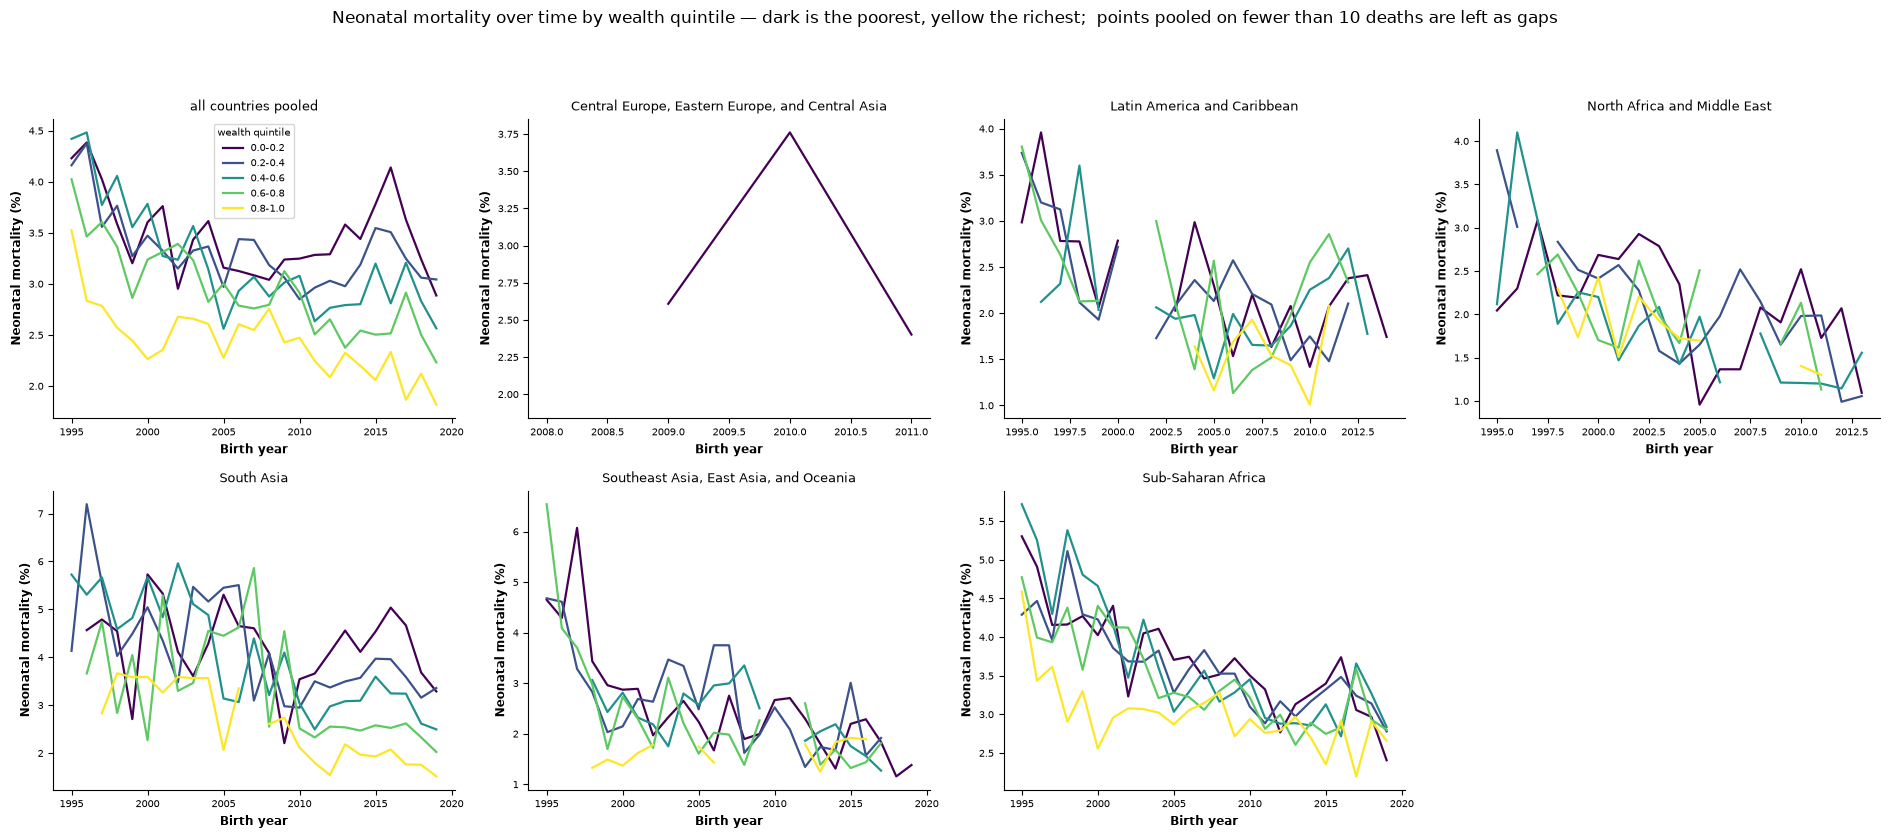


pooled poorest vs richest quintile, 25 years (1995-2019):
bin_left    poorest_quintile  richest_quintile  ratio
birth_year                                           
1995                    4.23              3.53   1.20
1996                    4.38              2.83   1.55
1997                    4.02              2.79   1.44
1998                    3.59              2.57   1.39
1999                    3.20              2.44   1.31
2000                    3.60              2.26   1.59
2001                    3.76              2.35   1.60
2002                    2.95              2.68   1.10
2003                    3.43              2.66   1.29
2004                    3.62              2.61   1.39
2005                    3.16              2.28   1.39
2006                    3.13              2.61   1.20
2007                    3.08              2.55   1.21
2008                    3.04              2.76   1.10
2009                    3.24              2.43   1.33
2010                   

In [11]:
# Neonatal mortality over time by wealth quintile #############################
# One panel per group - every country pooled first, then each super region -
# with one line per bin of unweighted_population_percentile, as df_agg_cyp
# defines them. Dark is the poorest bin, yellow the richest. The bin edges are
# read off the frame rather than assumed, so this follows CYP_BINS if it
# changes.
#
# df_agg_cyp's cells are thin (median 124 births, 3 deaths), so nothing here
# plots a cell rate directly. Each point is recomputed as sum(deaths) /
# sum(births) over every country contributing to that group, decile and year,
# and a point is dropped where that pool still has fewer than VZ_MIN_DEATHS
# deaths. Those gaps are why the sparser regions come out as fragments: the
# line stops rather than drawing a rate built on two or three deaths.
VZ_YEARS = (1995, 2019)  # the window the other trajectory plots use
VZ_MIN_DEATHS = 10  # below this a pooled rate is mostly sampling noise

vz = df_agg_cyp[df_agg_cyp["birth_year"].between(*VZ_YEARS)].copy()
vz = vz.merge(
    locs[["ihme_loc_id", "super_region_name"]].drop_duplicates("ihme_loc_id"),
    on="ihme_loc_id",
    how="left",
)
_vz_regions = sorted(vz["super_region_name"].dropna().unique())
# (bin_left, bin_right) pairs, in order, straight from the frame
_bins = (
    vz[["bin_left", "bin_right"]]
    .drop_duplicates()
    .sort_values("bin_left")
    .itertuples(index=False, name=None)
)
_bins = list(_bins)
_dec_cmap = plt.get_cmap("viridis")
print(
    f"{len(vz):,} country-year-quintile cells in {VZ_YEARS[0]}-{VZ_YEARS[1]}, "
    f"{vz['ihme_loc_id'].nunique()} countries, {len(_vz_regions)} super regions"
)

_groups = [("all countries pooled", vz)] + [
    (r, vz[vz["super_region_name"] == r]) for r in _vz_regions
]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(19, 8.5))
axes = np.atleast_2d(axes).ravel()

_kept = 0
for ax, (title, block) in zip(axes, _groups):
    for i, (left, right) in enumerate(_bins):
        agg = (
            block[block["bin_left"] == left]
            .groupby("birth_year")[["deaths", "n_births"]]
            .sum()
        )
        rate = (100 * agg["deaths"] / agg["n_births"]).where(
            agg["deaths"] >= VZ_MIN_DEATHS
        )
        _kept += int(rate.notna().sum())
        ax.plot(
            rate.index,
            rate.to_numpy(),
            lw=1.6,
            color=_dec_cmap(i / max(len(_bins) - 1, 1)),
            label=f"{left:.1f}-{right:.1f}" if ax is axes[0] else None,
        )
    ax.set_xlabel("Birth year", fontweight="bold", fontsize=8.5)
    ax.set_ylabel("Neonatal mortality (%)", fontweight="bold", fontsize=8.5)
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

for ax in axes[len(_groups) :]:
    ax.set_visible(False)
axes[0].legend(title="wealth quintile", fontsize=7, title_fontsize=7.5)

fig.suptitle(
    "Neonatal mortality over time by wealth quintile — dark is the poorest, "
    f"yellow the richest;  points pooled on fewer than {VZ_MIN_DEATHS} deaths "
    "are left as gaps",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))

plot_path = f"{PLOT_OUTPUT}cyp_mortality_by_decile_over_time.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# How the gap between the poorest and richest quintiles moves #################
_lo, _hi = _bins[0][0], _bins[-1][0]
_ends = (
    vz[vz["bin_left"].isin([_lo, _hi])]
    .groupby(["bin_left", "birth_year"])[["deaths", "n_births"]]
    .sum()
)
_ends["rate_pct"] = 100 * _ends["deaths"] / _ends["n_births"]
_gap = (
    _ends["rate_pct"]
    .unstack("bin_left")
    .rename(columns={_lo: "poorest_quintile", _hi: "richest_quintile"})
    .dropna()
)
_gap["ratio"] = _gap["poorest_quintile"] / _gap["richest_quintile"]
print(
    f"\npooled poorest vs richest quintile, {len(_gap)} years "
    f"({int(_gap.index.min())}-{int(_gap.index.max())}):"
)
print(_gap.round(2).to_string())

Neonatal mortality heatmaps: wealth quintile × consumption, wealth quintile × birth year, consumption × birth year

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/cyp_mortality_heatmaps.pdf


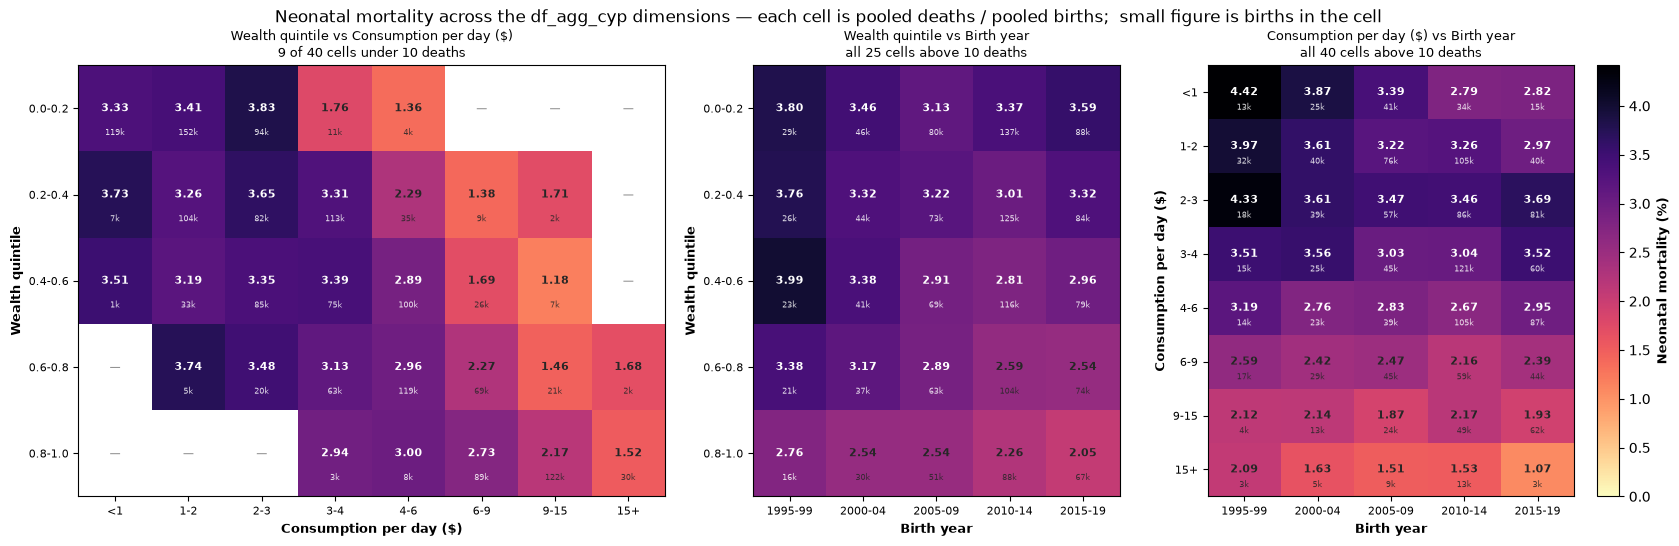


Wealth quintile vs Consumption per day ($) — neonatal mortality (%):
cons_bin      <1   1-2   2-3   3-4   4-6   6-9  9-15   15+
wealth_bin                                                
0.0-0.2     3.33  3.41  3.83  1.76  1.36   NaN   NaN   NaN
0.2-0.4     3.73  3.26  3.65  3.31  2.29  1.38  1.71   NaN
0.4-0.6     3.51  3.19  3.35  3.39  2.89  1.69  1.18   NaN
0.6-0.8      NaN  3.74  3.48  3.13  2.96  2.27  1.46  1.68
0.8-1.0      NaN   NaN   NaN  2.94  3.00  2.73  2.17  1.52

Wealth quintile vs Birth year — neonatal mortality (%):
year_bin    1995-99  2000-04  2005-09  2010-14  2015-19
wealth_bin                                             
0.0-0.2        3.80     3.46     3.13     3.37     3.59
0.2-0.4        3.76     3.32     3.22     3.01     3.32
0.4-0.6        3.99     3.38     2.91     2.81     2.96
0.6-0.8        3.38     3.17     2.89     2.59     2.54
0.8-1.0        2.76     2.54     2.54     2.26     2.05

Consumption per day ($) vs Birth year — neonatal mortality (%):
yea

In [12]:
# Neonatal mortality across pairs of the three df_agg_cyp dimensions ##########
# Three heatmaps, each collapsing the dimension it does not show:
#   1. wealth quintile x binned consumption_pd
#   2. wealth quintile x binned birth_year
#   3. binned consumption_pd x binned birth_year
#
# Every cell is sum(deaths) / sum(births) over all the country-year-quintile
# cells that land in it, never a mean of cell rates - the underlying cells
# differ in size by four orders of magnitude, so averaging their rates would
# weight a 1-birth cell like a 12,000-birth one.
#
# Consumption is binned on the CELL MEAN, not on individual births, so a cell
# sits in the band its quintile's average lands in. The top band is open ended
# so nothing is dropped; the bands are uneven because the distribution is
# skewed (median $3.31, 95th percentile $11).
#
# Cells resting on fewer than HM_MIN_DEATHS deaths are left blank rather than
# drawn, and the annotation gives the rate over the births behind it.
HM_YEARS = (1995, 2019)
HM_MIN_DEATHS = 10
HM_CONS_EDGES = [0, 1, 2, 3, 4, 6, 9, 15, np.inf]
HM_CONS_LABELS = ["<1", "1-2", "2-3", "3-4", "4-6", "6-9", "9-15", "15+"]
HM_YEAR_EDGES = [1995, 2000, 2005, 2010, 2015, 2020]
HM_YEAR_LABELS = ["1995-99", "2000-04", "2005-09", "2010-14", "2015-19"]

hm = df_agg_cyp[df_agg_cyp["birth_year"].between(*HM_YEARS)].copy()
hm["cons_bin"] = pd.cut(
    hm["consumption_pd"], bins=HM_CONS_EDGES, labels=HM_CONS_LABELS, right=False
)
hm["year_bin"] = pd.cut(
    hm["birth_year"], bins=HM_YEAR_EDGES, labels=HM_YEAR_LABELS, right=False
)
hm["wealth_bin"] = hm["bin_left"].map(
    {b: f"{b:.1f}-{b + 0.2:.1f}" for b in sorted(hm["bin_left"].unique())}
)
HM_WEALTH_LABELS = [f"{b:.1f}-{b + 0.2:.1f}" for b in sorted(hm["bin_left"].unique())]


def _hm_grid(row_col, row_labels, col_col, col_labels):
    """Pooled rate (%) and births for every row x column combination."""
    g = hm.groupby([row_col, col_col], observed=False)[["deaths", "n_births"]].sum()
    rate = (100 * g["deaths"] / g["n_births"]).where(g["deaths"] >= HM_MIN_DEATHS)
    rate = rate.unstack(col_col).reindex(index=row_labels, columns=col_labels)
    births = (
        g["n_births"].unstack(col_col).reindex(index=row_labels, columns=col_labels)
    )
    return rate, births


_panels = [
    (
        "wealth_bin",
        HM_WEALTH_LABELS,
        "cons_bin",
        HM_CONS_LABELS,
        "Wealth quintile",
        "Consumption per day ($)",
    ),
    (
        "wealth_bin",
        HM_WEALTH_LABELS,
        "year_bin",
        HM_YEAR_LABELS,
        "Wealth quintile",
        "Birth year",
    ),
    (
        "cons_bin",
        HM_CONS_LABELS,
        "year_bin",
        HM_YEAR_LABELS,
        "Consumption per day ($)",
        "Birth year",
    ),
]
_grids = [_hm_grid(r, rl, c, cl) for r, rl, c, cl, _, _ in _panels]
_vmax = max(float(np.nanmax(rate.to_numpy())) for rate, _ in _grids)

fig, axes = plt.subplots(
    ncols=3,
    figsize=(20, 5.6),
    gridspec_kw={
        "width_ratios": [len(HM_CONS_LABELS), len(HM_YEAR_LABELS), len(HM_YEAR_LABELS)]
    },
)

for ax, (rate, births), (_, row_labels, _, col_labels, y_label, x_label) in zip(
    axes, _grids, _panels
):
    im = ax.imshow(
        rate.to_numpy(),
        cmap="magma_r",
        vmin=0,
        vmax=_vmax,
        aspect="auto",
        origin="upper",
    )
    ax.set_xticks(range(len(col_labels)), col_labels, fontsize=8)
    ax.set_yticks(range(len(row_labels)), row_labels, fontsize=8)
    ax.set_xlabel(x_label, fontweight="bold", fontsize=9.5)
    ax.set_ylabel(y_label, fontweight="bold", fontsize=9.5)

    for i in range(rate.shape[0]):
        for j in range(rate.shape[1]):
            v, n = rate.to_numpy()[i, j], births.to_numpy()[i, j]
            if not np.isfinite(v):
                ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="0.55")
                continue
            # dark cells need light text
            colour = "white" if v > 0.6 * _vmax else "0.15"
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=colour,
                fontweight="bold",
            )
            ax.text(
                j,
                i + 0.28,
                f"{n / 1000:,.0f}k",
                ha="center",
                va="center",
                fontsize=6,
                color=colour,
                alpha=0.85,
            )

    _n_blank = int((~np.isfinite(rate.to_numpy())).sum())
    ax.set_title(
        f"{y_label} vs {x_label}"
        + (
            f"\n{_n_blank} of {rate.size} cells under {HM_MIN_DEATHS} deaths"
            if _n_blank
            else f"\nall {rate.size} cells above {HM_MIN_DEATHS} deaths"
        ),
        fontsize=9.5,
    )

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.015).set_label(
    "Neonatal mortality (%)", fontweight="bold", fontsize=9
)
fig.suptitle(
    "Neonatal mortality across the df_agg_cyp dimensions — each cell is "
    "pooled deaths / pooled births;  small figure is births in the cell",
    fontsize=12,
)

plot_path = f"{PLOT_OUTPUT}cyp_mortality_heatmaps.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

for (rate, _), (_, _, _, _, y_label, x_label) in zip(_grids, _panels):
    print(f"\n{y_label} vs {x_label} — neonatal mortality (%):")
    print(rate.round(2).to_string())

Does a poorer country (lower SDI) need a higher wealth percentile to escape high mortality? Escape frontier and escape percentile

4,161 country-year-quintile cells, 837 country-years, SDI 0.13-0.70, threshold 2.5%
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/escape_frontier.pdf


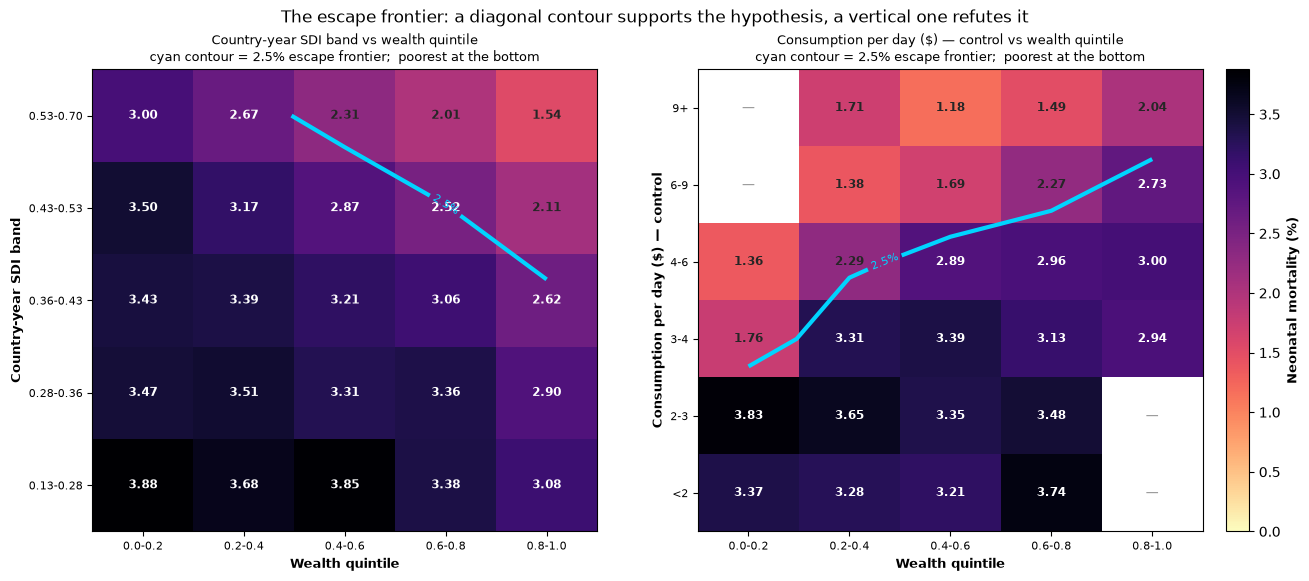

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/escape_percentile_vs_sdi.pdf


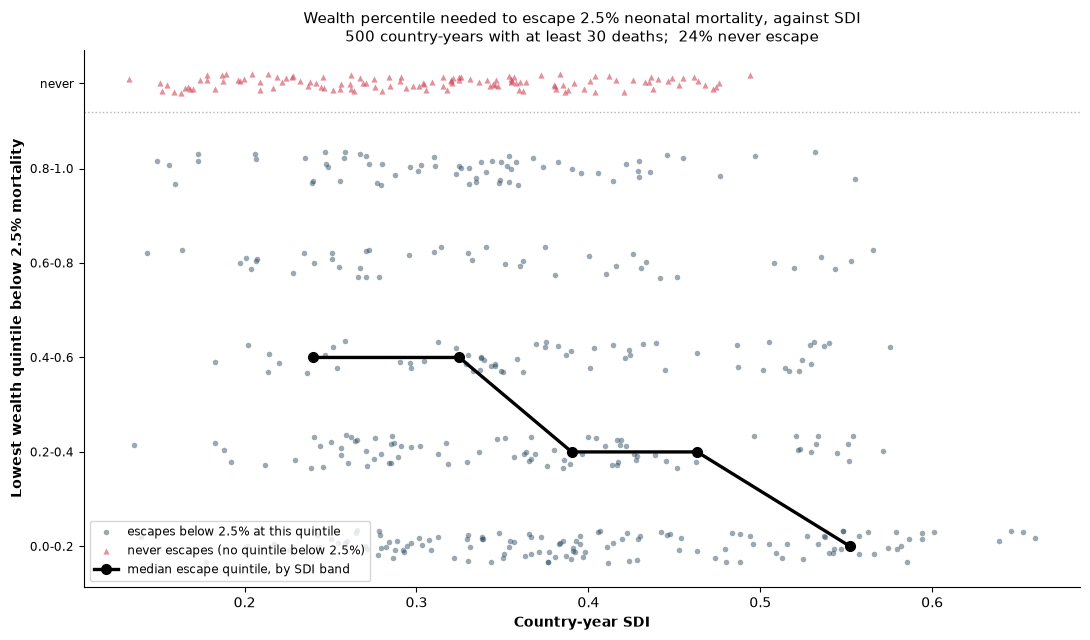


by SDI band (low SDI first):
           country_years  median_sdi  share_censored  median_escape
sdi_bin                                                            
0.13-0.28            139       0.240           0.353            0.4
0.28-0.36            134       0.325           0.269            0.4
0.36-0.43            108       0.390           0.194            0.2
0.43-0.53             73       0.463           0.219            0.2
0.53-0.70             46       0.552           0.000            0.0

Spearman rho (SDI vs escape quintile, censored excluded): -0.240
  the hypothesis predicts a NEGATIVE rho and more censoring at low SDI


In [13]:
# Does a poorer country need a higher wealth percentile to escape high mortality?
# Two views of one hypothesis, both resting on an ABSOLUTE threshold. A relative
# one - "below this country's own average" - would be tautological, since every
# country's top quintile beats its own mean by construction.
#
#   Figure 1: mortality over SDI band x wealth quintile, with a contour drawn
#             at the threshold. That contour is the escape frontier. The
#             hypothesis is the claim that it runs DIAGONALLY - a high wealth
#             percentile needed at low SDI, a low one at high SDI. A vertical
#             frontier would mean the escape point does not depend on SDI.
#             The second panel repeats it with consumption band in place of SDI,
#             as a control: SDI and consumption are tightly coupled, so if the
#             two frontiers look the same, SDI is adding nothing of its own.
#
#   Figure 2: the escape percentile itself, one point per country-year, against
#             SDI. Country-years where NO quintile gets below the threshold are
#             censored - they are the strongest form of the hypothesis, not
#             missing data, so they are pinned above the axis in red rather than
#             dropped.
#
# sdi is constant within a country-year here, so country-years are the unit
# throughout and SDI never varies along the wealth axis.
ES_THRESHOLD = 2.5  # "high mortality" (%), the level to escape
ES_YEARS = (1995, 2019)
ES_MIN_DEATHS = 10  # per heatmap cell
ES_MIN_DEATHS_CY = 30  # per country-year, for the escape curve
ES_N_SDI_BINS = 5
ES_CONS_EDGES = [0, 2, 3, 4, 6, 9, np.inf]
ES_CONS_LABELS = ["<2", "2-3", "3-4", "4-6", "6-9", "9+"]

es = df_agg_cyp[df_agg_cyp["birth_year"].between(*ES_YEARS)].copy()
es["wealth_bin"] = es["bin_left"].map(
    {b: f"{b:.1f}-{b + 0.2:.1f}" for b in sorted(es["bin_left"].unique())}
)
ES_WEALTH_LABELS = [f"{b:.1f}-{b + 0.2:.1f}" for b in sorted(es["bin_left"].unique())]

# SDI bands, cut on country-years so a big survey does not drag the edges
_es_cy = es.groupby(["ihme_loc_id", "birth_year"], as_index=False).agg(
    sdi=("sdi", "first"), births=("n_births", "sum"), deaths=("deaths", "sum")
)
_sdi_edges = np.unique(
    np.nanquantile(_es_cy["sdi"], np.linspace(0, 1, ES_N_SDI_BINS + 1))
)
ES_SDI_LABELS = [
    f"{_sdi_edges[i]:.2f}-{_sdi_edges[i + 1]:.2f}" for i in range(len(_sdi_edges) - 1)
]
_es_cy["sdi_bin"] = pd.cut(
    _es_cy["sdi"], bins=_sdi_edges, labels=ES_SDI_LABELS, include_lowest=True
)
es = es.merge(
    _es_cy[["ihme_loc_id", "birth_year", "sdi_bin"]],
    on=["ihme_loc_id", "birth_year"],
    how="left",
)
es["cons_bin"] = pd.cut(
    es["consumption_pd"], bins=ES_CONS_EDGES, labels=ES_CONS_LABELS, right=False
)
print(
    f"{len(es):,} country-year-quintile cells, "
    f"{len(_es_cy):,} country-years, SDI {_es_cy['sdi'].min():.2f}-"
    f"{_es_cy['sdi'].max():.2f}, threshold {ES_THRESHOLD}%"
)


def _es_grid(row_col, row_labels):
    g = es.groupby([row_col, "wealth_bin"], observed=False)[
        ["deaths", "n_births"]
    ].sum()
    rate = (100 * g["deaths"] / g["n_births"]).where(g["deaths"] >= ES_MIN_DEATHS)
    return rate.unstack("wealth_bin").reindex(
        index=row_labels, columns=ES_WEALTH_LABELS
    )


# Figure 1: the escape frontier #############################################
_es_panels = [
    ("sdi_bin", ES_SDI_LABELS, "Country-year SDI band"),
    ("cons_bin", ES_CONS_LABELS, "Consumption per day ($) — control"),
]
_es_grids = [_es_grid(c, labels) for c, labels, _ in _es_panels]
_es_vmax = max(float(np.nanmax(g.to_numpy())) for g in _es_grids)

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))
for ax, grid, (_, row_labels, y_label) in zip(axes, _es_grids, _es_panels):
    z = grid.to_numpy()
    im = ax.imshow(
        z, cmap="magma_r", vmin=0, vmax=_es_vmax, aspect="auto", origin="lower"
    )
    # The escape frontier: where the surface crosses the threshold
    if np.isfinite(z).sum() >= 4:
        cs = ax.contour(
            np.arange(z.shape[1]),
            np.arange(z.shape[0]),
            z,
            levels=[ES_THRESHOLD],
            colors="#00d4ff",
            linewidths=3,
            zorder=5,
        )
        ax.clabel(cs, fmt=f"{ES_THRESHOLD}%%", fontsize=8, colors="#00d4ff")

    for i in range(z.shape[0]):
        for j in range(z.shape[1]):
            v = z[i, j]
            if not np.isfinite(v):
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="0.55")
                continue
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="white" if v > 0.6 * _es_vmax else "0.15",
                fontweight="bold",
            )
    ax.set_xticks(range(len(ES_WEALTH_LABELS)), ES_WEALTH_LABELS, fontsize=8)
    ax.set_yticks(range(len(row_labels)), row_labels, fontsize=8)
    ax.set_xlabel("Wealth quintile", fontweight="bold", fontsize=9.5)
    ax.set_ylabel(y_label, fontweight="bold", fontsize=9.5)
    ax.set_title(
        f"{y_label} vs wealth quintile\n"
        f"cyan contour = {ES_THRESHOLD}% escape frontier;  poorest at the bottom",
        fontsize=9.5,
    )

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02).set_label(
    "Neonatal mortality (%)", fontweight="bold", fontsize=9
)
fig.suptitle(
    "The escape frontier: a diagonal contour supports the hypothesis, a vertical "
    "one refutes it",
    fontsize=12,
)
plot_path = f"{PLOT_OUTPUT}escape_frontier.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Figure 2: the escape percentile per country-year ###########################
_esc_rows = []
for (loc, yr), block in es.groupby(["ihme_loc_id", "birth_year"]):
    if block["deaths"].sum() < ES_MIN_DEATHS_CY:
        continue
    block = block.sort_values("bin_left")
    rate = 100 * block["deaths"].to_numpy() / block["n_births"].to_numpy()
    below = block["bin_left"].to_numpy()[rate < ES_THRESHOLD]
    _esc_rows.append(
        {
            "ihme_loc_id": loc,
            "birth_year": yr,
            "sdi": block["sdi"].iloc[0],
            "escape": below.min() if len(below) else np.nan,  # NaN = never escapes
            "births": int(block["n_births"].sum()),
        }
    )
df_escape = pd.DataFrame(_esc_rows)
_censor_y = max(ES_WEALTH_LABELS.__len__() - 1, 1) * 0.2 + 0.18
df_escape["censored"] = df_escape["escape"].isna()

_rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(11, 6.5))
_free = df_escape[~df_escape["censored"]]
_cens = df_escape[df_escape["censored"]]
ax.scatter(
    _free["sdi"],
    _free["escape"] + _rng.uniform(-0.035, 0.035, len(_free)),
    s=16,
    alpha=0.45,
    color="#1f4257",
    linewidths=0,
    zorder=2,
    label=f"escapes below {ES_THRESHOLD}% at this quintile",
)
ax.scatter(
    _cens["sdi"],
    np.full(len(_cens), _censor_y) + _rng.uniform(-0.02, 0.02, len(_cens)),
    s=20,
    alpha=0.6,
    color="#d1495b",
    marker="^",
    linewidths=0,
    zorder=3,
    label=f"never escapes (no quintile below {ES_THRESHOLD}%)",
)
ax.axhline(_censor_y - 0.06, color="0.7", lw=1, ls=":", zorder=1)

# Median escape quintile and censoring rate, by SDI band
_summary = (
    df_escape.assign(
        sdi_bin=pd.cut(
            df_escape["sdi"],
            bins=_sdi_edges,
            labels=ES_SDI_LABELS,
            include_lowest=True,
        )
    )
    .groupby("sdi_bin", observed=False)
    .agg(
        country_years=("escape", "size"),
        median_sdi=("sdi", "median"),
        share_censored=("censored", "mean"),
        median_escape=("escape", "median"),
    )
)
ax.plot(
    _summary["median_sdi"],
    _summary["median_escape"],
    color="black",
    lw=2.4,
    marker="o",
    ms=7,
    zorder=4,
    label="median escape quintile, by SDI band",
)

ax.set_yticks(
    [b * 0.2 for b in range(len(ES_WEALTH_LABELS))] + [_censor_y],
    ES_WEALTH_LABELS + ["never"],
    fontsize=8.5,
)
ax.set_xlabel("Country-year SDI", fontweight="bold")
ax.set_ylabel(
    f"Lowest wealth quintile below {ES_THRESHOLD}% mortality", fontweight="bold"
)
ax.set_title(
    f"Wealth percentile needed to escape {ES_THRESHOLD}% neonatal mortality, "
    f"against SDI\n{len(df_escape):,} country-years with at least "
    f"{ES_MIN_DEATHS_CY} deaths;  {100 * df_escape['censored'].mean():.0f}% never escape",
    fontsize=11,
)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="lower left", fontsize=8.5)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}escape_percentile_vs_sdi.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print("\nby SDI band (low SDI first):")
print(_summary.round(3).to_string())
_corr = df_escape[["sdi", "escape"]].corr(method="spearman").iloc[0, 1]
print(
    f"\nSpearman rho (SDI vs escape quintile, censored excluded): {_corr:+.3f}"
    f"\n  the hypothesis predicts a NEGATIVE rho and more censoring at low SDI"
)

Binomial GLM: logit neonatal mortality on SDI and wealth-quintile rank (poorest as base)

In [16]:
# Binomial GLM: logit mortality on SDI and wealth-quintile rank ###############
# Same family and link as the earlier model - binomial, logit, one row per
# country-year-quintile cell of df_agg_cyp, with the births carried as the
# binomial denominator rather than as a weight (the two-column endog is the
# exact form of what "weighted by group size" meant there).
#
# Two explanatory variables:
#   sdi          - the country-year Socio-demographic Index, a linear term
#   wealth_rank  - the quintile as an ORDINAL factor, 1 = poorest, treated as
#                  categorical with 1 as the base. Each coefficient is that
#                  quintile against the poorest, holding SDI fixed, so the four
#                  contrasts are free to be non-monotone if the data says so.
#
# A linear-in-rank version is fitted afterwards for comparison: it spends one
# parameter instead of four, and the AIC gap says whether the extra three are
# earning their place.
#
# NOTE on standard errors: this is a plain GLM, not the mixed model - there is
# no country random intercept here. Cells from the same country are not
# independent, so the default SEs would be too small. They are therefore
# clustered by country, which is what the summary below reports.
import statsmodels.api as sm
import statsmodels.formula.api as smf

g2 = df_agg_cyp.dropna(subset=["sdi", "n_births", "deaths"]).copy()
g2 = g2[g2["n_births"] > 0]
g2["wealth_rank"] = (
    g2["bin_left"].rank(method="dense").astype(int)
)  # 1 = poorest quintile
g2["survivors"] = g2["n_births"] - g2["deaths"]

print(
    f"{len(g2):,} country-year-quintile cells, "
    f"{g2['ihme_loc_id'].nunique()} countries, "
    f"{int(g2['n_births'].sum()):,} births, {int(g2['deaths'].sum()):,} deaths\n"
    f"wealth_rank 1={g2.loc[g2['wealth_rank'] == 1, 'bin_left'].iloc[0]:.1f}-"
    f"{g2.loc[g2['wealth_rank'] == 1, 'bin_right'].iloc[0]:.1f} (base) ... "
    f"5={g2.loc[g2['wealth_rank'] == 5, 'bin_left'].iloc[0]:.1f}-"
    f"{g2.loc[g2['wealth_rank'] == 5, 'bin_right'].iloc[0]:.1f}\n"
    f"sdi ranges {g2['sdi'].min():.3f} to {g2['sdi'].max():.3f}\n"
)

# deaths first: patsy reads the first column of a two-column response as the
# successes, so "deaths + survivors" models P(death), which is what we want
g2_model = smf.glm(
    "deaths + survivors ~ sdi + C(wealth_rank, Treatment(reference=1))",
    data=g2,
    family=sm.families.Binomial(),
)
g2_fit = g2_model.fit(cov_type="cluster", cov_kwds={"groups": g2["ihme_loc_id"]})
print(g2_fit.summary())

# Coefficients as odds ratios, which is how a logit reads ######################
_or = pd.DataFrame(
    {
        "coef": g2_fit.params,
        "odds_ratio": np.exp(g2_fit.params),
        "ci_low": np.exp(g2_fit.conf_int()[0]),
        "ci_high": np.exp(g2_fit.conf_int()[1]),
        "p": g2_fit.pvalues,
    }
)
_or.index = [
    i.replace("C(wealth_rank, Treatment(reference=1))", "wealth_rank")
    for i in _or.index
]
print("\nodds ratios (wealth quintiles are vs the poorest, SDI held fixed):")
print(_or.round(4).to_string())
print(
    f"\nSDI: a 0.1 rise multiplies the odds of neonatal death by "
    f"{np.exp(0.1 * g2_fit.params['sdi']):.3f} "
    f"({100 * (np.exp(0.1 * g2_fit.params['sdi']) - 1):+.1f}%)"
)

# Is the wealth effect linear in rank? ########################################
# AIC is compared on the unclustered fits, since clustering changes the standard
# errors but not the likelihood.
g2_linear_model = smf.glm(
    "deaths + survivors ~ sdi + wealth_rank", data=g2, family=sm.families.Binomial()
)
g2_linear = g2_linear_model.fit(
    cov_type="cluster", cov_kwds={"groups": g2["ihme_loc_id"]}
)
print(
    f"\nlinear-in-rank comparison\n"
    f"  factor, 4 contrasts : AIC {g2_model.fit().aic:,.1f}\n"
    f"  linear, 1 slope     : AIC {g2_linear_model.fit().aic:,.1f}\n"
    f"  linear slope {g2_linear.params['wealth_rank']:+.4f} per quintile step "
    f"(odds x{np.exp(g2_linear.params['wealth_rank']):.4f}), "
    f"p = {g2_linear.pvalues['wealth_rank']:.3g}"
)

4,562 country-year-quintile cells, 60 countries, 1,711,538 births, 51,629 deaths
wealth_rank 1=0.0-0.2 (base) ... 5=0.8-1.0
sdi ranges 0.128 to 0.696

                    Generalized Linear Model Regression Results                    
Dep. Variable:     ['deaths', 'survivors']   No. Observations:                 4562
Model:                                 GLM   Df Residuals:                     4556
Model Family:                     Binomial   Df Model:                            5
Link Function:                       Logit   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -12650.
Date:                     Mon, 21 Sep 2026   Deviance:                       9680.6
Time:                             10:26:47   Pearson chi2:                 9.45e+03
No. Iterations:                          7   Pseudo R-squ. (CS):             0.3835
Covariance Type:                   cluster                                         
         

The same model with a country random intercept: binomial GLMM on SDI and wealth-quintile rank

In [17]:
# The same model with a country random intercept ##############################
# Binomial GLMM, logit link, on the country-year-quintile cells:
#
#   cbind(deaths, survivors) ~ sdi + factor(wealth_rank) + (1 | ihme_loc_id)
#
# Same two explanatory variables as the GLM above - SDI linear, wealth quintile
# as a factor with the poorest as base - but the country intercept is now a
# random effect rather than a cluster-robust correction to the standard errors.
# cbind() carries the births as the binomial denominator, so no weights
# argument is needed.
#
# What changes: the GLM's cluster-robust SEs fixed the standard errors but left
# the coefficients pooled across countries. A random intercept also changes the
# COEFFICIENTS, because SDI is a country-level covariate and the random
# intercept competes with it for the between-country variation. Expect the SDI
# term to shrink; whether it survives at all is the question this cell answers.
#
# Caching: rpy2 here segfaults the kernel at random (see the earlier GLMM cell),
# so a successful fit is written to MM2_CACHE and reloaded afterwards. Set
# MM2_REFIT = True to force it back through R.
import json
import os

MM2_CACHE = Path("mm2_glmm_sdi_wealth.json")
MM2_REFIT = False

mm2_df = df_agg_cyp.dropna(subset=["sdi", "n_births", "deaths"]).copy()
mm2_df = mm2_df[mm2_df["n_births"] > 0]
mm2_df["wealth_rank"] = mm2_df["bin_left"].rank(method="dense").astype(int)
mm2_df["survivors"] = mm2_df["n_births"] - mm2_df["deaths"]

mm2_signature = {
    "n_rows": int(len(mm2_df)),
    "n_groups": int(mm2_df["ihme_loc_id"].nunique()),
    "births": int(mm2_df["n_births"].sum()),
    "deaths": int(mm2_df["deaths"].sum()),
    "sdi_sum": round(float(mm2_df["sdi"].sum()), 6),
}
print(
    f"{len(mm2_df):,} country-year-quintile cells, "
    f"{mm2_df['ihme_loc_id'].nunique()} countries, "
    f"{int(mm2_df['n_births'].sum()):,} births, "
    f"{int(mm2_df['deaths'].sum()):,} deaths"
)

_mm2_cached = None
if MM2_CACHE.exists() and not MM2_REFIT:
    _c = json.loads(MM2_CACHE.read_text())
    if _c.get("signature") == mm2_signature:
        _mm2_cached = _c
    else:
        print(f"cache at {MM2_CACHE} was fitted on different data - refitting in R")

if _mm2_cached is not None:
    mm2_fixef = _mm2_cached["fixef"]
    mm2_se = _mm2_cached["se"]
    mm2_ranef_sd = _mm2_cached["ranef_sd"]
    mm2_summary = _mm2_cached["summary"]
    print(
        f"loaded the fit from {MM2_CACHE} (fitted {_mm2_cached['fitted_at']}); R not used\n"
    )
    print(mm2_summary)
else:
    os.environ.setdefault("R_HOME", "/ihme/homes/elyeb/miniconda3/envs/cgf/lib/R")
    if "libstdc++" not in os.environ.get("LD_PRELOAD", ""):
        raise RuntimeError(
            'No cached fit, so this needs the "gbd_env (with R)" kernel. Select '
            "it, restart the kernel and run the notebook from the top."
        )

    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter

    ro.r("suppressMessages(library(lme4))")
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv["mm2_r_df"] = ro.conversion.py2rpy(
            mm2_df[["ihme_loc_id", "deaths", "survivors", "sdi", "wealth_rank"]]
        )
    ro.r("mm2_r_df$wealth_rank <- factor(mm2_r_df$wealth_rank)")
    ro.globalenv["mm2_fit_r"] = ro.r(
        "glmer(cbind(deaths, survivors) ~ sdi + wealth_rank + (1 | ihme_loc_id), "
        'data = mm2_r_df, family = binomial(link = "logit"))'
    )
    mm2_summary = ro.r("paste(capture.output(summary(mm2_fit_r)), collapse = '\\n')")[0]
    print(mm2_summary)

    _fx = ro.r("fixef(mm2_fit_r)")
    mm2_fixef = dict(zip(list(_fx.names), [float(v) for v in _fx]))
    _se = ro.r("sqrt(diag(as.matrix(vcov(mm2_fit_r))))")
    mm2_se = dict(zip(list(_se.names), [float(v) for v in _se]))
    mm2_ranef_sd = float(ro.r('attr(VarCorr(mm2_fit_r)$ihme_loc_id, "stddev")')[0])

    MM2_CACHE.write_text(
        json.dumps(
            {
                "signature": mm2_signature,
                "fitted_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
                "formula": "cbind(deaths, survivors) ~ sdi + wealth_rank + (1 | ihme_loc_id)",
                "fixef": mm2_fixef,
                "se": mm2_se,
                "ranef_sd": mm2_ranef_sd,
                "summary": mm2_summary,
            },
            indent=1,
        )
    )
    print(f"\nfit cached to {MM2_CACHE.resolve()} - later runs skip R entirely")

# Odds ratios, and what the random intercept did to the GLM's coefficients ####
mm2_table = pd.DataFrame(
    {
        "coef": pd.Series(mm2_fixef),
        "se": pd.Series(mm2_se),
    }
)
mm2_table["z"] = mm2_table["coef"] / mm2_table["se"]
mm2_table["odds_ratio"] = np.exp(mm2_table["coef"])
mm2_table["ci_low"] = np.exp(mm2_table["coef"] - 1.96 * mm2_table["se"])
mm2_table["ci_high"] = np.exp(mm2_table["coef"] + 1.96 * mm2_table["se"])
print("\nodds ratios (wealth quintiles vs the poorest, SDI held fixed):")
print(mm2_table.round(4).to_string())
print(
    f"\nrandom intercept sd: {mm2_ranef_sd:.4f} on the log-odds scale, "
    f"{mm2_df['ihme_loc_id'].nunique()} countries"
)

# Side by side with the cluster-robust GLM from the previous cell ##############
_glm_map = {
    "Intercept": "(Intercept)",
    "sdi": "sdi",
    "C(wealth_rank, Treatment(reference=1))[T.2]": "wealth_rank2",
    "C(wealth_rank, Treatment(reference=1))[T.3]": "wealth_rank3",
    "C(wealth_rank, Treatment(reference=1))[T.4]": "wealth_rank4",
    "C(wealth_rank, Treatment(reference=1))[T.5]": "wealth_rank5",
}
_cmp = pd.DataFrame(
    {
        "glm_no_re": {
            v: g2_fit.params[k] for k, v in _glm_map.items() if k in g2_fit.params
        },
        "glmm_country_re": {k: v for k, v in mm2_fixef.items()},
    }
).dropna()
_cmp["difference"] = _cmp["glmm_country_re"] - _cmp["glm_no_re"]
print("\nfixed effects, GLM (cluster-robust) vs GLMM (country random intercept):")
print(_cmp.round(4).to_string())

4,562 country-year-quintile cells, 60 countries, 1,711,538 births, 51,629 deaths
loaded the fit from mm2_glmm_sdi_wealth.json (fitted 2026-09-18 16:55); R not used

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(deaths, survivors) ~ sdi + wealth_rank + (1 | ihme_loc_id)
   Data: mm2_r_df

      AIC       BIC    logLik -2*log(L)  df.resid 
  22657.2   22702.2  -11321.6   22643.2      4555 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7118 -0.7812 -0.1687  0.7335  9.2421 

Random effects:
 Groups      Name        Variance Std.Dev.
 ihme_loc_id (Intercept) 0.08806  0.2968  
Number of obs: 4562, groups:  ihme_loc_id, 60

Fixed effects:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -2.33153    0.06022 -38.719  < 2e-16 ***
sdi          -2.83845    0.11016 -25.767  < 2e-16 ***
wealth_rank2 -0.05420    0.01269  -4.271 1.94e-05 ***
wealth_rank3 -0.11672    0.01315  

Births-weighted GLMM predictions over the three focus countries, against GBD and the 09_14 run

recovered wealth + SDI country intercepts: sd 0.2904 against the fitted 0.2968
5 of 55 country-years have fewer than 200 births; their observed rate is not drawn (one Namibian year of 4 births reads as 25%), but the model lines keep them
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/glmm_wealth_predictions_three_countries.pdf


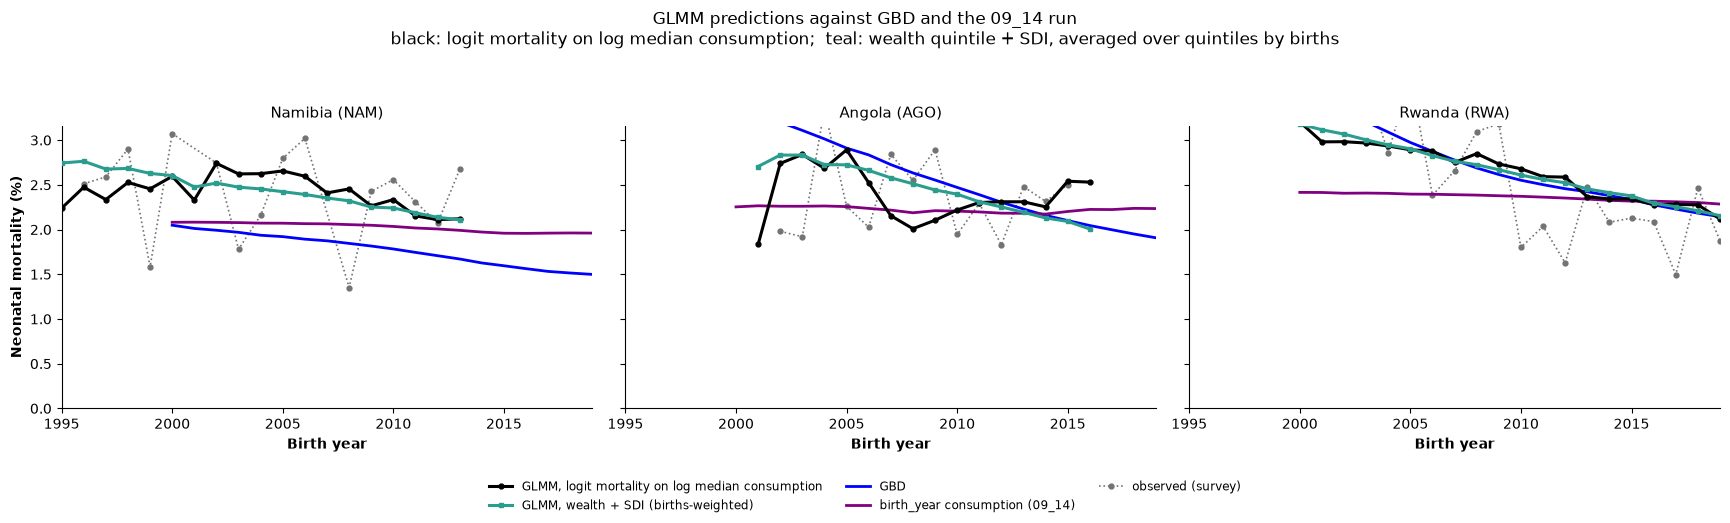


model predictions at the first and last survey year of each country:
               years  first_year  last_year  sdi_first  sdi_last  cons_first  cons_last  sdi_pred_first  sdi_pred_last
location_name                                                                                                         
Namibia           19        1995       2013      0.466      0.57       2.238      2.121           2.744          2.110
Angola            16        2001       2016      0.322      0.45       1.833      2.530           2.705          2.006
Rwanda            20        2000       2019      0.288      0.43       3.204      2.118           3.180          2.155

GBD and 09_14 over the same window:
               prevalence_gbd_first  prevalence_0914_first  prevalence_gbd_last  prevalence_0914_last
location_name                                                                                        
Namibia                       2.049                  2.081                1.498               

In [29]:
# The models' predictions over time, against GBD and the 09_14 run ###########
# Two fitted models are drawn, each collapsed to ONE line per country by
# averaging its quintile predictions with that country-year's own births:
#
#     pred(country, year) = sum_q n_births(c,y,q) * expit(eta_q) / sum_q n_births
#
# so the line is what the model expects for a birth drawn at random from that
# country in that year, not an unweighted average over quintiles.
#
#   "log consumption" - the earlier binomial GLMM, logit mortality on log
#                       median consumption with a country random intercept. It
#                       is fitted on country-YEAR cells, so it already gives
#                       one prediction per year and needs no quintile
#                       averaging; consumption moves it over time.
#   "wealth + SDI"    - the quintile model with sdi. SDI is a country-year
#                       covariate, so this line moves over time through SDI.
#                       Its quintile predictions are collapsed with the births
#                       weighting above.
#
# The wealth + SDI country intercepts were not cached with the fit, so rather
# than sending another glmer through the segfault roulette they are recovered
# as the conditional modes implied by the cached fixed effects and variance -
# the same inner solve lme4 performs. The log-consumption model cached its own
# random effects, so those are used directly.
P3_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
P3_YEARS = (1995, 2019)
P3_OBS_MIN_BIRTHS = 200  # a country-year needs this many before its rate is drawn
P3_CONS_COLOR = "black"
P3_SDI_COLOR = "#2a9d8f"
P3_GBD_COLOR = "blue"
P3_0914_COLOR = "purple"
P3_OBS_COLOR = "0.45"


def _conditional_modes(frame, fixed_lp, sigma2, group_col, tol=1e-11, max_iter=200):
    """Newton solve for the random intercepts, given the fixed effects."""
    codes, levels = pd.factorize(frame[group_col], sort=True)
    n = frame["n_births"].to_numpy(float)
    y = frame["deaths"].to_numpy(float)
    u = np.zeros(len(levels))
    for _ in range(max_iter):
        p = 1 / (1 + np.exp(-(fixed_lp + u[codes])))
        grad = np.bincount(codes, weights=y - n * p, minlength=len(levels)) - u / sigma2
        hess = (
            np.bincount(codes, weights=n * p * (1 - p), minlength=len(levels))
            + 1 / sigma2
        )
        step = grad / hess
        u = u + step
        if np.max(np.abs(step)) < tol:
            break
    return dict(zip(levels, u))


p3_df = df_agg_cyp.dropna(subset=["sdi", "n_births", "deaths"]).copy()
p3_df = p3_df[p3_df["n_births"] > 0]
p3_df["wealth_rank"] = p3_df["bin_left"].rank(method="dense").astype(int)

# Fixed-effect linear predictor for the wealth + SDI model, then its intercepts
_lp_sdi = (
    mm2_fixef["(Intercept)"]
    + mm2_fixef["sdi"] * p3_df["sdi"].to_numpy()
    + p3_df["wealth_rank"]
    .map(lambda r: 0.0 if r == 1 else mm2_fixef[f"wealth_rank{r}"])
    .to_numpy()
)
_ranef_sdi = _conditional_modes(p3_df, _lp_sdi, mm2_ranef_sd**2, "ihme_loc_id")
print(
    f"recovered wealth + SDI country intercepts: sd "
    f"{np.std(list(_ranef_sdi.values()), ddof=1):.4f} against the fitted "
    f"{mm2_ranef_sd:.4f}"
)

p3_df["pred_sdi"] = 1 / (
    1 + np.exp(-(_lp_sdi + p3_df["ihme_loc_id"].map(_ranef_sdi).to_numpy()))
)

# Births-weighted average over the quintiles, per country-year ################
p3_pred = (
    p3_df.assign(_ps=p3_df["pred_sdi"] * p3_df["n_births"])
    .groupby(["location_name", "birth_year"], as_index=False)
    .agg(
        _ps=("_ps", "sum"),
        n_births=("n_births", "sum"),
        deaths=("deaths", "sum"),
        sdi=("sdi", "first"),
    )
)
p3_pred["pred_sdi_pct"] = 100 * p3_pred["_ps"] / p3_pred["n_births"]

# The log-consumption GLMM is already one row per country-year, so its
# prediction comes straight from mm_predict on df_agg_cy
_p3_cons = df_agg_cy.dropna(subset=[MM_X]).copy()
_p3_cons["pred_cons_pct"] = 100 * mm_predict(_p3_cons)
p3_pred = p3_pred.merge(
    _p3_cons[["ihme_loc_id", "location_name", "birth_year", "pred_cons_pct"]],
    on=["location_name", "birth_year"],
    how="left",
)
p3_pred["observed_pct"] = 100 * p3_pred["deaths"] / p3_pred["n_births"]
p3_pred = p3_pred[
    p3_pred["location_name"].isin(P3_COUNTRIES)
    & p3_pred["birth_year"].between(*P3_YEARS)
].sort_values("birth_year")


# GBD and the 09_14 inference run, sex-averaged ################################
def _p3_mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


_p3_key = ["location_id", "year_id", "sex_id"]
_p3_series = {
    "prevalence_gbd": (GBD_FILE, False, P3_GBD_COLOR, "GBD"),
    "prevalence_0914": (
        INFERENCE_FILE_09_14,
        True,
        P3_0914_COLOR,
        "birth_year consumption (09_14)",
    ),
}
p3_lines = None
for col, (path, is_draws, _c, _l) in _p3_series.items():
    f = pd.read_parquet(path).reset_index()
    f = (
        _p3_mean_draw(f).rename(columns={"prevalence": col})
        if is_draws
        else f.rename(columns={"gbd_mean_prevalence": col})
    )
    f = f[_p3_key + [col]]
    p3_lines = f if p3_lines is None else p3_lines.merge(f, on=_p3_key, how="inner")
p3_lines = (
    p3_lines.merge(
        locs[["location_id", "location_name"]].drop_duplicates("location_id"),
        on="location_id",
        how="inner",
    )
    .query("location_name in @P3_COUNTRIES")
    .query("year_id >= @P3_YEARS[0] and year_id <= @P3_YEARS[1]")
    .groupby(["location_name", "year_id"], as_index=False)[list(_p3_series)]
    .mean()
    .sort_values("year_id")
)

_iso_by_name = locs.drop_duplicates("location_name").set_index("location_name")[
    "ihme_loc_id"
]
_p3_thin = int((p3_pred["n_births"] < P3_OBS_MIN_BIRTHS).sum())
if _p3_thin:
    print(
        f"{_p3_thin} of {len(p3_pred)} country-years have fewer than "
        f"{P3_OBS_MIN_BIRTHS} births; their observed rate is not drawn (one "
        f"Namibian year of 4 births reads as 25%), but the model lines keep them"
    )

fig, axes = plt.subplots(
    ncols=len(P3_COUNTRIES), figsize=(5.8 * len(P3_COUNTRIES), 5.2), sharey=True
)
axes = np.atleast_1d(axes)
handles, labels = [], []

for ax, country in zip(axes, P3_COUNTRIES):
    block = p3_pred[p3_pred["location_name"] == country]
    ax.plot(
        block["birth_year"],
        block["pred_cons_pct"],
        color=P3_CONS_COLOR,
        lw=2.2,
        marker="o",
        ms=3.5,
        zorder=5,
        label="GLMM, logit mortality on log median consumption",
    )
    ax.plot(
        block["birth_year"],
        block["pred_sdi_pct"],
        color=P3_SDI_COLOR,
        lw=2.2,
        marker="s",
        ms=3.5,
        zorder=5,
        label="GLMM, wealth + SDI (births-weighted)",
    )
    p = p3_lines[p3_lines["location_name"] == country]
    for col, (_path, _d, colour, label) in _p3_series.items():
        ax.plot(p["year_id"], 100 * p[col], color=colour, lw=2.0, zorder=4, label=label)
    o = block[block["n_births"] >= P3_OBS_MIN_BIRTHS]
    ax.plot(
        o["birth_year"],
        o["observed_pct"],
        color=P3_OBS_COLOR,
        lw=1.2,
        ls=":",
        marker="o",
        ms=3.5,
        zorder=2,
        label="observed (survey)",
    )

    ax.set_xlim(*P3_YEARS)
    ax.set_ylim(0, None)
    ax.set_xlabel("Birth year", fontweight="bold")
    ax.set_title(f"{country} ({_iso_by_name.loc[country]})", fontsize=11)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if not handles:
        handles, labels = ax.get_legend_handles_labels()
axes[0].set_ylabel("Neonatal mortality (%)", fontweight="bold")

fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8.5, frameon=False)
fig.suptitle(
    "GLMM predictions against GBD and the 09_14 run\n"
    "black: logit mortality on log median consumption;  teal: wealth quintile "
    "+ SDI, averaged over quintiles by births",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0.10, 1, 0.93))

plot_path = f"{PLOT_OUTPUT}glmm_wealth_predictions_three_countries.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# How much each series actually moves over the window #########################
_span = (
    p3_pred.sort_values("birth_year")
    .groupby("location_name")
    .agg(
        years=("birth_year", "size"),
        first_year=("birth_year", "first"),
        last_year=("birth_year", "last"),
        sdi_first=("sdi", "first"),
        sdi_last=("sdi", "last"),
        cons_first=("pred_cons_pct", "first"),
        cons_last=("pred_cons_pct", "last"),
        sdi_pred_first=("pred_sdi_pct", "first"),
        sdi_pred_last=("pred_sdi_pct", "last"),
    )
    .loc[P3_COUNTRIES]
)
print("\nmodel predictions at the first and last survey year of each country:")
print(_span.round(3).to_string())
print("\nGBD and 09_14 over the same window:")
print(
    pd.concat(
        [
            (100 * p3_lines.groupby("location_name")[list(_p3_series)].first())
            .round(3)
            .add_suffix("_first"),
            (100 * p3_lines.groupby("location_name")[list(_p3_series)].last())
            .round(3)
            .add_suffix("_last"),
        ],
        axis=1,
    )
    .loc[P3_COUNTRIES]
    .to_string()
)

Wealth-quintile coefficients of the GLMM with SDI and a country random intercept

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/glmm_wealth_rank_model_comparison.pdf


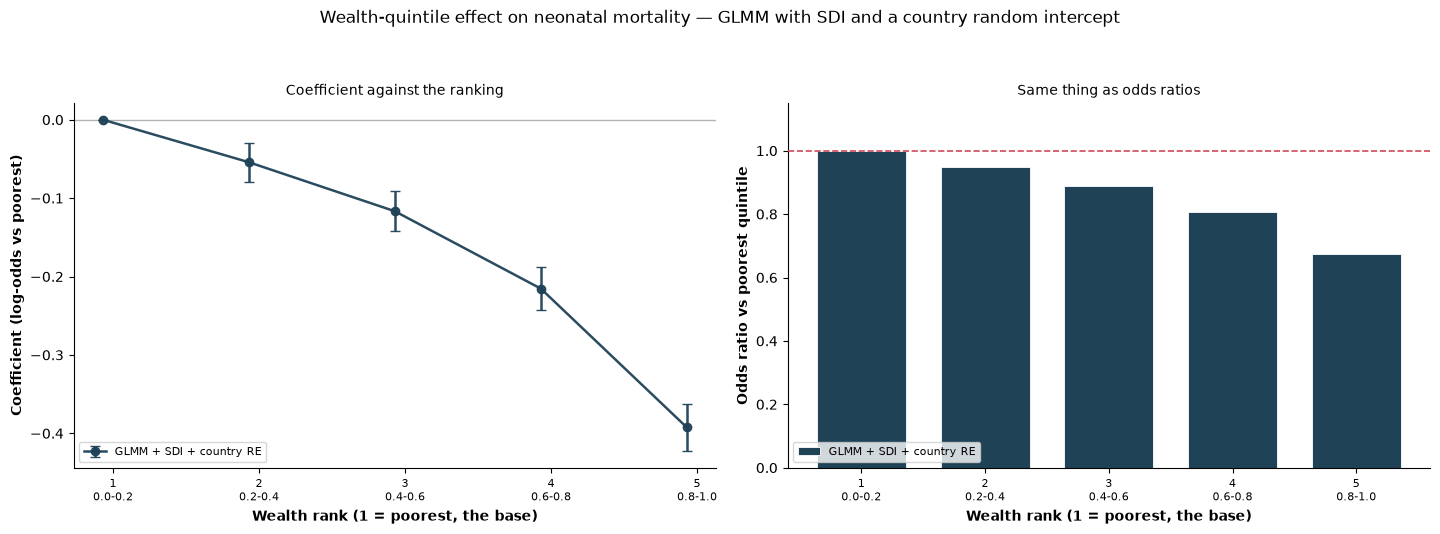


coefficients (log-odds vs the poorest quintile):
model        GLMM + SDI + country RE
wealth_rank                         
1                             0.0000
2                            -0.0542
3                            -0.1167
4                            -0.2154
5                            -0.3924

standard errors:
model        GLMM + SDI + country RE
wealth_rank                         
1                             0.0000
2                             0.0127
3                             0.0132
4                             0.0139
5                             0.0154

step from each rank to the next: -0.0542, -0.0625, -0.0987, -0.1770
  monotone decreasing: True; largest step -0.1770, smallest -0.0542


In [28]:
# Wealth-quintile coefficients against the ranking ##############################
# The wealth-quintile coefficients of the GLMM with SDI and a country random
# intercept, read straight out of the fit the previous cell left behind - this
# cell never touches R.
#
# Rank 1 is the base, so its coefficient is 0 with no uncertainty; every other
# point is a contrast against the poorest quintile. Error bars are model-based
# 95% intervals, which assume the wealth gradient is common to all countries.
CM_MODELS = [
    (
        "GLMM + SDI + country RE",
        {r: f"wealth_rank{r}" for r in range(2, 6)},
        pd.Series(mm2_fixef),
        pd.Series(mm2_se),
        "#1f4257",
        "o",
    ),
]
CM_RANKS = [1, 2, 3, 4, 5]
CM_PCTL = [f"{(r - 1) * 0.2:.1f}-{r * 0.2:.1f}" for r in CM_RANKS]

_cm_rows = []
for name, keymap, params, ses, colour, marker in CM_MODELS:
    for r in CM_RANKS:
        key = keymap.get(r)
        _cm_rows.append(
            {
                "model": name,
                "wealth_rank": r,
                "coef": 0.0 if key is None else float(params[key]),
                "se": 0.0 if key is None else float(ses[key]),
            }
        )
cm_coefs = pd.DataFrame(_cm_rows)
cm_coefs["odds_ratio"] = np.exp(cm_coefs["coef"])
cm_coefs["ci_low"] = np.exp(cm_coefs["coef"] - 1.96 * cm_coefs["se"])
cm_coefs["ci_high"] = np.exp(cm_coefs["coef"] + 1.96 * cm_coefs["se"])

fig, axes = plt.subplots(ncols=2, figsize=(14.5, 5.4))
_offsets = np.linspace(-0.07, 0.07, len(CM_MODELS))

ax = axes[0]
for (name, _, _, _, colour, marker), off in zip(CM_MODELS, _offsets):
    block = cm_coefs[cm_coefs["model"] == name]
    ax.errorbar(
        block["wealth_rank"] + off,
        block["coef"],
        yerr=1.96 * block["se"],
        fmt=f"{marker}-",
        color=colour,
        lw=1.8,
        ms=6,
        capsize=3.5,
        zorder=3,
        label=name,
        alpha=0.95,
    )
ax.axhline(0, color="0.7", lw=1, zorder=1)
ax.set_xticks(CM_RANKS, [f"{r}\n{p}" for r, p in zip(CM_RANKS, CM_PCTL)], fontsize=8)
ax.set_xlabel("Wealth rank (1 = poorest, the base)", fontweight="bold")
ax.set_ylabel("Coefficient (log-odds vs poorest)", fontweight="bold")
ax.set_title("Coefficient against the ranking", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
_width = 0.72 / len(CM_MODELS)
for i, (name, _, _, _, colour, _marker) in enumerate(CM_MODELS):
    block = cm_coefs[cm_coefs["model"] == name]
    _off = (i - (len(CM_MODELS) - 1) / 2) * _width
    ax.bar(
        block["wealth_rank"] + _off,
        block["odds_ratio"],
        width=_width,
        color=colour,
        edgecolor="white",
        linewidth=0.6,
        zorder=2,
        label=name,
    )
ax.axhline(1.0, color="#d1495b", lw=1.2, ls="--", zorder=3)
ax.set_xticks(CM_RANKS, [f"{r}\n{p}" for r, p in zip(CM_RANKS, CM_PCTL)], fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Wealth rank (1 = poorest, the base)", fontweight="bold")
ax.set_ylabel("Odds ratio vs poorest quintile", fontweight="bold")
ax.set_title("Same thing as odds ratios", fontsize=10)
ax.legend(fontsize=8, loc="lower left")

for ax in axes:
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.suptitle(
    "Wealth-quintile effect on neonatal mortality — GLMM with SDI and a "
    "country random intercept",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))

plot_path = f"{PLOT_OUTPUT}glmm_wealth_rank_model_comparison.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# The numbers behind it #######################################################
print("\ncoefficients (log-odds vs the poorest quintile):")
print(
    cm_coefs.pivot(index="wealth_rank", columns="model", values="coef")[
        [m[0] for m in CM_MODELS]
    ]
    .round(4)
    .to_string()
)
print("\nstandard errors:")
print(
    cm_coefs.pivot(index="wealth_rank", columns="model", values="se")[
        [m[0] for m in CM_MODELS]
    ]
    .round(4)
    .to_string()
)
_steps = cm_coefs.sort_values("wealth_rank")["coef"].diff().dropna()
print(
    "\nstep from each rank to the next: "
    + ", ".join(f"{v:+.4f}" for v in _steps)
    + f"\n  monotone decreasing: {bool((_steps < 0).all())}; "
    f"largest step {_steps.min():+.4f}, smallest {_steps.max():+.4f}"
)

Neonatal mortality by SDI and wealth quintile

4,562 country-year-quintile cells, 918 country-years, SDI 0.13-0.70 in 6 quantile bands
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/mortality_sdi_by_wealth_heatmap.pdf


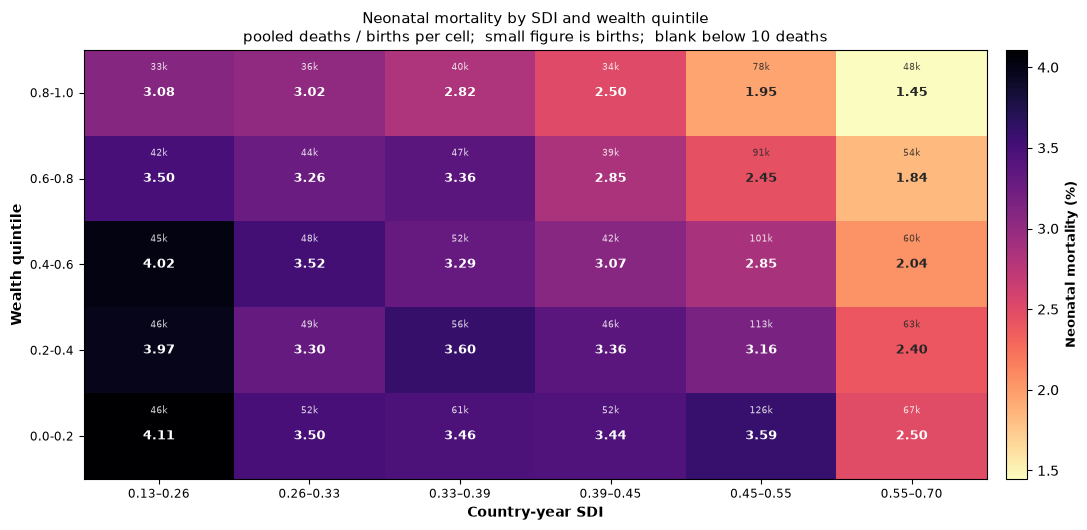


neonatal mortality (%), rows = wealth quintile, columns = SDI band:
sdi_bin     0.13–0.26  0.26–0.33  0.33–0.39  0.39–0.45  0.45–0.55  0.55–0.70
wealth_bin                                                                  
0.0-0.2          4.11       3.50       3.46       3.44       3.59       2.50
0.2-0.4          3.97       3.30       3.60       3.36       3.16       2.40
0.4-0.6          4.02       3.52       3.29       3.07       2.85       2.04
0.6-0.8          3.50       3.26       3.36       2.85       2.45       1.84
0.8-1.0          3.08       3.02       2.82       2.50       1.95       1.45

richest quintile / poorest quintile, within each SDI band:
sdi_bin
0.13–0.26    0.751
0.26–0.33    0.863
0.33–0.39    0.816
0.39–0.45    0.728
0.45–0.55    0.543
0.55–0.70    0.580


In [ ]:
# Neonatal mortality over SDI and wealth quintile #############################
# x: country-year SDI, in bands;  y: wealth quintile;  shading: mortality.
#
# Each cell is sum(deaths) / sum(births) over every country-year-quintile cell
# that lands in it, never a mean of cell rates - the underlying cells range
# from 1 birth to 12,675, so averaging their rates would weight them equally.
#
# The SDI bands are QUANTILE cut, so each holds a similar number of
# country-years rather than an equal slice of the SDI range. That keeps the
# cells comparably precise, but it means the x axis is rank-spaced, not linear
# in SDI - the band edges are printed on the ticks so the widths are visible.
# Set SH_EQUAL_WIDTH = True for equal-width bands instead.
#
# sdi is constant within a country-year, so it is cut on country-years; a large
# survey cannot drag the band edges around.
SH_N_SDI = 6
SH_EQUAL_WIDTH = False
SH_MIN_DEATHS = 10

sh = df_agg_cyp.dropna(subset=["sdi", "n_births", "deaths"]).copy()
sh = sh[sh["n_births"] > 0]
sh["wealth_bin"] = sh["bin_left"].map(
    {b: f"{b:.1f}-{b + 0.2:.1f}" for b in sorted(sh["bin_left"].unique())}
)
SH_WEALTH_LABELS = [f"{b:.1f}-{b + 0.2:.1f}" for b in sorted(sh["bin_left"].unique())]

_sh_cy = sh.groupby(["ihme_loc_id", "birth_year"], as_index=False)["sdi"].first()
if SH_EQUAL_WIDTH:
    _sh_edges = np.linspace(_sh_cy["sdi"].min(), _sh_cy["sdi"].max(), SH_N_SDI + 1)
else:
    _sh_edges = np.unique(
        np.nanquantile(_sh_cy["sdi"], np.linspace(0, 1, SH_N_SDI + 1))
    )
SH_SDI_LABELS = [
    f"{_sh_edges[i]:.2f}–{_sh_edges[i + 1]:.2f}" for i in range(len(_sh_edges) - 1)
]
sh["sdi_bin"] = pd.cut(
    sh["sdi"], bins=_sh_edges, labels=SH_SDI_LABELS, include_lowest=True
)

_g = sh.groupby(["wealth_bin", "sdi_bin"], observed=False)[["deaths", "n_births"]].sum()
sh_rate = (100 * _g["deaths"] / _g["n_births"]).where(_g["deaths"] >= SH_MIN_DEATHS)
sh_rate = sh_rate.unstack("sdi_bin").reindex(
    index=SH_WEALTH_LABELS, columns=SH_SDI_LABELS
)
sh_births = (
    _g["n_births"]
    .unstack("sdi_bin")
    .reindex(index=SH_WEALTH_LABELS, columns=SH_SDI_LABELS)
)

print(
    f"{len(sh):,} country-year-quintile cells, {len(_sh_cy):,} country-years, "
    f"SDI {_sh_cy['sdi'].min():.2f}-{_sh_cy['sdi'].max():.2f} in "
    f"{len(SH_SDI_LABELS)} {'equal-width' if SH_EQUAL_WIDTH else 'quantile'} bands"
)

fig, ax = plt.subplots(figsize=(11, 5.4))
z = sh_rate.to_numpy()
im = ax.imshow(z, cmap="magma_r", aspect="auto", origin="lower")

for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        v, n = z[i, j], sh_births.to_numpy()[i, j]
        if not np.isfinite(v):
            ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="0.55")
            continue
        colour = "white" if v > 0.6 * np.nanmax(z) else "0.15"
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=colour,
            fontweight="bold",
        )
        ax.text(
            j,
            i + 0.30,
            f"{n / 1000:,.0f}k",
            ha="center",
            va="center",
            fontsize=6.5,
            color=colour,
            alpha=0.85,
        )

ax.set_xticks(range(len(SH_SDI_LABELS)), SH_SDI_LABELS, fontsize=8.5)
ax.set_yticks(range(len(SH_WEALTH_LABELS)), SH_WEALTH_LABELS, fontsize=8.5)
ax.set_xlabel("Country-year SDI", fontweight="bold")
ax.set_ylabel("Wealth quintile", fontweight="bold")
ax.set_title(
    "Neonatal mortality by SDI and wealth quintile\n"
    f"pooled deaths / births per cell;  small figure is births;  "
    f"blank below {SH_MIN_DEATHS} deaths",
    fontsize=11,
)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02).set_label(
    "Neonatal mortality (%)", fontweight="bold", fontsize=9
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}mortality_sdi_by_wealth_heatmap.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print("\nneonatal mortality (%), rows = wealth quintile, columns = SDI band:")
print(sh_rate.round(2).to_string())
print("\nrichest quintile / poorest quintile, within each SDI band:")
_ratio = (sh_rate.loc[SH_WEALTH_LABELS[-1]] / sh_rate.loc[SH_WEALTH_LABELS[0]]).round(3)
print(_ratio.to_string())